In [689]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ANALYSE DESCRIPTIVE

In [756]:
df = pd.read_csv(r"C:\TSQ\data\Projet_final_DESU\data2.csv", sep=",", encoding='utf-8')

In [ ]:
df = df.drop(df.index[[84, 232, 338, 43,91,196,299 ]]) # Suppression de la ligne 84 car diag porte à confusion pas une patho et 232 car HPI ne fait pas parti de nos diag. 338 car a mit son age 192006. Les 4 autres ont déclaré aviur déjà rmepli le questionnaire

In [758]:
print(f"Shape : {df.shape}")
print(f"Nombre de colonnes détectées : {len(df.columns)}")

Shape : (361, 276)
Nombre de colonnes détectées : 276


In [759]:
df.head()

,ID de la réponse,Date de soumission,Dernière page,Langue de départ,Tête de série,Date de lancement,Date de la dernière action,Quota exit,Être bien âgé entre 18 et 65 ans,Avoir un niveau de maitrise suffisant de la langue française,...,Durée pour la question: G11Q62,Durée pour la question: G10Q63,Durée pour la question: G10Q64,Durée pour la question: G01Q65,Durée pour la question: G01Q66,Durée pour la question: G10Q68,Durée pour le groupe : ZTPI - Evaluation de la temporalité,Durée pour la question: G12Q68,"Durée pour le groupe : Bravo, vous êtes arrivé(e)s à la fin de ce questionnaire !",Durée pour la question: G08Q139
0,7,NaN,8.0,fr,1344793166,1980-01-01 00:00:00,1980-01-01 00:00:00,NaN,Oui,Oui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8,1980-01-01 00:00:00,12.0,fr,1664186297,1980-01-01 00:00:00,1980-01-01 00:00:00,NaN,Oui,Oui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9,1980-01-01 00:00:00,12.0,fr,627717770,1980-01-01 00:00:00,1980-01-01 00:00:00,NaN,Oui,Oui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10,1980-01-01 00:00:00,12.0,fr,1685970839,1980-01-01 00:00:00,1980-01-01 00:00:00,NaN,Oui,Oui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11,1980-01-01 00:00:00,12.0,fr,2127008022,1980-01-01 00:00:00,1980-01-01 00:00:00,NaN,Oui,Oui,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [760]:

df['Date de soumission'].isna().sum()

np.int64(160)

In [761]:
df = df.dropna(subset=['Date de soumission'])

In [ ]:
#deja commencer par enlever toutes les colonnes non nécessire

df.drop(columns=['Date de soumission','Date de lancement', 'Date de la dernière action', 'Quota exit'],inplace=True)


# On va trier ceux qui ont un diag de ceux qui n'en n'ont pas

In [763]:
#PS = participants sains #PD = participants diagnostiqués
col = "Avez-vous déjà reçu un diagnostic psychiatrique dans le passé ou actuellement ?"
df_PS = df[df[col] == "Non"].copy()
df_PD = df[df[col] == "Oui"].copy()


On va commencer par séparer les résultats des différents questionnaires en faisant un dataframe pour chaque échelle

In [764]:
n_patients = len(df_PD)
n_total = len(df)
pourcentage = n_patients / n_total * 100

print(f"df_PD : {n_patients} lignes sur {n_total} ({pourcentage:.2f}%)")

df_PD : 35 lignes sur 201 (17.41%)


# Visualisation des diagnostics

In [765]:
pd.set_option('display.max_colwidth', None)
 
col_name = df_PD.columns[18]
print(df_PD[col_name].to_string())

2                                                             TDAH\nDépression\nAnxiété chronique
4                                                                                 Trouble anxieux
11                                                                                     Depression
13                                                                                     Dépression
20                                                                       TROUBLE BIPOLAIRE TYPE 1
28                                                                  épisode dépressif caractérisé
41                                                                              épisode dépressif
79                                                                            Tendance depressive
98                                                                                     Dépression
113                                                                                    Dépression
139                 

16% des participants ont ou ont eu un diag

# Traitement

In [766]:
pd.set_option('display.max_colwidth', None)
 
col_name = df_PD.columns[21]
print(df_PD[col_name].to_string())

2                                                                                                                                  NaN
4                                                                                                                           Depression
11                                                                                    Dysthymie , dépressif et dépendance aux toxiques
13                                                                                                                          Bipolarité
20                                                                                                                                 NaN
28                                                                                                                                 NaN
41                                                                                                                                 NaN
79                                                     

# On fait des groupes

In [767]:
comor= df_PD.iloc[[0, 11, 14, 17, 20, 23, 27, 31, 34]]
comor.iloc[:, 18]

2                                                             TDAH\nDépression\nAnxiété chronique
140                                                                     Dépression, anxiété, TdAH
176                                                             TSA, TDAH, TDI, bipolarité type 1
195                                                                      Syndrome anxio dépressif
247                                                                                   TDAH et TAG
265                                                                          Dépression + Anxiété
290    Trouble anxieux généralisé, anxiété sociale, stress post traumatique et dépression modérée
342                                           dépression, troubles anxieux et troubles du sommeil
360                                                                          TAG\nTCA\nDépression
Name: Si oui, lequel (lesquels) ? , dtype: str

In [768]:
dep= df_PD.iloc[[2,3,5,6,7,8,9,16,18,19,28, 32]]
dep.iloc[:, 18]

11                        Depression
13                        Dépression
28     épisode dépressif caractérisé
41                 épisode dépressif
79               Tendance depressive
98                        Dépression
113                       Dépression
182                       Dépression
209                       Dépression
242         Episode depressif modéré
296         Depression reactionnelle
354                       Dépression
Name: Si oui, lequel (lesquels) ? , dtype: str

In [769]:
ax= df_PD.iloc[[1,12,13,15,24, 25, 33]]
ax.iloc[:, 18]

4                                                                           Trouble anxieux
149                                           Diagnostic d’un trouble anxieux et généralisé
153                                                              Trouble anxieux généralisé
178                                                                                     TAG
266                                                                     Anxiété généralisée
272    Trouble anxieux généralisé, trouble anxieux social et trouble anxieux de performance
358                                                                     anxiété généraliser
Name: Si oui, lequel (lesquels) ? , dtype: str

In [770]:
man = df_PD.iloc[[4,21,22,26,29,30]]
man.iloc[:, 18]

20     TROUBLE BIPOLAIRE TYPE 1
251                  Bipolarité
257                         TOC
287                  borderline
300                  Bipolarité
310                  Bipolarité
Name: Si oui, lequel (lesquels) ? , dtype: str

In [771]:
sz = df_PD.iloc[[10]]
sz.iloc[:, 18]

139    Schizophrénie
Name: Si oui, lequel (lesquels) ? , dtype: str

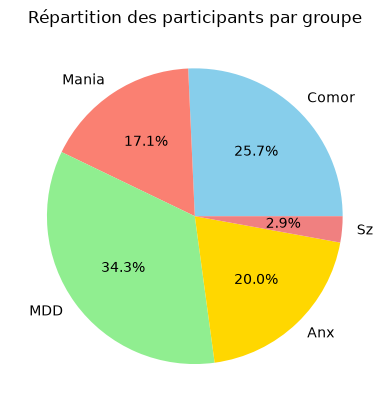

In [772]:
import matplotlib.pyplot as plt

# Dictionnaire avec le nom du groupe et sa taille
groupes = {
    'Comor': len(comor),
    'Mania': len(man),
    'MDD': len(dep),
    'Anx' :len(ax),
    'Sz': len(sz)
}
plt.pie(
    groupes.values(),
    labels=groupes.keys(),
    autopct='%1.1f%%',
    colors=['skyblue', 'salmon', 'lightgreen', 'gold', 'lightcoral']
)
plt.title("Répartition des participants par groupe")
plt.show()

# Données socio-demo

In [773]:
donnees_soc_demo = ['ID de la réponse', 'Dernière page', 'Langue de départ', 'Tête de série', 'Être bien âgé entre 18 et 65 ans', 'Avoir un niveau de maitrise suffisant de la langue française\xa0', 'Être dans un moment calme et de disponibilité pour compléter le questionnaire', 'Quel est votre âge ?', 'Comment vous identifiez-vous ?\xa0', 'Est-ce la première fois que vous remplissez ce questionnaire?', 'Êtes-vous étudiant (hors Université du Temps Libre) ?', 'Quelle est votre situation ?', "Quelle est votre filière d'étude ?", "Quelle est votre filière d'étude ? [Autre]", 'Quelle est votre profession ?\xa0', 'En quelle année êtes-vous ?', 'Quel est votre plus haut niveau de diplôme obtenu ?', 'Avez-vous déjà reçu un diagnostic psychiatrique dans le passé ou actuellement ?', 'Si oui, lequel (lesquels) ?\xa0', 'Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?', 'Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?', 'Précisez le traitement médicamenteux actuel et son dosage.', 'Avez-vous consommé des substances ce dernier mois (hors tabac, alcool et/ou traitements médicamenteux) ?', 'À quelle fréquence ?', 'Quelle(s) substance(s) avez-vous consommé ?']
df_SD=df[donnees_soc_demo].copy()

In [774]:
print(f"Shape : {df_SD.shape}")

Shape : (201, 25)


In [775]:
df.info()

<class 'pandas.DataFrame'>
Index: 201 entries, 1 to 367
Columns: 272 entries, ID de la réponse to Durée pour la question: G08Q139
dtypes: float64(172), int64(2), str(98)
memory usage: 428.7 KB


In [776]:
# Création de df_SD pour chaque groupe 
donnees_soc_demo = ['ID de la réponse', 'Dernière page', 'Langue de départ', 'Tête de série', 'Être bien âgé entre 18 et 65 ans', 'Avoir un niveau de maitrise suffisant de la langue française\xa0', 'Être dans un moment calme et de disponibilité pour compléter le questionnaire', 'Quel est votre âge ?', 'Comment vous identifiez-vous ?\xa0', 'Est-ce la première fois que vous remplissez ce questionnaire?', 'Êtes-vous étudiant (hors Université du Temps Libre) ?', 'Quelle est votre situation ?', "Quelle est votre filière d'étude ?", "Quelle est votre filière d'étude ? [Autre]", 'Quelle est votre profession ?\xa0', 'En quelle année êtes-vous ?', 'Quel est votre plus haut niveau de diplôme obtenu ?', 'Avez-vous déjà reçu un diagnostic psychiatrique dans le passé ou actuellement ?', 'Si oui, lequel (lesquels) ?\xa0', 'Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?', 'Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?', 'Précisez le traitement médicamenteux actuel et son dosage.', 'Avez-vous consommé des substances ce dernier mois (hors tabac, alcool et/ou traitements médicamenteux) ?', 'À quelle fréquence ?', 'Quelle(s) substance(s) avez-vous consommé ?']
df_SD_PD=df_PD[donnees_soc_demo].copy()
df_SD_PS=df_PS[donnees_soc_demo].copy()

On a des colonnes qui sont pertinentes quand meme pour le groupe sain mais tout le monde n'est pas concerné donc il y a des Nan. 
Je vais remplacer les "Nan" pas une valeur categorielle : "non concerné"

In [777]:
df_SD_PS.describe()


,ID de la réponse,Dernière page,Tête de série,Quel est votre âge ?
count,166.000000,166.0,1.660000e+02,166.000000
mean,175.295181,12.0,1.045438e+09,33.554217
std,103.993780,0.0,6.304494e+08,13.047004
min,8.000000,12.0,2.274204e+07,20.000000
25%,80.250000,12.0,4.939919e+08,22.000000
50%,170.500000,12.0,1.045437e+09,27.500000
75%,259.250000,12.0,1.632477e+09,43.750000
max,375.000000,12.0,2.140279e+09,62.000000


In [778]:
df_SD_PD.describe()

,ID de la réponse,Dernière page,Tête de série,Quel est votre âge ?
count,35.000000,35.0,3.500000e+01,35.000000
mean,196.457143,12.0,1.202883e+09,31.142857
std,114.296915,0.0,6.385007e+08,11.085610
min,9.000000,12.0,2.002317e+08,20.000000
25%,112.500000,12.0,6.480266e+08,22.000000
50%,202.000000,12.0,1.293802e+09,26.000000
75%,286.500000,12.0,1.728713e+09,38.000000
max,368.000000,12.0,2.127008e+09,57.000000


# voir si il y a des données manquantes/abberantes et cb de % sur les données d'interets

Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?                                          100.000000
Si oui, lequel (lesquels) ?                                                                                   100.000000
Quelle est votre filière d'étude ? [Autre]                                                                     96.385542
À quelle fréquence ?                                                                                           92.168675
Quelle(s) substance(s) avez-vous consommé ?                                                                    92.168675
Précisez le traitement médicamenteux actuel et son dosage.                                                     91.566265
Quelle est votre profession ?                                                                                  51.807229
Quelle est votre filière d'étude ?                                                                             51.204819
En quelle année êtes-vous ?     

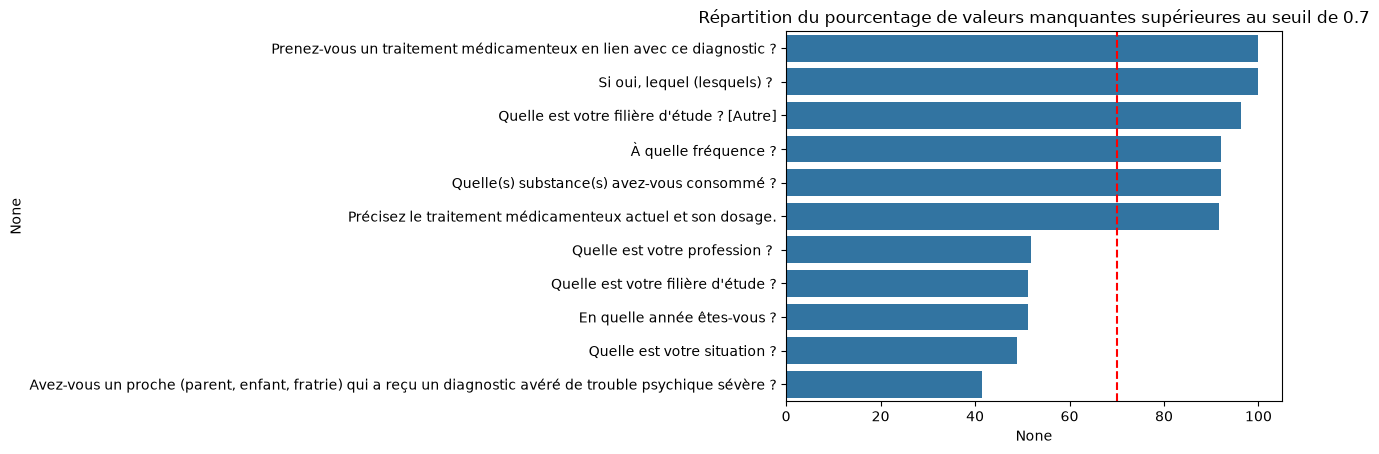

In [779]:
import seaborn as sns
threshold_view = 0.70
percent_missing = (df_SD_PS.isnull().sum() / len(df_SD_PS) * 100).sort_values(ascending=False)
print(percent_missing)
filtered = percent_missing[percent_missing.values > threshold_view]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes supérieures au seuil de {threshold_view}");

threshold = 70

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

Quelle est votre filière d'étude ? [Autre]                                                                    100.000000
À quelle fréquence ?                                                                                           80.000000
Quelle(s) substance(s) avez-vous consommé ?                                                                    80.000000
Quelle est votre profession ?                                                                                  65.714286
Précisez le traitement médicamenteux actuel et son dosage.                                                     62.857143
Quelle est votre situation ?                                                                                   54.285714
Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?     51.428571
Quelle est votre filière d'étude ?                                                                             45.714286
En quelle année êtes-vous ?     

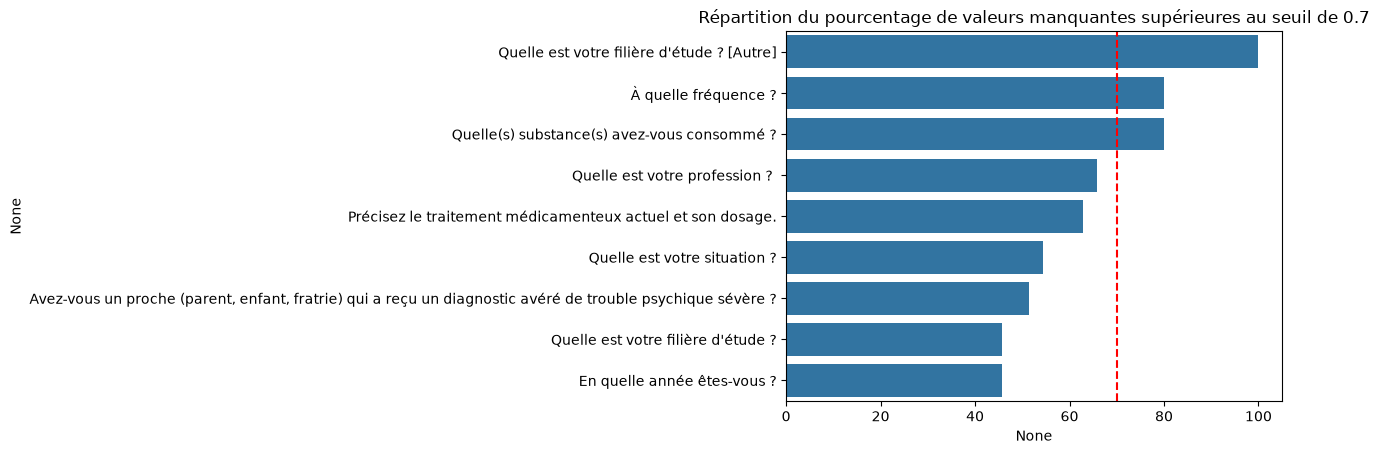

In [780]:
percent_missing = (df_SD_PD.isnull().sum() / len(df_SD_PD) * 100).sort_values(ascending=False)
print(percent_missing)
filtered = percent_missing[percent_missing.values > threshold_view]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes supérieures au seuil de {threshold_view}");
ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

In [781]:
percent_missing = (df_SD_PS.isnull().sum() / len(df_SD_PS) * 100).sort_values(ascending=False)
print(percent_missing)

Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?                                          100.000000
Si oui, lequel (lesquels) ?                                                                                   100.000000
Quelle est votre filière d'étude ? [Autre]                                                                     96.385542
À quelle fréquence ?                                                                                           92.168675
Quelle(s) substance(s) avez-vous consommé ?                                                                    92.168675
Précisez le traitement médicamenteux actuel et son dosage.                                                     91.566265
Quelle est votre profession ?                                                                                  51.807229
Quelle est votre filière d'étude ?                                                                             51.204819
En quelle année êtes-vous ?     

In [782]:
percent_missing = (df_SD_PS.isnull().sum() / len(df_SD_PS) * 100).sort_values(ascending=False)
print(percent_missing)

Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?                                          100.000000
Si oui, lequel (lesquels) ?                                                                                   100.000000
Quelle est votre filière d'étude ? [Autre]                                                                     96.385542
À quelle fréquence ?                                                                                           92.168675
Quelle(s) substance(s) avez-vous consommé ?                                                                    92.168675
Précisez le traitement médicamenteux actuel et son dosage.                                                     91.566265
Quelle est votre profession ?                                                                                  51.807229
Quelle est votre filière d'étude ?                                                                             51.204819
En quelle année êtes-vous ?     

In [783]:
# Compter le nombre de lignes complètement vides (toutes les valeurs sont NaN)
lignes_vides = df_SD_PS.isnull().all(axis=1).sum()
print(f"Nombre de lignes complètement vides : {lignes_vides}")
seuil = len(df_SD_PS) * 0.3 #on supprime tout ce qui a plus de 30% de valeurs manquantes
df_SD_PS.dropna(axis=1, thresh=seuil)

Nombre de lignes complètement vides : 0


,ID de la réponse,Dernière page,Langue de départ,Tête de série,Être bien âgé entre 18 et 65 ans,Avoir un niveau de maitrise suffisant de la langue française,Être dans un moment calme et de disponibilité pour compléter le questionnaire,Quel est votre âge ?,Comment vous identifiez-vous ?,Est-ce la première fois que vous remplissez ce questionnaire?,Êtes-vous étudiant (hors Université du Temps Libre) ?,Quelle est votre situation ?,Quelle est votre filière d'étude ?,Quelle est votre profession ?,En quelle année êtes-vous ?,Quel est votre plus haut niveau de diplôme obtenu ?,Avez-vous déjà reçu un diagnostic psychiatrique dans le passé ou actuellement ?,"Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?","Avez-vous consommé des substances ce dernier mois (hors tabac, alcool et/ou traitements médicamenteux) ?"
1,8,12.0,fr,1664186297,Oui,Oui,Oui,21.0,Femme,Oui,Oui,NaN,Psychologie,NaN,3e année,Baccalauréat,Non,Non,Non
3,10,12.0,fr,1685970839,Oui,Oui,Oui,59.0,Femme,Oui,Non,En emploi,NaN,"Professions intermédiaires (médico-social, enseignement, technicien…)",NaN,Niveau BAC+1,Non,Non,Non
5,12,12.0,fr,1463047385,Oui,Oui,Oui,23.0,Homme,Oui,Oui,NaN,Psychologie,NaN,4e année,Licence,Non,Non,Non
9,16,12.0,fr,1665588914,Oui,Oui,Oui,60.0,Homme,Oui,Non,En emploi,NaN,Cadres et professions intellectuelles supérieures,NaN,Doctorat,Non,Non,Non
10,17,12.0,fr,516102513,Oui,Oui,Oui,44.0,Femme,Oui,Non,En emploi,NaN,Cadres et professions intellectuelles supérieures,NaN,Master,Non,Oui,Non
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,365,12.0,fr,1862242389,Oui,Oui,Oui,33.0,Femme,Oui,Oui,NaN,Psychologie,NaN,4e année,Master,Non,NaN,Non
361,369,12.0,fr,2132038644,Oui,Oui,Oui,21.0,Femme,Oui,Oui,NaN,Psychologie,NaN,3e année,Baccalauréat,Non,NaN,Non
363,371,12.0,fr,1108530346,Oui,Oui,Oui,36.0,Femme,Oui,Oui,NaN,Psychologie,NaN,4e année,Niveau BAC+3,Non,NaN,Non
366,374,12.0,fr,1434745478,Oui,Oui,Oui,48.0,Femme,Oui,Oui,NaN,Psychologie,NaN,4e année,Master,Non,NaN,Non


In [784]:
for col in df_SD_PS.columns:
    print(col, df_SD_PS[col].apply(type).unique())
    

ID de la réponse [<class 'int'>]
Dernière page [<class 'float'>]
Langue de départ [<class 'str'>]
Tête de série [<class 'int'>]
Être bien âgé entre 18 et 65 ans [<class 'str'>]
Avoir un niveau de maitrise suffisant de la langue française  [<class 'str'>]
Être dans un moment calme et de disponibilité pour compléter le questionnaire [<class 'str'>]
Quel est votre âge ? [<class 'float'>]
Comment vous identifiez-vous ?  [<class 'str'>]
Est-ce la première fois que vous remplissez ce questionnaire? [<class 'str'>]
Êtes-vous étudiant (hors Université du Temps Libre) ? [<class 'str'>]
Quelle est votre situation ? [<class 'float'> <class 'str'>]
Quelle est votre filière d'étude ? [<class 'str'> <class 'float'>]
Quelle est votre filière d'étude ? [Autre] [<class 'float'> <class 'str'>]
Quelle est votre profession ?  [<class 'float'> <class 'str'>]
En quelle année êtes-vous ? [<class 'str'> <class 'float'>]
Quel est votre plus haut niveau de diplôme obtenu ? [<class 'str'>]
Avez-vous déjà reçu un

In [785]:
cols_num = df_SD_PS.select_dtypes(include='number').columns
cols_cat = df_SD_PS.select_dtypes(exclude='number').columns

# Imputation

In [786]:
from sklearn.impute import SimpleImputer

imputer_num = SimpleImputer(strategy='mean')
df_SD_PS[cols_num] = imputer_num.fit_transform(df_SD_PS[cols_num])


In [787]:
imputer_cat = SimpleImputer(strategy='constant', fill_value='Inconnu', keep_empty_features=True) #on garde les colonnes vides qu'on remplace par "Inconnu"

df_cat_imputed = pd.DataFrame(
    imputer_cat.fit_transform(df_SD_PS[cols_cat]),
    columns=cols_cat,
    index=df_SD_PS.index
)

df_SD_PS[cols_cat] = df_cat_imputed

In [788]:
print(df_SD_PS.isnull().sum())  # vérification : tout devrait être à 0
df_SD_PS

ID de la réponse                                                                                              0
Dernière page                                                                                                 0
Langue de départ                                                                                              0
Tête de série                                                                                                 0
Être bien âgé entre 18 et 65 ans                                                                              0
Avoir un niveau de maitrise suffisant de la langue française                                                  0
Être dans un moment calme et de disponibilité pour compléter le questionnaire                                 0
Quel est votre âge ?                                                                                          0
Comment vous identifiez-vous ?                                                                          

,ID de la réponse,Dernière page,Langue de départ,Tête de série,Être bien âgé entre 18 et 65 ans,Avoir un niveau de maitrise suffisant de la langue française,Être dans un moment calme et de disponibilité pour compléter le questionnaire,Quel est votre âge ?,Comment vous identifiez-vous ?,Est-ce la première fois que vous remplissez ce questionnaire?,...,En quelle année êtes-vous ?,Quel est votre plus haut niveau de diplôme obtenu ?,Avez-vous déjà reçu un diagnostic psychiatrique dans le passé ou actuellement ?,"Si oui, lequel (lesquels) ?",Prenez-vous un traitement médicamenteux en lien avec ce diagnostic ?,"Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?",Précisez le traitement médicamenteux actuel et son dosage.,"Avez-vous consommé des substances ce dernier mois (hors tabac, alcool et/ou traitements médicamenteux) ?",À quelle fréquence ?,Quelle(s) substance(s) avez-vous consommé ?
1,8.0,12.0,fr,1.664186e+09,Oui,Oui,Oui,21.0,Femme,Oui,...,3e année,Baccalauréat,Non,Inconnu,Inconnu,Non,Inconnu,Non,Inconnu,Inconnu
3,10.0,12.0,fr,1.685971e+09,Oui,Oui,Oui,59.0,Femme,Oui,...,Inconnu,Niveau BAC+1,Non,Inconnu,Inconnu,Non,Inconnu,Non,Inconnu,Inconnu
5,12.0,12.0,fr,1.463047e+09,Oui,Oui,Oui,23.0,Homme,Oui,...,4e année,Licence,Non,Inconnu,Inconnu,Non,Inconnu,Non,Inconnu,Inconnu
9,16.0,12.0,fr,1.665589e+09,Oui,Oui,Oui,60.0,Homme,Oui,...,Inconnu,Doctorat,Non,Inconnu,Inconnu,Non,Inconnu,Non,Inconnu,Inconnu
10,17.0,12.0,fr,5.161025e+08,Oui,Oui,Oui,44.0,Femme,Oui,...,Inconnu,Master,Non,Inconnu,Inconnu,Oui,Bipolarité,Non,Inconnu,Inconnu
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,365.0,12.0,fr,1.862242e+09,Oui,Oui,Oui,33.0,Femme,Oui,...,4e année,Master,Non,Inconnu,Inconnu,Inconnu,Inconnu,Non,Inconnu,Inconnu
361,369.0,12.0,fr,2.132039e+09,Oui,Oui,Oui,21.0,Femme,Oui,...,3e année,Baccalauréat,Non,Inconnu,Inconnu,Inconnu,Inconnu,Non,Inconnu,Inconnu
363,371.0,12.0,fr,1.108530e+09,Oui,Oui,Oui,36.0,Femme,Oui,...,4e année,Niveau BAC+3,Non,Inconnu,Inconnu,Inconnu,Inconnu,Non,Inconnu,Inconnu
366,374.0,12.0,fr,1.434745e+09,Oui,Oui,Oui,48.0,Femme,Oui,...,4e année,Master,Non,Inconnu,Inconnu,Inconnu,Inconnu,Non,Inconnu,Inconnu


# Visu des données socio demo

In [789]:
var_int = ['Quel est votre âge ?', 'Comment vous identifiez-vous ?\xa0', 'En quelle année êtes-vous ?', 'Quel est votre plus haut niveau de diplôme obtenu ?', 'Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?', 'Avez-vous consommé des substances ce dernier mois (hors tabac, alcool et/ou traitements médicamenteux) ?', 'À quelle fréquence ?', 'Quelle(s) substance(s) avez-vous consommé ?']

In [790]:
df_SD_PD['Êtes-vous étudiant (hors Université du Temps Libre) ?'].value_counts(normalize=True) * 100

Êtes-vous étudiant (hors Université du Temps Libre) ?
Oui    54.285714
Non    45.714286
Name: proportion, dtype: float64

In [ ]:

df_oui = df_SD_PS[df_SD_PS['Êtes-vous étudiant (hors Université du Temps Libre) ?'] == 'Oui']

df_oui['Quelle est votre filière d\'étude ?'].value_counts()

Quelle est votre filière d'étude ?
Psychologie                                       56
Autre                                              6
Biologie, Chimie, Mathématiques, Physique          6
Etudes de Santé                                    4
STAPS                                              3
Sciences Humaines et Sociales hors Psychologie     2
Art                                                2
Droit et Sciences politiques                       1
Marketing et Communication                         1
Name: count, dtype: int64

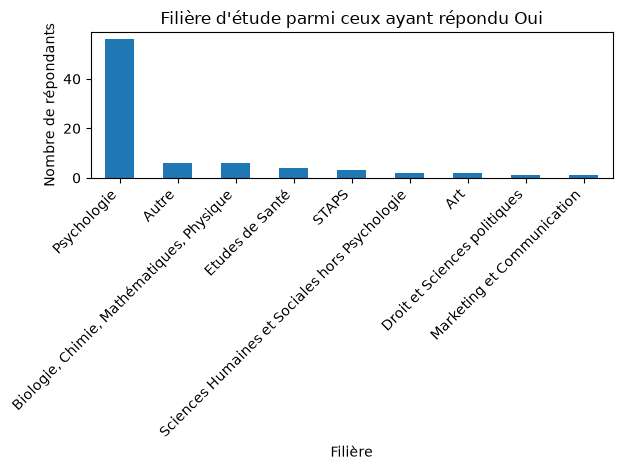

In [792]:
import matplotlib.pyplot as plt

df_oui['Quelle est votre filière d\'étude ?'].value_counts().plot(kind='bar')
plt.title("Filière d'étude parmi ceux ayant répondu Oui")
plt.xlabel("Filière")
plt.ylabel("Nombre de répondants")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

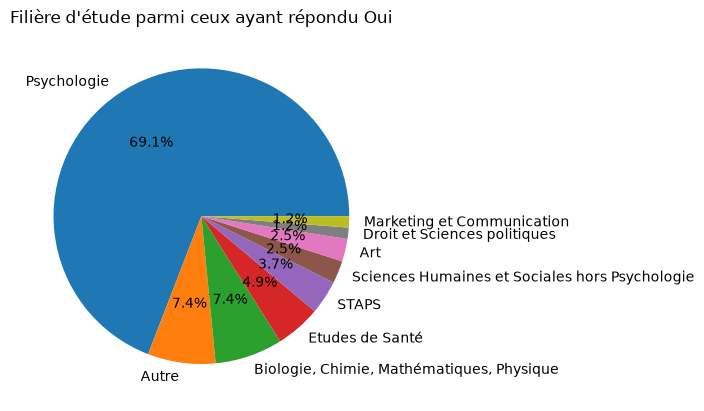

In [793]:
df_oui['Quelle est votre filière d\'étude ?'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Filière d'étude parmi ceux ayant répondu Oui")
plt.ylabel('')
plt.show()

In [794]:
df_SD_PS['Quel est votre âge ?'].describe()

count    166.000000
mean      33.554217
std       13.047004
min       20.000000
25%       22.000000
50%       27.500000
75%       43.750000
max       62.000000
Name: Quel est votre âge ?, dtype: float64

In [795]:
import pandas as pd
from scipy.stats import chi2_contingency
 
table = pd.crosstab(
pd.concat([
pd.Series("PS", index=df_SD_PS.index),
pd.Series("PD", index=df_SD_PD.index)
]),
pd.concat([
df_SD_PS['Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?'],
df_SD_PD['Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?']
])
)
 
print(table)
 
chi2, p, ddl, expected = chi2_contingency(table)
 
print(f"χ² = {chi2:.2f}")
print(f"ddl = {ddl}")
print(f"p = {p:.3f}")

Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?  Inconnu  \
row_0                                                                                                                 
PD                                                                                                                0   
PS                                                                                                               69   

Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?  Non  \
row_0                                                                                                             
PD                                                                                                           14   
PS                                                                                                           82   

Avez-vous un proche (parent, enfant, fratrie) qui a reçu un di

In [796]:
from scipy.stats import ttest_ind
 
resultat = ttest_ind(
df_SD_PS['Quel est votre âge ?'],
df_SD_PD['Quel est votre âge ?'],
equal_var=False,
nan_policy="omit"
)
 
print(resultat)


TtestResult(statistic=np.float64(1.1321296828754681), pvalue=np.float64(0.26242342994797735), df=np.float64(55.779295692537744))


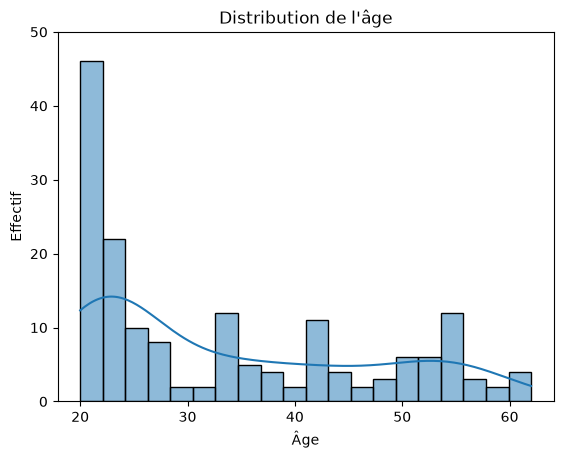

In [797]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_SD_PS['Quel est votre âge ?'].dropna(), kde=True, bins=20)
plt.xlabel('Âge')
plt.ylabel('Effectif')
plt.title('Distribution de l\'âge')
plt.ylim(0, 50)
plt.show()

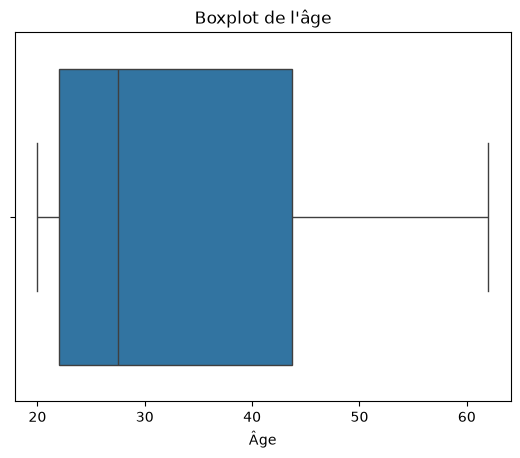

In [798]:
sns.boxplot(x=df_SD_PS['Quel est votre âge ?'])
plt.xlabel('Âge')
plt.title('Boxplot de l\'âge')
plt.show()

In [799]:

df_SD_PS['Comment vous identifiez-vous ?\xa0'].value_counts()

Comment vous identifiez-vous ? 
Femme          125
Homme           40
Non-binaire      1
Name: count, dtype: int64

In [800]:
for i in var_int:
    print(f"Question : {i}")
    print(df_SD_PS[i].value_counts())
    print("\n")

Question : Quel est votre âge ?
Quel est votre âge ?
20.0    16
21.0    15
22.0    15
24.0    12
23.0    10
33.0     9
55.0     9
25.0     7
27.0     5
50.0     5
42.0     5
53.0     4
60.0     3
26.0     3
36.0     3
28.0     3
43.0     3
54.0     3
41.0     3
34.0     3
38.0     3
59.0     2
44.0     2
49.0     2
35.0     2
52.0     2
47.0     2
30.0     2
57.0     2
40.0     2
45.0     2
56.0     1
51.0     1
32.0     1
31.0     1
62.0     1
37.0     1
48.0     1
Name: count, dtype: int64


Question : Comment vous identifiez-vous ? 
Comment vous identifiez-vous ? 
Femme          125
Homme           40
Non-binaire      1
Name: count, dtype: int64


Question : En quelle année êtes-vous ?
En quelle année êtes-vous ?
Inconnu      85
3e année     38
4e année     17
5e année     14
2e année      4
8 ou plus     3
7e année      2
1e année      2
6e année      1
Name: count, dtype: int64


Question : Quel est votre plus haut niveau de diplôme obtenu ?
Quel est votre plus haut niveau de dipl

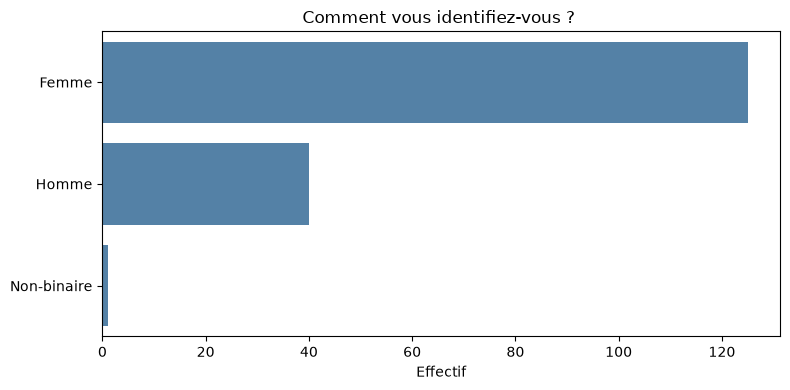

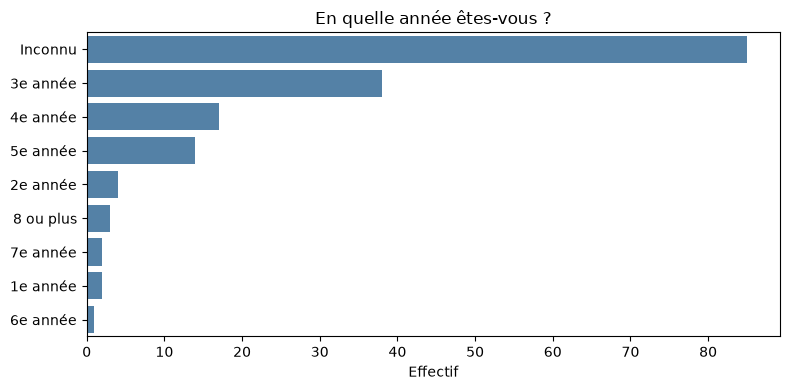

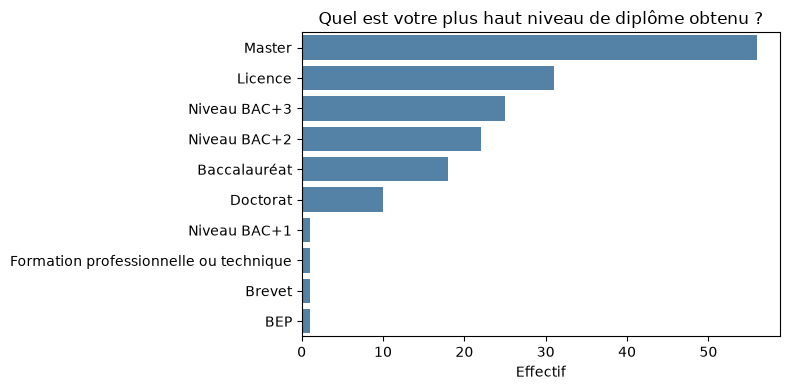

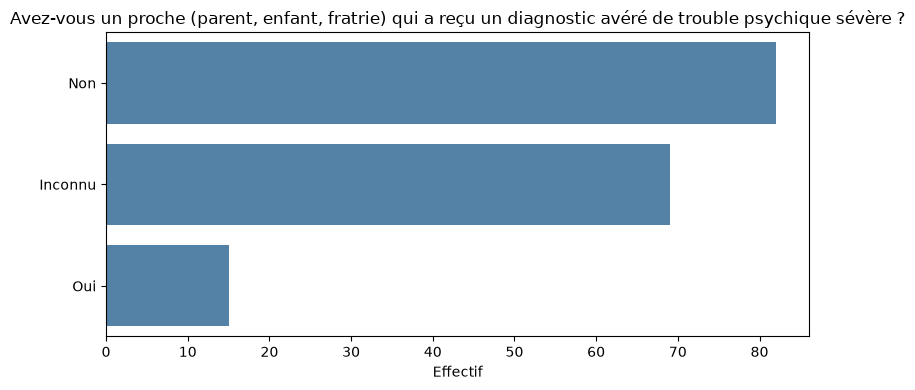

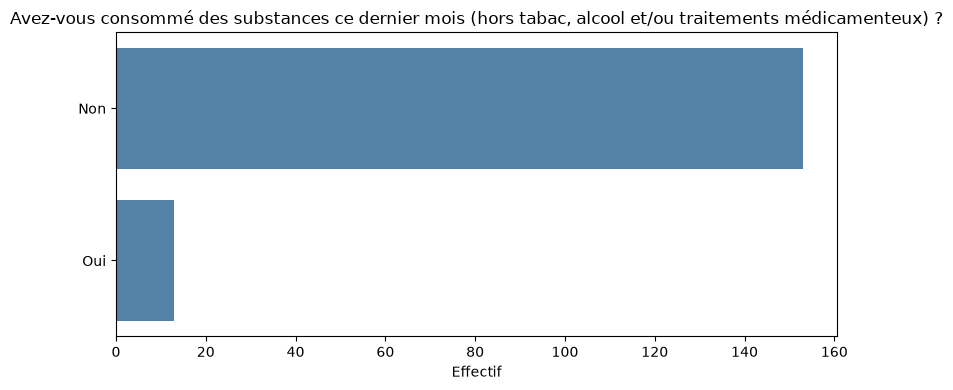

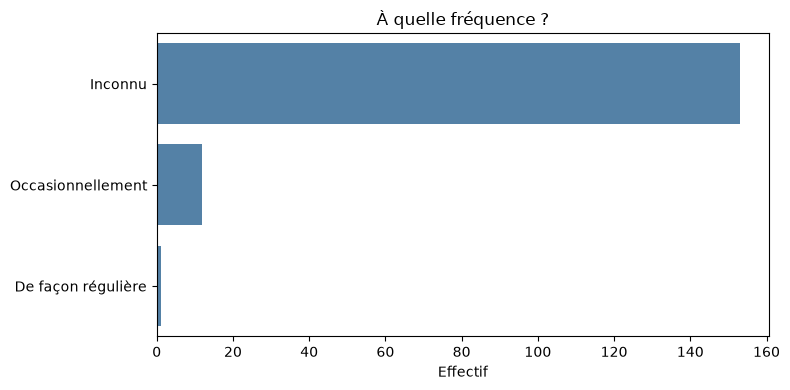

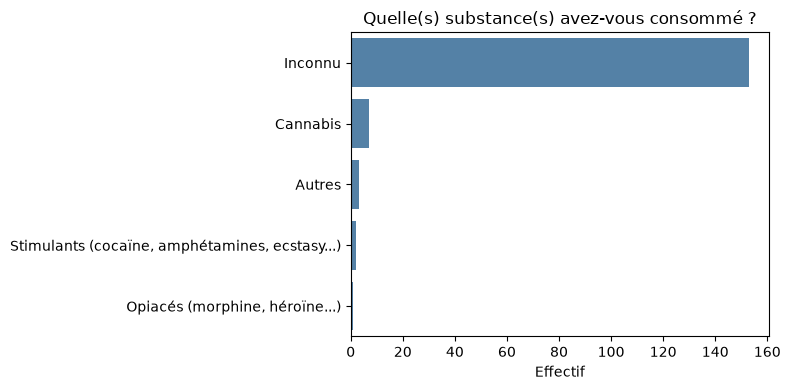

In [801]:
import seaborn as sns
import matplotlib.pyplot as plt

colonnes = [
    'Comment vous identifiez-vous ?\xa0',
    'En quelle année êtes-vous ?',
    'Quel est votre plus haut niveau de diplôme obtenu ?',
    'Avez-vous un proche (parent, enfant, fratrie) qui a reçu un diagnostic avéré de trouble psychique sévère ?',
    'Avez-vous consommé des substances ce dernier mois (hors tabac, alcool et/ou traitements médicamenteux) ?',
    'À quelle fréquence ?',
    'Quelle(s) substance(s) avez-vous consommé ?'
]

for col in colonnes:
    plt.figure(figsize=(8, 4))
    order = df_SD_PS[col].value_counts().index  # trie les barres par fréquence décroissante
    sns.countplot(y=df_SD_PS[col], order=order, color='steelblue')
    plt.xlabel('Effectif')
    plt.ylabel('')
    plt.title(col)
    plt.tight_layout()
    plt.show()

In [802]:
for col in colonnes:
    print(f"\n--- {col} ---")
 
    tableau = pd.DataFrame({
    "Effectif": df_SD_PS[col].value_counts(),
    "Pourcentage": (df_SD_PS[col].value_counts(normalize=True) * 100).round(1)
    })
     
    print(tableau)


--- Comment vous identifiez-vous ?  ---
                                 Effectif  Pourcentage
Comment vous identifiez-vous ?                        
Femme                                 125         75.3
Homme                                  40         24.1
Non-binaire                             1          0.6

--- En quelle année êtes-vous ? ---
                             Effectif  Pourcentage
En quelle année êtes-vous ?                       
Inconnu                            85         51.2
3e année                           38         22.9
4e année                           17         10.2
5e année                           14          8.4
2e année                            4          2.4
8 ou plus                           3          1.8
7e année                            2          1.2
1e année                            2          1.2
6e année                            1          0.6

--- Quel est votre plus haut niveau de diplôme obtenu ? ---
                         

In [803]:
for col in colonnes:
    print(f"\n--- {col} ---")
 
    tableau = pd.DataFrame({
    "Effectif": df_SD[col].value_counts(),
    "Pourcentage": (df_SD[col].value_counts(normalize=True) * 100).round(1)
    })
     
    print(tableau)


--- Comment vous identifiez-vous ?  ---
                                 Effectif  Pourcentage
Comment vous identifiez-vous ?                        
Femme                                 153         76.1
Homme                                  46         22.9
Non-binaire                             2          1.0

--- En quelle année êtes-vous ? ---
                             Effectif  Pourcentage
En quelle année êtes-vous ?                       
3e année                           45         45.0
4e année                           22         22.0
5e année                           18         18.0
2e année                            5          5.0
8 ou plus                           4          4.0
7e année                            3          3.0
1e année                            2          2.0
6e année                            1          1.0

--- Quel est votre plus haut niveau de diplôme obtenu ? ---
                                                     Effectif  Pourcentage
Q

Pour les participants avec diag

In [804]:
for col in colonnes:
    print(f"\n--- {col} ---")
 
    tableau = pd.DataFrame({
    "Effectif": df_SD_PD[col].value_counts(),
    "Pourcentage": (df_SD_PD[col].value_counts(normalize=True) * 100).round(1)
    })
     
    print(tableau)


--- Comment vous identifiez-vous ?  ---
                                 Effectif  Pourcentage
Comment vous identifiez-vous ?                        
Femme                                  28         80.0
Homme                                   6         17.1
Non-binaire                             1          2.9

--- En quelle année êtes-vous ? ---
                             Effectif  Pourcentage
En quelle année êtes-vous ?                       
3e année                            7         36.8
4e année                            5         26.3
5e année                            4         21.1
8 ou plus                           1          5.3
2e année                            1          5.3
7e année                            1          5.3

--- Quel est votre plus haut niveau de diplôme obtenu ? ---
                                                     Effectif  Pourcentage
Quel est votre plus haut niveau de diplôme obtenu ?                       
Master                      

In [805]:
sexe_col ='Comment vous identifiez-vous ?\xa0'
df_SD_PS["Groupe"] = "PS"
df_SD_PD["Groupe"] = "PD"
 
df = pd.concat([df_SD_PS, df_SD_PD])
 
table = pd.crosstab(df["Groupe"], df[sexe_col])
 
print(table)
from scipy.stats import chi2_contingency
 
chi2, p, ddl, expected = chi2_contingency(table)
 
print("χ² =", chi2)
print("ddl =", ddl)
print("p =", p)

Comment vous identifiez-vous ?   Femme  Homme  Non-binaire
Groupe                                                    
PD                                  28      6            1
PS                                 125     40            1
χ² = 2.171392695370448
ddl = 2
p = 0.3376665706735642


# Faire un df pour échelle BAI

21 items à côter de 0 (pas du tout) à 3 (beaucoup)
→ 0 - 7 = anxiété minimale
→ 8 à 15 = anxiété légère
→ 16 - 25 = anxiété modérée
→ 26 - 63 = anxiété sévère


In [806]:
cols_selection_BAI = df_PS.columns[25:46]  # de la colonne 27 à la colonne 47 incluse (27 + 20 suivantes = 21 colonnes)
print(cols_selection_BAI)
print(len(cols_selection_BAI)) 

Index(['Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [5- Crainte que le pire ne survienne]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [6- Étourdissement ou vertige, désorientation ]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [7- Battements cardiaques marqués ou rapides ]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [8- Mal assuré(e), manque d’assurance dans mes mouvements ]',
       'Au cours des 7 derniers jours, j’ai été affecté(e) par… [9- Terrifié(e)]',
       'Au cours des 7 derniers jo

In [807]:
df_BAI = df_PS[cols_selection_BAI]

In [808]:
cols_selection_BAI = df_PD.columns[25:46] 
df_BAI_PD = df_PD[cols_selection_BAI]

In [809]:
df_BAI_PD["score_total"] = df_BAI_PD.sum(axis=1)

In [810]:
for i, col in enumerate(df_BAI.columns):
    print(i, col)

0 Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]
1 Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]
2 Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]
3 Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]
4 Au cours des 7 derniers jours, j’ai été affecté(e) par… [5- Crainte que le pire ne survienne]
5 Au cours des 7 derniers jours, j’ai été affecté(e) par… [6- Étourdissement ou vertige, désorientation ]
6 Au cours des 7 derniers jours, j’ai été affecté(e) par… [7- Battements cardiaques marqués ou rapides ]
7 Au cours des 7 derniers jours, j’ai été affecté(e) par… [8- Mal assuré(e), manque d’assurance dans mes mouvements ]
8 Au cours des 7 derniers jours, j’ai été affecté(e) par… [9- Terrifié(e)]
9 Au cours des 7 derniers jours, j’ai été affecté(e) par… [10- Nervosité]
10 Au cours des 7 derniers jours

# On va commencer par TT les données manquantes/abbérantes

In [811]:
df_BAI.describe()

,"Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [5- Crainte que le pire ne survienne]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [6- Étourdissement ou vertige, désorientation ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [7- Battements cardiaques marqués ou rapides ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [8- Mal assuré(e), manque d’assurance dans mes mouvements ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [9- Terrifié(e)]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [10- Nervosité]",...,"Au cours des 7 derniers jours, j’ai été affecté(e) par… [12- Tremblements des mains]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [13- Tremblements, chancelant(e) ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [14- Crainte de perdre le contrôle de soi]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [15- Respiration difficile ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [16- Peur de mourir ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [17- Sensation de peur, «avoir la frousse»]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [18- Indigestion ou malaise abdominal ]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [19- Sensation de défaillance ou d’évanouissement]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [20- Rougissement du visage]","Au cours des 7 derniers jours, j’ai été affecté(e) par… [21- Transpiration (non associé(e) à la chaleur) ]"
count,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,...,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,0.409639,0.698795,0.343373,1.198795,0.867470,0.433735,0.746988,0.373494,0.204819,1.228916,...,0.265060,0.066265,0.343373,0.403614,0.246988,0.373494,0.686747,0.192771,0.463855,0.608434
std,0.661241,0.930753,0.629708,0.935624,1.006296,0.733489,0.938643,0.636484,0.556156,0.931929,...,0.573862,0.294094,0.693816,0.738376,0.607396,0.664436,0.872860,0.491327,0.727316,0.784502
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000,...,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000,3.000000


In [812]:
# Compter le nombre de lignes complètement vides (toutes les valeurs sont NaN)
lignes_vides = df_BAI.isnull().all(axis=1).sum()
print(f"Nombre de lignes complètement vides : {lignes_vides}")
percent_missing = (df_BAI.isnull().sum() / len(df_BAI) * 100).sort_values(ascending=False)
print(percent_missing)
# rien n'est vide, on peut donc continuer avec le traitement 

Nombre de lignes complètement vides : 0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]            0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]                                       0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]          0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]                                 0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [5- Crainte que le pire ne survienne]                          0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [6- Étourdissement ou vertige, désorientation ]                0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [7- Battements cardiaques marqués ou rapides ]                 0.0
Au cours des 7 derniers jours, j’ai été affecté(e) par… [8- Mal assuré(e), manque d’assurance dans 

# Visualisation de la répartition des scores

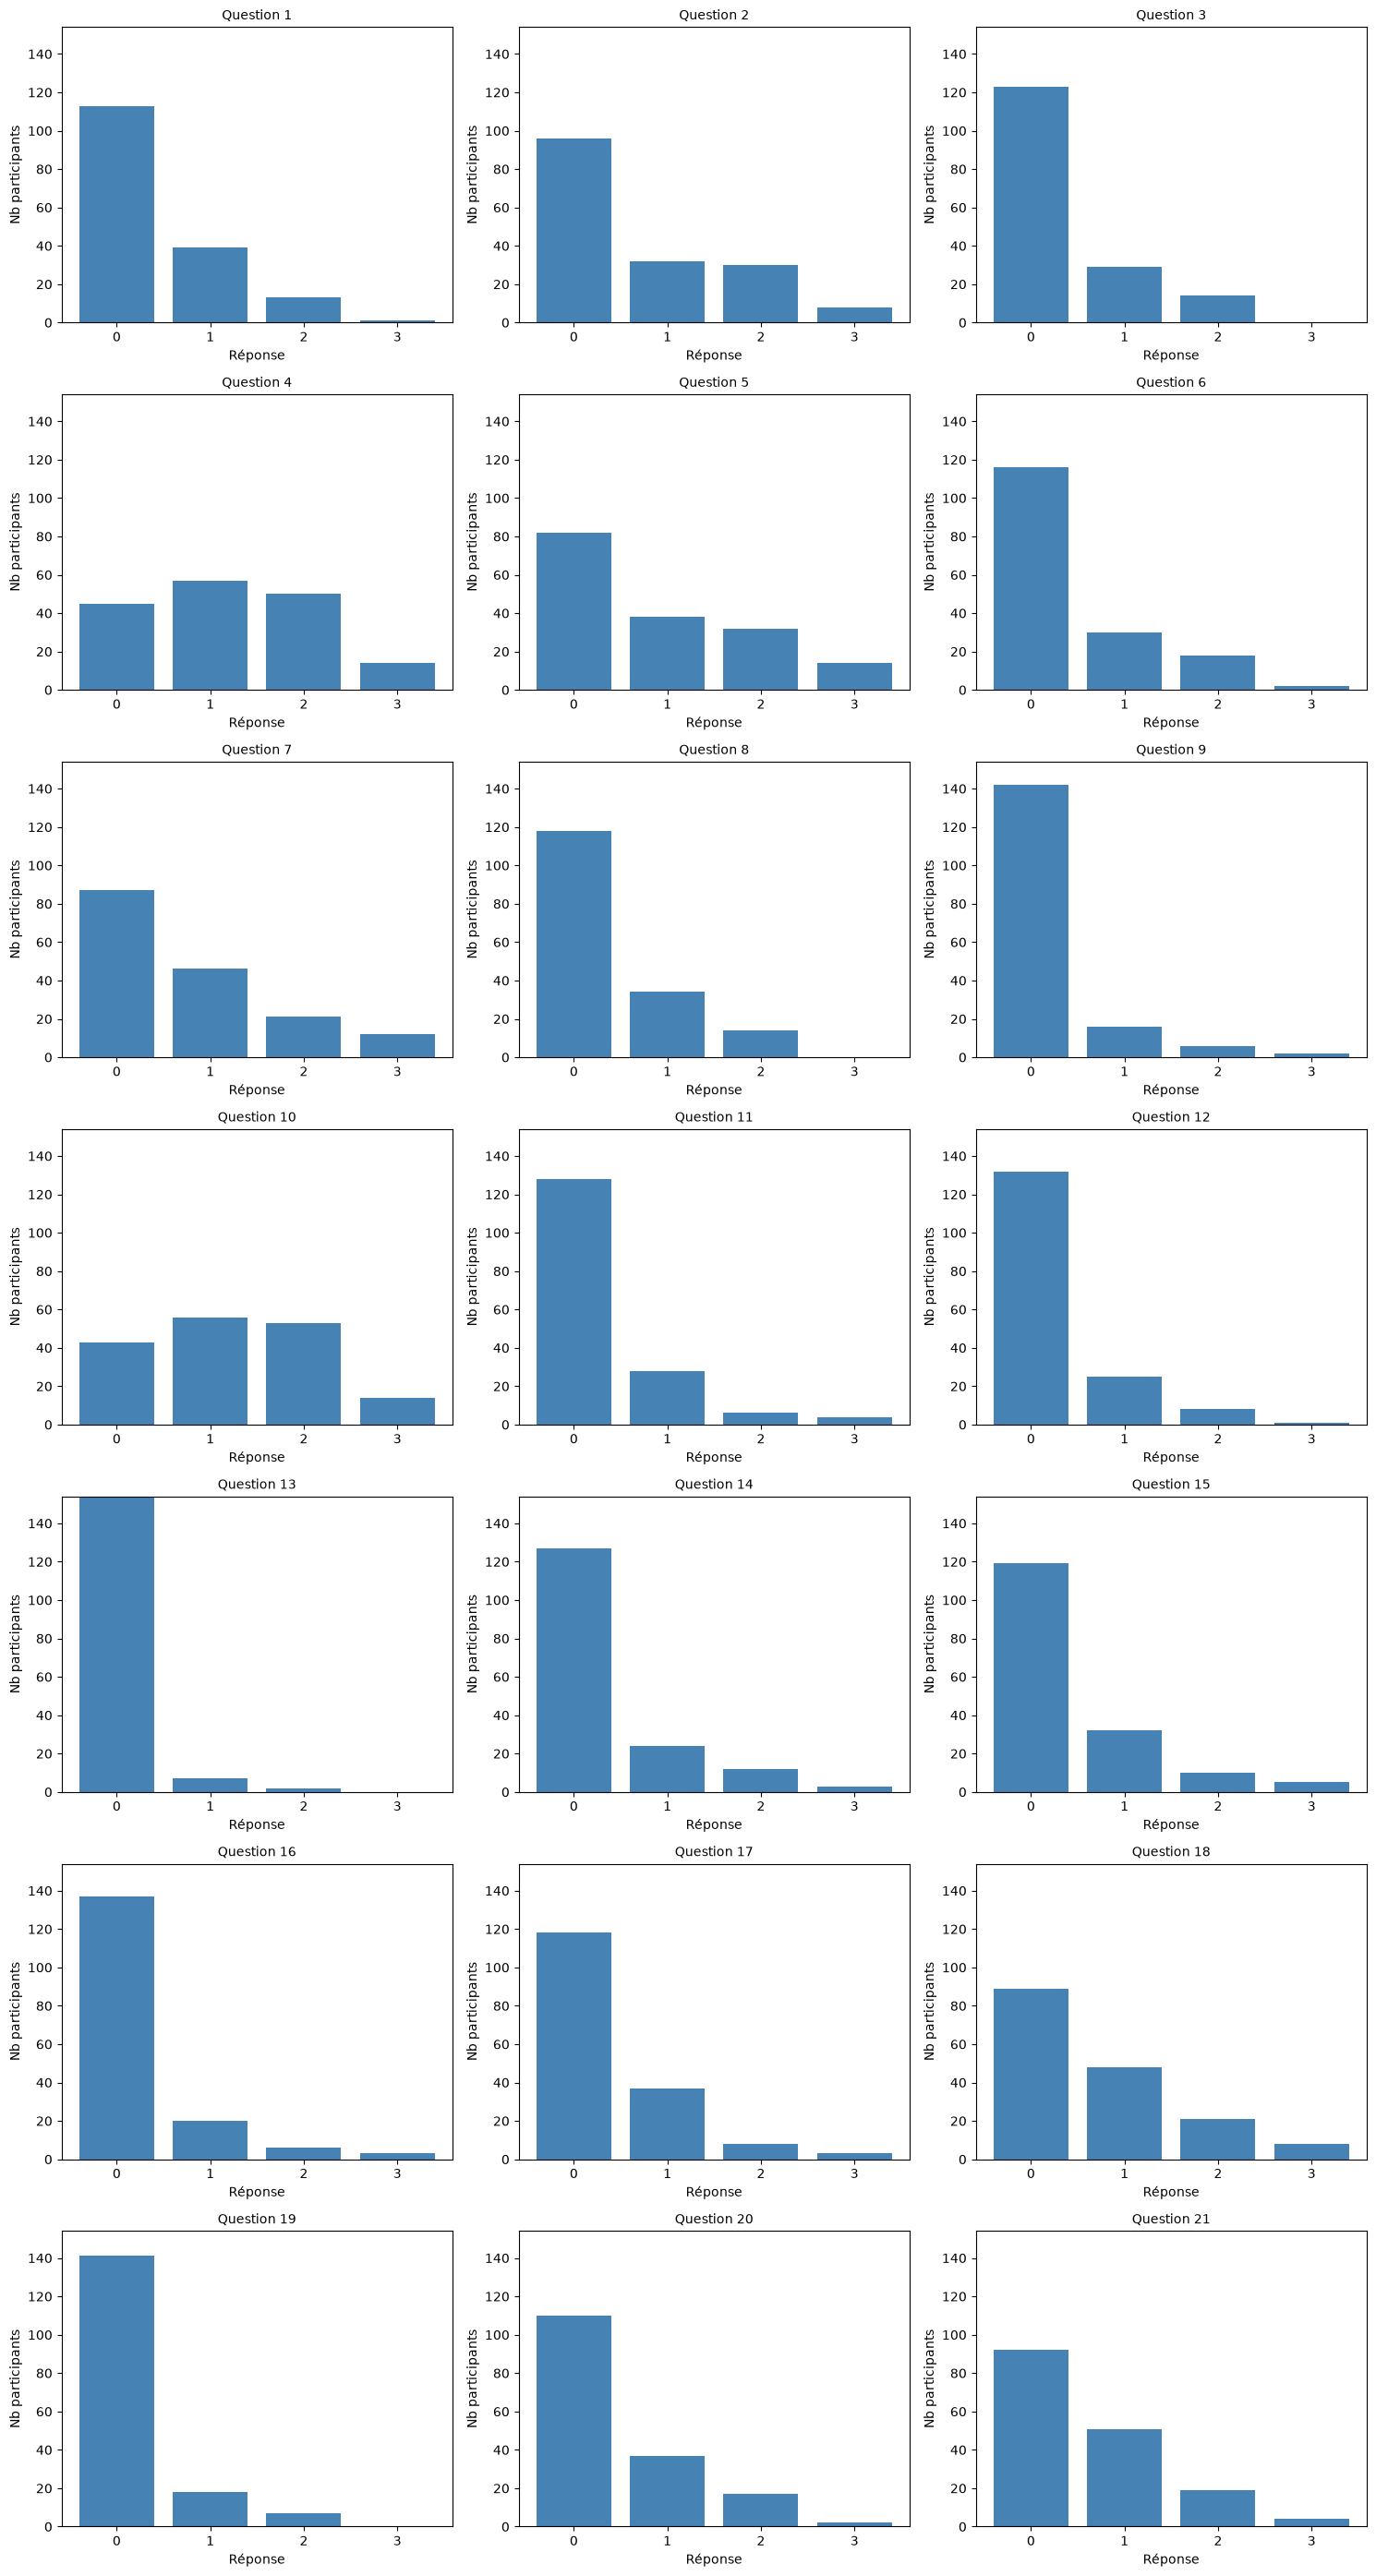

In [ ]:
items = df_BAI.columns.tolist()

n = len(items)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_BAI[q].value_counts().reindex([0, 1, 2, 3], fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks([0, 1, 2, 3])
    axes[i].set_ylim(0, 154)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [814]:
for i in items:
    print(f"Question : {i}")
    print(df_BAI[i].value_counts())
    print("\n")

Question : Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]
Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]
0.0    113
1.0     39
2.0     13
3.0      1
Name: count, dtype: int64


Question : Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]
Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]
0.0    96
1.0    32
2.0    30
3.0     8
Name: count, dtype: int64


Question : Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]
Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]
0.0    123
1.0     29
2.0     14
Name: count, dtype: int64


Question : Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]
Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité

# Répartition des scores totaux

In [ ]:
df_BAI["score_total"] = df_BAI.sum(axis=1)



In [1010]:
df_BAI["score_total"].describe()

count    166.00000
mean      10.46988
std        8.79578
min        0.00000
25%        4.00000
50%        8.00000
75%       14.75000
max       42.00000
Name: score_total, dtype: float64

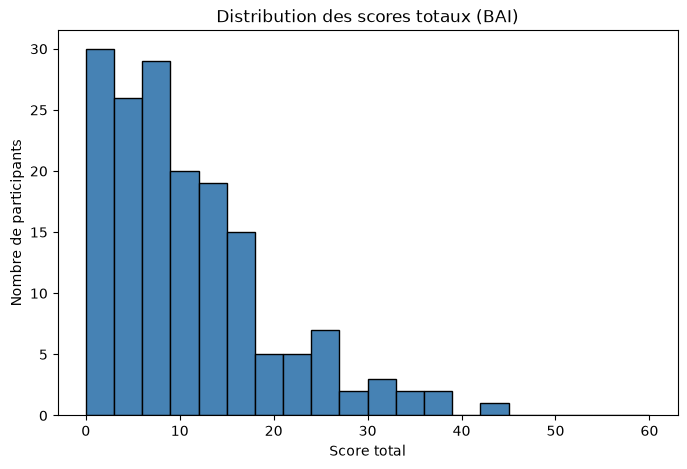

In [817]:
plt.figure(figsize=(8, 5))
plt.hist(df_BAI["score_total"], bins=range(0, 63, 3), color="steelblue", edgecolor="black") #21 × 3 = 63 (score max possible)
plt.xlabel("Score total")
plt.ylabel("Nombre de participants")
plt.title("Distribution des scores totaux (BAI)")
plt.show()

# On va établir des profils de niveau d'anxiété 

In [ ]:
bornes = [0, 7, 15, 25, 63] 
labels = ["Minimale (0-7)", "Légère (8-15)", "Modérée (16-25)", "Sévère (26-63)"]

df_BAI["categorie_anxiete"] = pd.cut(
    df_BAI["score_total"],
    bins=bornes,
    labels=labels,
    include_lowest=True
)


repartition = df_BAI["categorie_anxiete"].value_counts().reindex(labels)
print(repartition)

categorie_anxiete
Minimale (0-7)     74
Légère (8-15)      54
Modérée (16-25)    24
Sévère (26-63)     14
Name: count, dtype: int64


In [819]:
pourcentages = (repartition / len(df_BAI) * 100).round(1)
print(pourcentages)

categorie_anxiete
Minimale (0-7)     44.6
Légère (8-15)      32.5
Modérée (16-25)    14.5
Sévère (26-63)      8.4
Name: count, dtype: float64


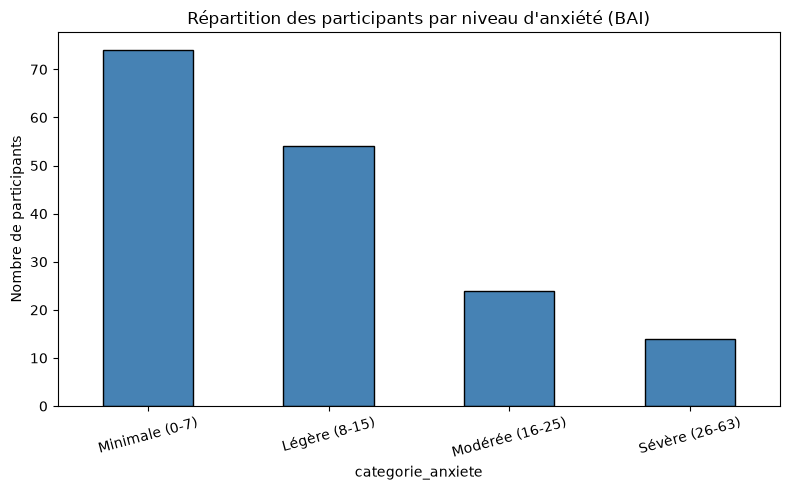

In [820]:
plt.figure(figsize=(8, 5))
repartition.plot(kind="bar", color="steelblue", edgecolor="black")
plt.ylabel("Nombre de participants")
plt.title("Répartition des participants par niveau d'anxiété (BAI)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Relation entre score BAI et info socio demo? 

In [ ]:
df_SD_PS = df_SD_PS.rename(columns={
    "Quel est votre âge ?": "age",
    "Comment vous identifiez-vous ?\xa0": "genre"
})


df_merged = pd.concat([df_BAI[items + ["score_total"]], df_SD_PS[["age", "genre"]]], axis=1)


In [822]:
# correlation age et chq item de BAI
from scipy import stats
resultats = []

for item in items:
    sous_df = df_merged[["age", item]].dropna()
    
    r_pearson, p_pearson = stats.pearsonr(sous_df["age"], sous_df[item])
    rho_spearman, p_spearman = stats.spearmanr(sous_df["age"], sous_df[item])
    
    resultats.append({
        "item": item,
        "pearson_r": round(r_pearson, 3),
        "pearson_p": round(p_pearson, 4),
        "spearman_rho": round(rho_spearman, 3),
        "spearman_p": round(p_spearman, 4)
    })

df_resultats = pd.DataFrame(resultats)
print(df_resultats)

                                                                                                                   item  \
0           Au cours des 7 derniers jours, j’ai été affecté(e) par… [1- Sensations d’engourdissement ou de picotement ]   
1                                      Au cours des 7 derniers jours, j’ai été affecté(e) par… [2- Bouffées de chaleur]   
2         Au cours des 7 derniers jours, j’ai été affecté(e) par… [3- « Jambes molles », tremblements dans les jambes ]   
3                                Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]   
4                         Au cours des 7 derniers jours, j’ai été affecté(e) par… [5- Crainte que le pire ne survienne]   
5               Au cours des 7 derniers jours, j’ai été affecté(e) par… [6- Étourdissement ou vertige, désorientation ]   
6                Au cours des 7 derniers jours, j’ai été affecté(e) par… [7- Battements cardiaques marqués ou rapides ]   
7   Au cours des

In [823]:
# correlation entre age et le total score BAI


# Corrélation de Pearson (relation linéaire)
r, p = stats.pearsonr(df_merged["age"].dropna(), df_merged.loc[df_merged["age"].notna(), "score_total"])
print(f"Pearson r = {r:.3f}, p = {p:.4f}")

# Corrélation de Spearman (plus robuste, ne suppose pas de linéarité)
rho, p = stats.spearmanr(df_merged["age"], df_merged["score_total"], nan_policy="omit")
print(f"Spearman rho = {rho:.3f}, p = {p:.4f}")

Pearson r = -0.361, p = 0.0000
Spearman rho = -0.354, p = 0.0000


Il y a une difference significative d'age pour le score d'anxiete

In [824]:
print(df_merged["genre"].value_counts())

# Moyennes par groupe
print(df_merged.groupby("genre")["score_total"].mean())

# Test statistique (si 2 groupes : test t ; si plus de 2 : ANOVA)
groupes = [g["score_total"].dropna().values for _, g in df_merged.groupby("genre")]

if len(groupes) == 2:
    t, p = stats.ttest_ind(*groupes)
    print(f"Test t : t = {t:.3f}, p = {p:.4f}")
else:
    f, p = stats.f_oneway(*groupes)
    print(f"ANOVA : F = {f:.3f}, p = {p:.4f}")

genre
Femme          125
Homme           40
Non-binaire      1
Name: count, dtype: int64
genre
Femme          11.848
Homme           6.300
Non-binaire     5.000
Name: score_total, dtype: float64
ANOVA : F = 6.649, p = 0.0017


IL y a une difference significative entre les genres en ce qui concerne le score BAI d'anxiete, avec les femmes un score significativement plus élevé. En revanche, bcp plus de femmes ont participé à l'étude, ce qui biaise les resultats. 

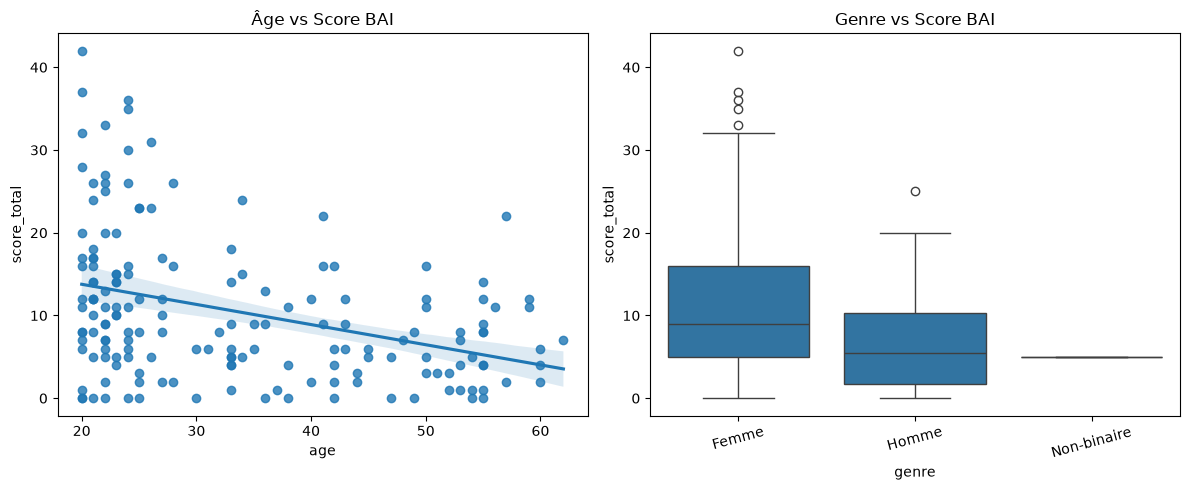

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.regplot(data=df_merged, x="age", y="score_total", ax=axes[0])
axes[0].set_title("Âge vs Score BAI")


sns.boxplot(data=df_merged, x="genre", y="score_total", ax=axes[1])
axes[1].set_title("Genre vs Score BAI")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [826]:

from scipy.stats import shapiro

for g in df_merged["genre"].unique():
    stat, p = shapiro(df_merged[df_merged["genre"] == g]["score_total"])
    print(f"{g} : p = {p:.4f}")

Femme : p = 0.0000
Homme : p = 0.0010
Non-binaire : p = nan


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19564\2498309101.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = shapiro(df_merged[df_merged["genre"] == g]["score_total"])


In [827]:
from scipy.stats import mannwhitneyu
groupe1 = df_merged[df_merged["genre"] == "Homme"]["score_total"]
groupe2 = df_merged[df_merged["genre"] == "Femme"]["score_total"]

stat, p_value = mannwhitneyu(groupe1, groupe2)
print(f"U = {stat:.3f}, p = {p_value:.4f}")

U = 1540.000, p = 0.0003


difference significative entre homme femme selon BAI

* df_PS --> age, sexe 
* df_BAI --> score total 
* Modele lineaire avec score total comme variable dépendante et age et sexe comme variables indépendantes.

In [828]:

import statsmodels.formula.api as smf

model = smf.ols("score_total ~ age + genre", data=df_merged).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            score_total   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     12.37
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           2.49e-07
Time:                        22:46:37   Log-Likelihood:                -578.85
No. Observations:                 166   AIC:                             1166.
Df Residuals:                     162   BIC:                             1178.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               19.2658 

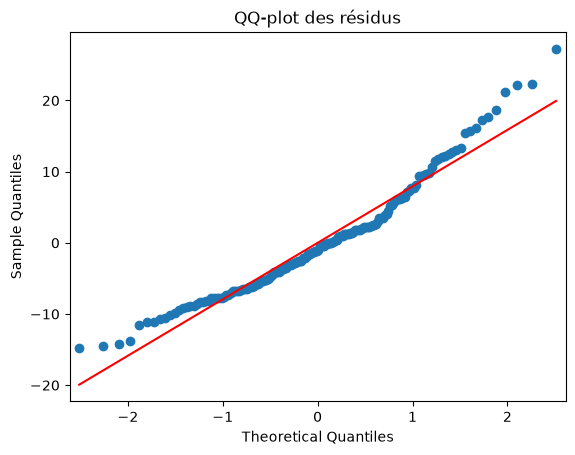

In [829]:

import statsmodels.api as sm
resid = model.resid

# 3. QQ-plot (vérifie la normalité des résidus)
sm.qqplot(resid, line='r')
plt.title('QQ-plot des résidus')
plt.show()

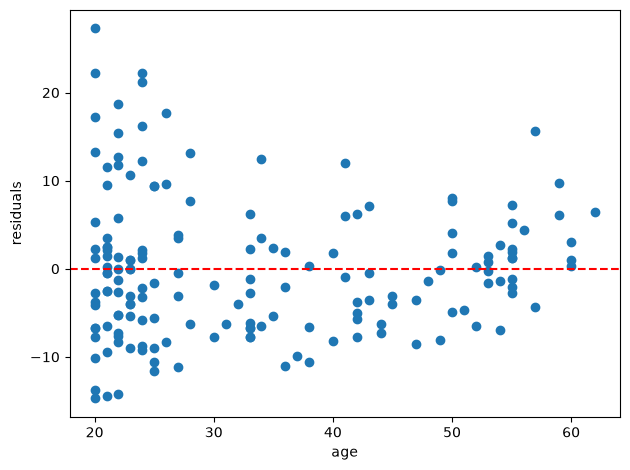

In [ ]:

plt.scatter(df_merged['age'], resid)
plt.xlabel('age')
plt.ylabel('residuals') 
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Extraction df TSQ

In [831]:
cols_TSQ = df_PS.columns[46:87]  # de la colonne 48 à la colonne 88 incluse (48 + 40 suivantes = 40 colonnes)
print(cols_TSQ)
print(len(cols_TSQ)) 

Index(['1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []',
       '2 - J'ai l'impression que le passé est tellement détaché du présent et du futur que c'est comme s'il n'existait pas.  Exemples :" Le futur, le passé et le présent semblent être des îles isolées sans aucun pont entre elles.""Je n'ai pas accès à mon passé.""Je me sens déconnecté(e) de mon propre passé."  []',
       '3 - Je me sens vraiment à cran, comme si j'étais constamment sur mes gardes.  Exemples :"J’ai constamment l’impression, qu'à tout moment, quelque chose de grave pourrait se produire.""Je ne parviens jamais à me détendre.""Je peux difficilement me contrôler face à des mouvements brusques ou lorsque j'entends de

In [832]:

df_TSQ = df_PS[cols_TSQ]

In [833]:

df_TSQ.drop(columns=["Nous vous remercions pour votre engagement et vous invitons à passer à la suite de ce questionnaire.\xa0"], inplace=True) 

il y a une colonne en trop : "nous vous remercions pour votre engagement etc"

In [834]:

for i, col in enumerate(df_TSQ.columns):
    print(i, col)

0 1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []
1 2 - J'ai l'impression que le passé est tellement détaché du présent et du futur que c'est comme s'il n'existait pas.  Exemples :" Le futur, le passé et le présent semblent être des îles isolées sans aucun pont entre elles.""Je n'ai pas accès à mon passé.""Je me sens déconnecté(e) de mon propre passé."  []
2 3 - Je me sens vraiment à cran, comme si j'étais constamment sur mes gardes.  Exemples :"J’ai constamment l’impression, qu'à tout moment, quelque chose de grave pourrait se produire.""Je ne parviens jamais à me détendre.""Je peux difficilement me contrôler face à des mouvements brusques ou lorsque j'entends des sons forts."  []
3 4

In [835]:

df_TSQ.describe()

,"1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus. Exemples :""J'ai le sentiment que le futur est bien trop incertain pour moi.""""Je ressens que le futur est comme bloqué pour moi.""""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."" []","2 - J'ai l'impression que le passé est tellement détaché du présent et du futur que c'est comme s'il n'existait pas. Exemples :"" Le futur, le passé et le présent semblent être des îles isolées sans aucun pont entre elles.""""Je n'ai pas accès à mon passé.""""Je me sens déconnecté(e) de mon propre passé."" []","3 - Je me sens vraiment à cran, comme si j'étais constamment sur mes gardes. Exemples :""J’ai constamment l’impression, qu'à tout moment, quelque chose de grave pourrait se produire.""""Je ne parviens jamais à me détendre.""""Je peux difficilement me contrôler face à des mouvements brusques ou lorsque j'entends des sons forts."" []","4 - Parfois, certaines parties de mon corps me semblent étranges, comme si elles ne m'appartenaient pas ou avaient été déconnectées les unes des autres, ou même comme si elles n'existaient pas du tout. Exemples :""J’ai l'étrange sentiment qu'il s'agit du corps de quelqu’un d’autre.""""Mon corps semble mort.""""Mon corps et/ou ses parties me sont étrangers et peuvent même me donner l'impression d'appartenir à quelqu'un d'autre."" []","5 - Parfois, j'ai l'impression qu'il y a un espace énorme entre ce qu'il s'est passé avant par rapport à ce qu'il se passe maintenant ou pourrait se passer après. C'est que j'ai tellement de mauvais souvenirs qu'il m'est difficile de me concentrer sur autre chose que le passé. Exemples :""Le passé m'importe chaque jour, ce qui me cause beaucoup de stress.""""Ma vie quotidienne est influencée par des milliers de souvenirs.""""Mes souvenirs du passé me bloquent dans le présent.""""Les souvenirs du passé me submergent et ne me laissent aucun répit."" []","6 - Parmi le passé, le présent et le futur, c'est le présent qui m'accable le plus. Exemples :""J’ai l'impression d’être enfermé(e) dans le présent.""""J'ai l'impression de ne pouvoir accéder ni au passé ni au futur.""""Je sens que je suis exclu(e) du passé ou que mon avenir est coincé dans le moment présent."" []","7 - Même dans des endroits que je connais bien, je me sens parfois complètement perdu(e) ou désorienté(e), n'étant pas certain(e) de comment avancer ou reculer. C'est comme si j'étais constamment désorienté(e) et confus(e). Exemples :""Il m'est arrivé de me promener sans savoir où j'étais.""""Je n'arrive pas à trouver mon chemin ; je perds souvent mes repères et ne sais ni où aller ni comment avancer.""""J'ai souvent l'impression d'être coincé(e) et paralysé(e) dans certaines positions et moments précis.""""Je ne peux pas décider où aller et comment y aller."" []","8 - Je me sens déconnecté(e) et désynchronisé(e) de moi-même, notamment de mes pensées, émotions et souvenirs. Exemples :""Je me sens déconnecté(e) de mes propres pensées, qui sont sans rapport avec moi même.""""Mes émotions me semblent étrangères, sans lien avec moi-même.""""Mon esprit ressemble à un orchestre dont les différents instruments ne jouent pas du tout ensemble.""""Je ne suis pas du tout en phase/harmonie avec moi-même."" []","9 - Je suis inquiet(e) des changements dans ma vie, et me sens submergé(e). Exemples :""C’est comme si mon esprit était rempli d’une musique cacophonique au volume sonore de plus en plus fort.""""Si je devais peindre ce que je ressens dans mes mauvais moments, je peindrais un tableau entièrement noir avec moi à peine coloré(e) au centre.""""Je me sens complètement submergé(e) par mes propres émotions et pensées."" []","10 - J'ai souvent le sentiment que le futur contient une série de menaces, comme si je savais que quelque chose de grave allait arriver imminemment. Exemples :""L'avenir me semble dangereux.""""J'évite de penser à l'avenir.""""Je suis i

In [ ]:

lignes_vides = df_TSQ.isnull().all(axis=1).sum()
print(f"Nombre de lignes complètement vides : {lignes_vides}")
percent_missing = (df_TSQ.isnull().sum() / len(df_TSQ) * 100).sort_values(ascending=False)
print(percent_missing)
# rien n'est vide, on peut donc continuer avec le traitement 

Nombre de lignes complètement vides : 0
1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []                                                                                                                                                                                                                                                                                                                                                                                                                                                       0.0
2 - J'ai l'impression que le passé est tellement détaché du présent et du futur que c'est comme s'il n'existait pas.  Exemples :" Le futur, le passé et le présent s

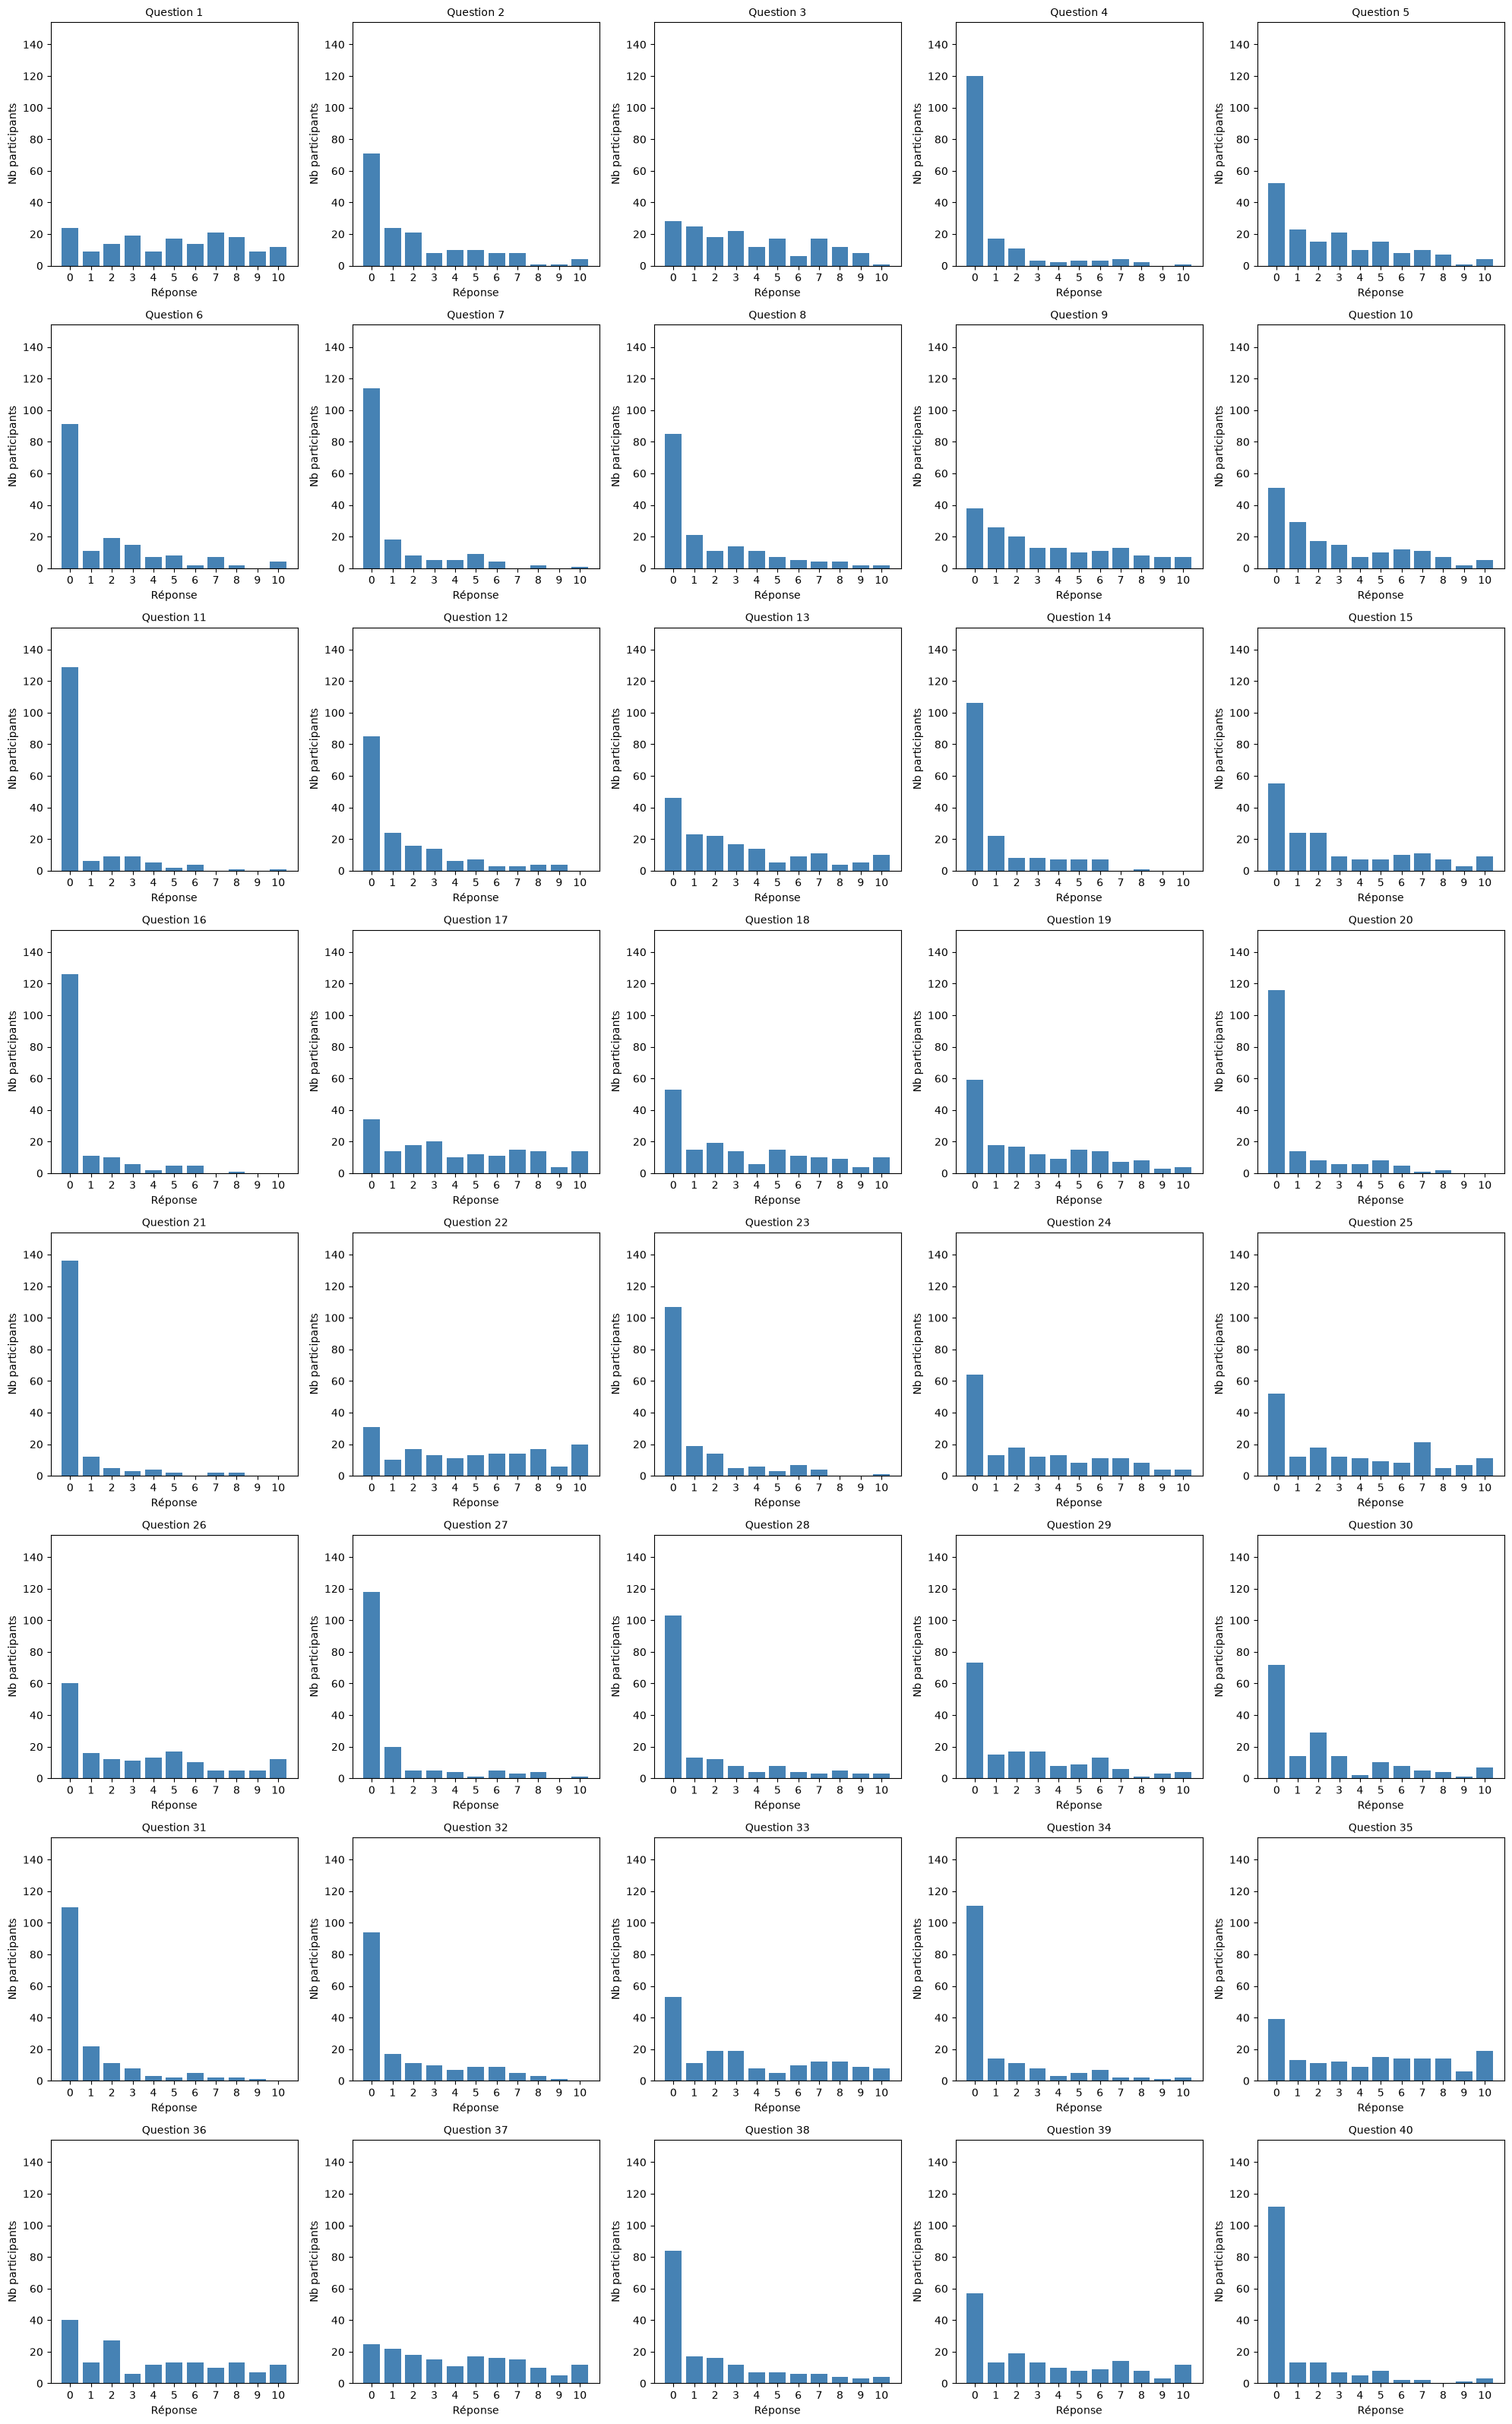

In [837]:

items = df_TSQ.columns.tolist()
df_TSQ[items] = df_TSQ[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(0, 11))  

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_TSQ[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 154)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [838]:

for i in items:
    print(f"Question : {i}")
    print(df_TSQ[i].value_counts())
    print("\n")

Question : 1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []
1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []
0.0     24
7.0     21
3.0     19
8.0     18
5.0     17
2.0     14
6.0     14
10.0    12
1.0      9
4.0      9
9.0      9
Name: count, dtype: int64


Question : 2 - J'ai l'impression que le passé est tellement détaché du présent et du futur que c'est comme s'il n'existait pas.  Exe

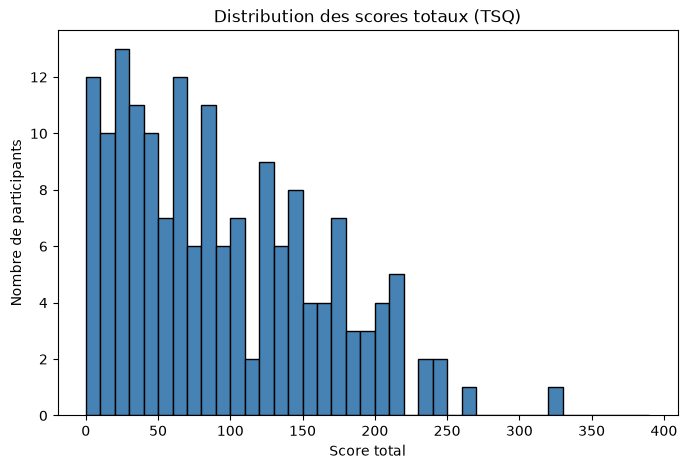

In [839]:
df_TSQ["score_total"] = df_TSQ.sum(axis=1)
df_TSQ["score_total"] = df_TSQ[items].sum(axis=1)
df_TSQ["score_total"].describe()

plt.figure(figsize=(8, 5))
plt.hist(df_TSQ["score_total"], bins=range(0, 400, 10), color="steelblue", edgecolor="black") #10 x40  = 400 (score max possible)
plt.xlabel("Score total")
plt.ylabel("Nombre de participants")
plt.title("Distribution des scores totaux (TSQ)")
plt.show()

# voir le score des participants avec diag pour établir un seuil "élevé" à la TSQ pour les participants sains. Avoir comme une reference

In [840]:
df_TSQ_PD = df_PD[cols_TSQ]
df_TSQ_PD.drop(columns=["Nous vous remercions pour votre engagement et vous invitons à passer à la suite de ce questionnaire.\xa0"], inplace=True) 

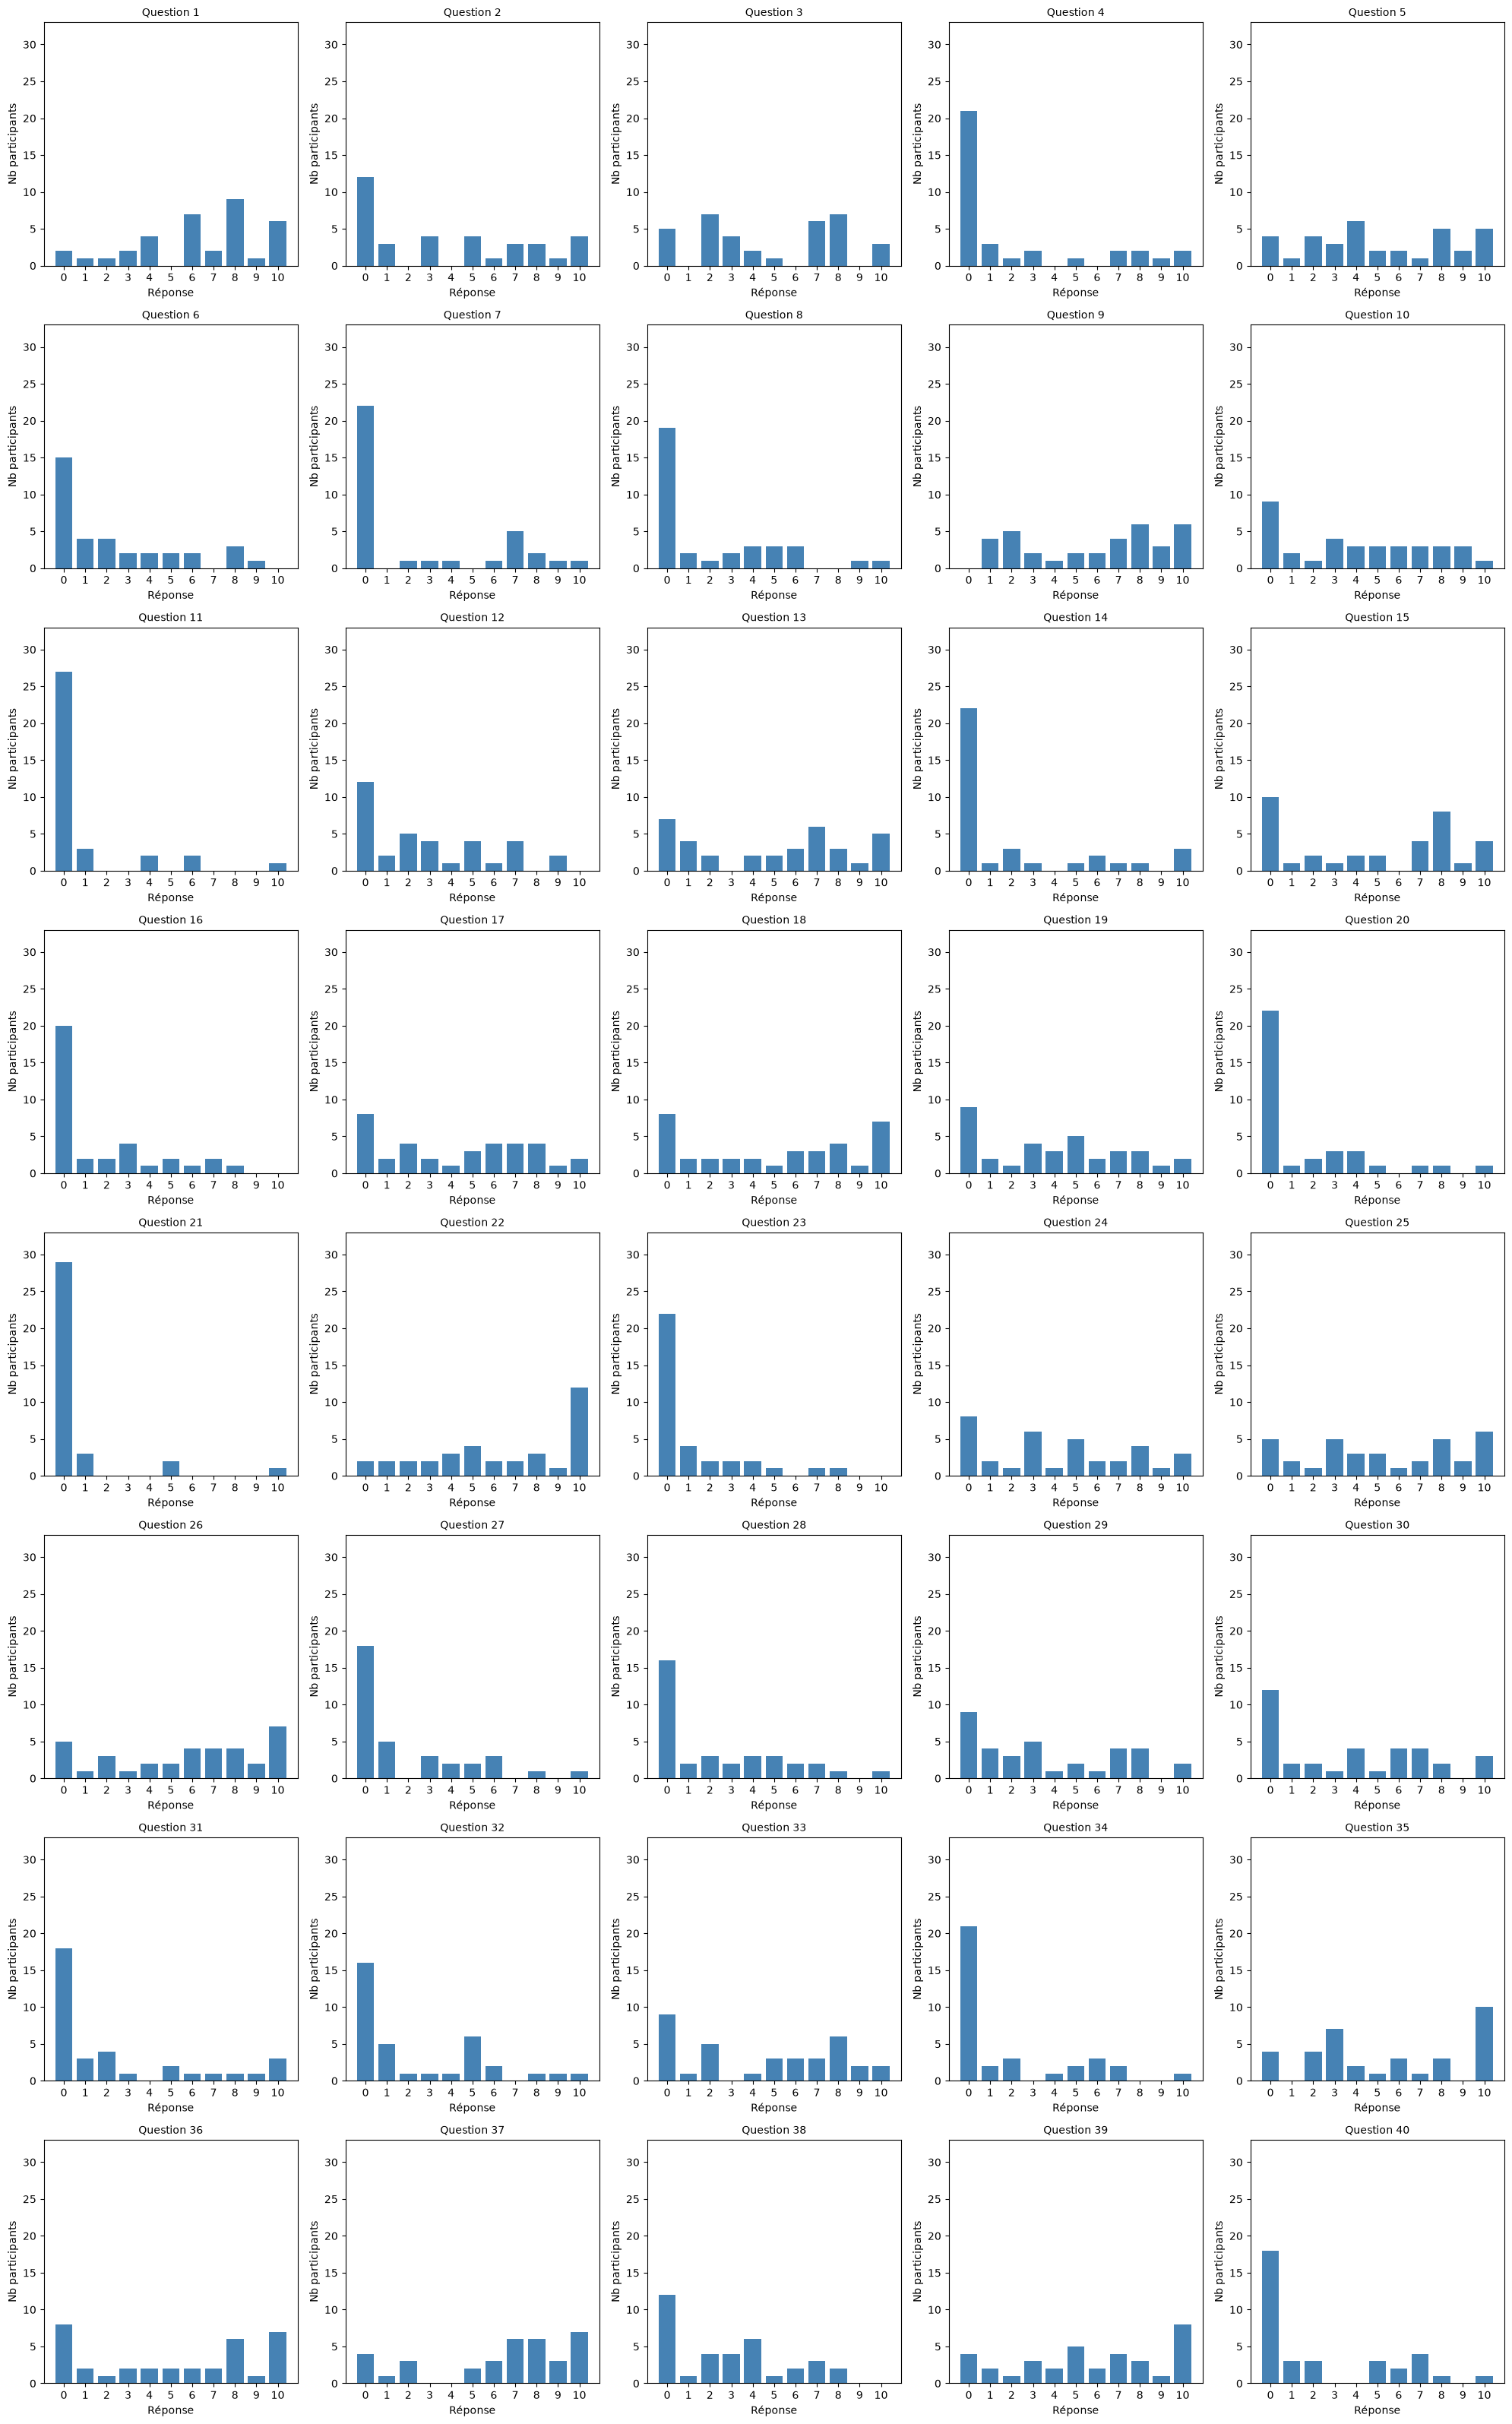

In [841]:
items = df_TSQ_PD.columns.tolist()
df_TSQ_PD[items] = df_TSQ_PD[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(0, 11))  

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_TSQ_PD[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 33)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [842]:
for i in items:
    print(f"Question : {i}")
    print(df_TSQ_PD[i].value_counts())
    print("\n")


Question : 1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []
1 - Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas avoir de vision claire dessus.  Exemples :"J'ai le sentiment que le futur est bien trop incertain pour moi.""Je ressens que le futur est comme bloqué pour moi.""Je n'ai pas idée de ce qui peut arriver dans le futur, je focalise sur le présent ou le passé."  []
8.0     9
6.0     7
10.0    6
4.0     4
0.0     2
3.0     2
7.0     2
1.0     1
9.0     1
2.0     1
Name: count, dtype: int64


Question : 2 - J'ai l'impression que le passé est tellement détaché du présent et du futur que c'est comme s'il n'existait pas.  Exemples :" Le futur, le

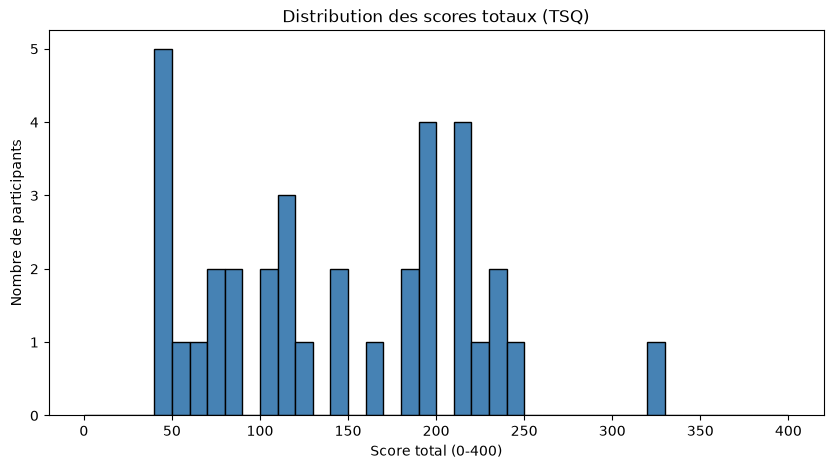

In [843]:
df_TSQ_PD["score_total"] = df_TSQ_PD[items].sum(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(df_TSQ_PD["score_total"], bins=range(0, 401, 10), color="steelblue", edgecolor="black")
plt.xlabel("Score total (0-400)")
plt.ylabel("Nombre de participants")
plt.title("Distribution des scores totaux (TSQ)")
plt.show()

In [844]:
df_TSQ["score_total"].median()

np.float64(81.0)

In [ ]:
df_TSQ_PD["score_total"].median()
df_TSQ_PD["score_total"].describe()

np.float64(141.0)

# OK on va prendre la moyene = 145 comme seuil

In [846]:
# voir si les participants qui ont des scores élevés sur le TSQ ont aussi des score élevés sur le BAI
# prendre un seuil = quand est ce que le score est considéré élevé
# sélectionner les personnes qui ont ces scores
# prendre les personnes qui ont des profils BAI modérés et sévères et comparer si ce sont les memes personness (scores cote à cote pour chaque indiv)

In [ ]:

profils_eleves_bai = df_BAI["categorie_anxiete"].isin(["Modérée (16-25)", "Sévère (26-63)"])
score_eleve_tsq = df_TSQ["score_total"] > 145
print(len(df_BAI), len(df_TSQ))

166 166


In [ ]:
comparaison = pd.DataFrame({
    "BAI_eleve": profils_eleves_bai.values,
    "TSQ_eleve": score_eleve_tsq.values
})

tableau_croise = pd.crosstab(comparaison["BAI_eleve"], comparaison["TSQ_eleve"])
print(tableau_croise)

TSQ_eleve  False  True 
BAI_eleve              
False        108     20
True          20     18


26/154 participants sains qui ont de l'anxiété élevée ont des scores TSQ élevés. 7/154 personnes qui ont de l'anxiété élevée n'ont pas des scores TSQ élevées. 85/154 n'ont pas d'anxiété elevée ni des scores TSQ élevés. 36/154 ont un score TSQ élevé sans avoir d'anxiété élevé. 

In [ ]:
n_total = len(comparaison)
n_bai_eleve = profils_eleves_bai.sum()
n_tsq_eleve = score_eleve_tsq.sum()
n_les_deux = (profils_eleves_bai & score_eleve_tsq).sum()

print(f"Participants BAI élevé : {n_bai_eleve} ({n_bai_eleve/n_total*100:.1f}%)")
print(f"Participants TSQ élevé : {n_tsq_eleve} ({n_tsq_eleve/n_total*100:.1f}%)")
print(f"Participants avec les deux : {n_les_deux} ({n_les_deux/n_total*100:.1f}%)")

if n_bai_eleve > 0:
    print(f"Parmi les BAI élevés, {n_les_deux/n_bai_eleve*100:.1f}% ont aussi un TSQ élevé")

Participants BAI élevé : 38 (22.9%)
Participants TSQ élevé : 38 (22.9%)
Participants avec les deux : 18 (10.8%)
Parmi les BAI élevés, 47.4% ont aussi un TSQ élevé


Ici on voit que 78.8% des personnes avec anxiété élevée ont un score TSQ élevé

In [850]:
comparaison_df = pd.DataFrame({
    "score_BAI": df_BAI["score_total"],
    "profil_BAI": df_BAI["categorie_anxiete"],
    "score_TSQ": df_TSQ["score_total"]
})

print(comparaison_df)

print(comparaison_df)
comparaison_df["BAI_eleve"] = comparaison_df["profil_BAI"].isin(["Modérée (16-25)", "Sévère (26-63)"])
comparaison_df["TSQ_eleve"] = comparaison_df["score_TSQ"] > 145
comparaison_df["les_deux_eleves"] = comparaison_df["BAI_eleve"] & comparaison_df["TSQ_eleve"]

print(comparaison_df)

     score_BAI       profil_BAI  score_TSQ
1         18.0  Modérée (16-25)      141.0
3         12.0    Légère (8-15)      170.0
5         20.0  Modérée (16-25)      146.0
9          4.0   Minimale (0-7)        8.0
10         2.0   Minimale (0-7)       31.0
..         ...              ...        ...
357       14.0    Légère (8-15)       66.0
361       14.0    Légère (8-15)      137.0
363       13.0    Légère (8-15)       41.0
366        7.0   Minimale (0-7)       18.0
367        8.0    Légère (8-15)       28.0

[166 rows x 3 columns]
     score_BAI       profil_BAI  score_TSQ
1         18.0  Modérée (16-25)      141.0
3         12.0    Légère (8-15)      170.0
5         20.0  Modérée (16-25)      146.0
9          4.0   Minimale (0-7)        8.0
10         2.0   Minimale (0-7)       31.0
..         ...              ...        ...
357       14.0    Légère (8-15)       66.0
361       14.0    Légère (8-15)      137.0
363       13.0    Légère (8-15)       41.0
366        7.0   Minimale (0-7

In [851]:
concordants = comparaison_df[comparaison_df["les_deux_eleves"]]
print(concordants)

     score_BAI       profil_BAI  score_TSQ  BAI_eleve  TSQ_eleve  \
5         20.0  Modérée (16-25)      146.0       True       True   
16        26.0   Sévère (26-63)      214.0       True       True   
31        23.0  Modérée (16-25)      161.0       True       True   
121       33.0   Sévère (26-63)      212.0       True       True   
124       35.0   Sévère (26-63)      213.0       True       True   
132       20.0  Modérée (16-25)      170.0       True       True   
145       23.0  Modérée (16-25)      208.0       True       True   
159       17.0  Modérée (16-25)      192.0       True       True   
160       36.0   Sévère (26-63)      323.0       True       True   
175       30.0   Sévère (26-63)      231.0       True       True   
184       24.0  Modérée (16-25)      150.0       True       True   
206       32.0   Sévère (26-63)      249.0       True       True   
212       37.0   Sévère (26-63)      263.0       True       True   
226       25.0  Modérée (16-25)      209.0      

In [852]:
cols_tsq_brutes = df_TSQ.columns[0:40]
df = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df[items] = df[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

In [ ]:
index_concordants = concordants.index
items_concordants = df.loc[index_concordants, items]

resultat = items_concordants.stack()
resultat_filtre = resultat[resultat > 5]
with pd.option_context("display.max_rows", None):
    print(resultat_filtre)


5    TSQ1      7.0
     TSQ5      6.0
     TSQ12     9.0
     TSQ13     6.0
     TSQ15    10.0
     TSQ17     6.0
     TSQ19     8.0
     TSQ26     8.0
     TSQ30     6.0
     TSQ33     6.0
     TSQ37     8.0
     TSQ38     6.0
     TSQ39     6.0
16   TSQ1      7.0
     TSQ4      8.0
     TSQ6      7.0
     TSQ8      8.0
     TSQ9      7.0
     TSQ12     7.0
     TSQ13     6.0
     TSQ14     6.0
     TSQ15     6.0
     TSQ18     7.0
     TSQ19     6.0
     TSQ20     7.0
     TSQ22     9.0
     TSQ24     8.0
     TSQ25     7.0
     TSQ27    10.0
     TSQ30    10.0
     TSQ33     8.0
     TSQ34     6.0
     TSQ35     8.0
     TSQ36     9.0
     TSQ37     6.0
     TSQ39     7.0
31   TSQ1      7.0
     TSQ3      7.0
     TSQ6      7.0
     TSQ9      8.0
     TSQ15    10.0
     TSQ17     8.0
     TSQ22    10.0
     TSQ29     6.0
     TSQ32     6.0
     TSQ33     7.0
     TSQ35     8.0
     TSQ36     6.0
     TSQ37     6.0
121  TSQ1      9.0
     TSQ3      7.0
     TSQ5      7.0
     TSQ9   

In [ ]:
index_concordants = concordants.index
items_concordants = df.loc[index_concordants, items]
resultat = items_concordants.stack()

resultat_df = resultat.reset_index()
resultat_df.columns = ["participant", "item", "score"]

resultat_6_10 = resultat_df[(resultat_df["score"] >= 6) & (resultat_df["score"] <= 10)]

groupes = resultat_6_10.groupby("score")["item"].apply(list)

with pd.option_context("display.max_rows", None):
    print(groupes)

score
6.0                                                                                                                                                                                                                                                                         [TSQ5, TSQ13, TSQ17, TSQ30, TSQ33, TSQ38, TSQ39, TSQ13, TSQ14, TSQ15, TSQ19, TSQ34, TSQ37, TSQ29, TSQ32, TSQ36, TSQ37, TSQ10, TSQ13, TSQ22, TSQ29, TSQ32, TSQ35, TSQ14, TSQ19, TSQ30, TSQ8, TSQ11, TSQ16, TSQ19, TSQ23, TSQ32, TSQ1, TSQ16, TSQ20, TSQ26, TSQ32, TSQ20, TSQ29, TSQ9, TSQ7, TSQ36, TSQ1, TSQ4, TSQ6, TSQ11, TSQ31, TSQ19, TSQ17, TSQ31, TSQ39, TSQ10, TSQ27, TSQ33, TSQ2, TSQ10, TSQ14, TSQ19, TSQ28, TSQ35, TSQ20, TSQ32]
7.0                                                                                                                                                                                                                                [TSQ1, TSQ1, TSQ6, TSQ9, TSQ12, TSQ18, TSQ20, TSQ25, TSQ39, TSQ1, TSQ3, T

In [855]:
comptage = (
    resultat_6_10
    .groupby(["score", "item"])
    .size()
    .reset_index(name="nombre_participants")
)

with pd.option_context("display.max_rows", None):
    print(comptage)

     score   item  nombre_participants
0      6.0   TSQ1                    2
1      6.0  TSQ10                    3
2      6.0  TSQ11                    2
3      6.0  TSQ13                    3
4      6.0  TSQ14                    3
5      6.0  TSQ15                    1
6      6.0  TSQ16                    2
7      6.0  TSQ17                    2
8      6.0  TSQ19                    5
9      6.0   TSQ2                    1
10     6.0  TSQ20                    3
11     6.0  TSQ22                    1
12     6.0  TSQ23                    1
13     6.0  TSQ26                    1
14     6.0  TSQ27                    1
15     6.0  TSQ28                    1
16     6.0  TSQ29                    3
17     6.0  TSQ30                    2
18     6.0  TSQ31                    2
19     6.0  TSQ32                    5
20     6.0  TSQ33                    2
21     6.0  TSQ34                    1
22     6.0  TSQ35                    2
23     6.0  TSQ36                    2
24     6.0  TSQ37        

Parmis les personnes avec scores TSQ élevés + BAi élevés. 
Les items cotés à 10 (les plus votés cad >5 participants qui ont mis 10 à cet item) à la TSQ sont représentent (core) --> 4 items l'anxiete, 4 items MDD, 3 PTSD, 1 SZ, 1 Man. 
Ceux côtés à 9 --> majoritairement anxiété et MDD
Ceux cotés à 8 -- >maj anx et PTSD
Ceux côtés à 7 --> maj anx et PTSD
Ceux côtés à 6 --> maj SZ

Pour les participants avec TSQ élevés 

In [ ]:

tsq_eleve_seuls = comparaison_df[comparaison_df["TSQ_eleve"]]
index_tsq_eleve = tsq_eleve_seuls.index
items_tsq_eleve = df.loc[index_tsq_eleve, items]
resultat_tsq = items_tsq_eleve.stack().reset_index()
resultat_tsq.columns = ["participant", "item", "score"]

resultat_tsq_6_10 = resultat_tsq[(resultat_tsq["score"] >= 6) & (resultat_tsq["score"] <= 10)]

comptage_tsq = (
    resultat_tsq_6_10
    .groupby(["score", "item"])["participant"]
    .nunique()
    .reset_index(name="nombre_participants")
)

with pd.option_context("display.max_rows", None):
    print(comptage_tsq)

     score   item  nombre_participants
0      6.0   TSQ1                    5
1      6.0  TSQ10                    7
2      6.0  TSQ11                    4
3      6.0  TSQ12                    1
4      6.0  TSQ13                    3
5      6.0  TSQ14                    5
6      6.0  TSQ15                    4
7      6.0  TSQ16                    3
8      6.0  TSQ17                    4
9      6.0  TSQ18                    4
10     6.0  TSQ19                    7
11     6.0   TSQ2                    1
12     6.0  TSQ20                    5
13     6.0  TSQ22                    2
14     6.0  TSQ23                    5
15     6.0  TSQ24                    4
16     6.0  TSQ25                    1
17     6.0  TSQ26                    4
18     6.0  TSQ27                    2
19     6.0  TSQ28                    2
20     6.0  TSQ29                   10
21     6.0   TSQ3                    2
22     6.0  TSQ30                    2
23     6.0  TSQ31                    3
24     6.0  TSQ32        

pour les quotations :  
* 6 : majoritairement (>5 participant ont voté 6 à ces items): (4 items)anxiété, 3 MDD, 2 Man, 2 Sz, 1 PTSD
* 7 : maj 4 items anx, 4 MDD, 3 PTSD, 3 SZ, 1 Man
* 8 : maj 7 items anx, 5 PTSD, 3 MDD, 3 SZ, 3 Man
* 9 : maj 1 item anx, 1 man, 1 SZ
* 10 : maj 8 items anx, 5 PTSD, 4 MDD, 2 man, 2 SZ

Pour les participants avec TSQ élevés sans avoir BAI élevés

In [ ]:
comparaison_df["tsq_seul"] = comparaison_df["TSQ_eleve"] & ~comparaison_df["BAI_eleve"]

tsq_seul = comparaison_df[comparaison_df["tsq_seul"]]
index_tsq_seul = tsq_seul.index

items_tsq_seul = df.loc[index_tsq_seul, items]


resultat_tsq_seul = items_tsq_seul.stack().reset_index()
resultat_tsq_seul.columns = ["participant", "item", "score"]

resultat_tsq_seul_6_10 = resultat_tsq_seul[(resultat_tsq_seul["score"] >= 6) & (resultat_tsq_seul["score"] <= 10)]

comptage_tsq_seul = (
    resultat_tsq_seul_6_10
    .groupby(["score", "item"])["participant"]
    .nunique()
    .reset_index(name="nombre_participants")
)

with pd.option_context("display.max_rows", None):
    print(comptage_tsq_seul)

     score   item  nombre_participants
0      6.0   TSQ1                    3
1      6.0  TSQ10                    4
2      6.0  TSQ11                    2
3      6.0  TSQ12                    1
4      6.0  TSQ14                    2
5      6.0  TSQ15                    3
6      6.0  TSQ16                    1
7      6.0  TSQ17                    2
8      6.0  TSQ18                    4
9      6.0  TSQ19                    2
10     6.0  TSQ20                    2
11     6.0  TSQ22                    1
12     6.0  TSQ23                    4
13     6.0  TSQ24                    4
14     6.0  TSQ25                    1
15     6.0  TSQ26                    3
16     6.0  TSQ27                    1
17     6.0  TSQ28                    1
18     6.0  TSQ29                    7
19     6.0   TSQ3                    2
20     6.0  TSQ31                    1
21     6.0  TSQ32                    3
22     6.0  TSQ33                    2
23     6.0  TSQ34                    4
24     6.0  TSQ35        

pour les quotations :  
* 6 : majoritairement (>5 participant ont voté 6 à ces items): 1 item anxiété,  1 PTSD
* 7 : maj  3 MDD,1 item anx,1 SZ
* 8 : maj 1 items PTSD, 1 MDD, 1 Man
* 9 : maj 1 item anx, 1 man, 1 SZ
* 10 : maj 3 items anx, 1 PTSD, 2 MDD, 1 man, 1 SZ

# correlation entre score BAI et TSQ

r = 0.601, p = 0.0000


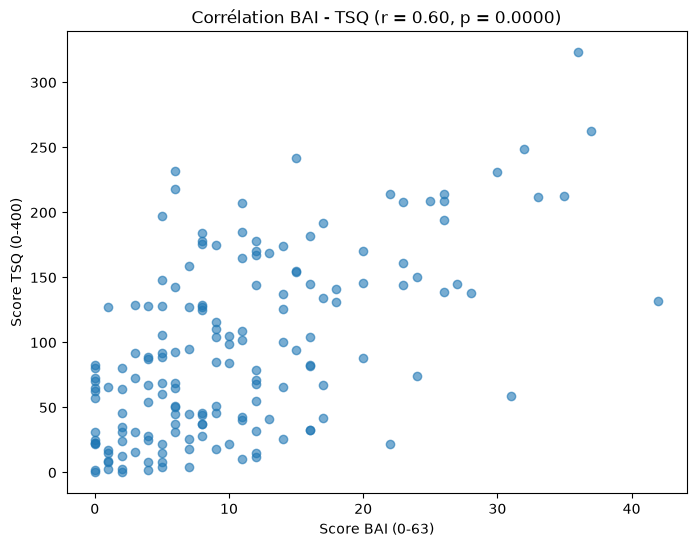

In [858]:
from scipy.stats import pearsonr

r, p_value = pearsonr(df_BAI["score_total"], df_TSQ["score_total"])
print(f"r = {r:.3f}, p = {p_value:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(df_BAI["score_total"], df_TSQ["score_total"], alpha=0.6)
plt.xlabel("Score BAI (0-63)")
plt.ylabel("Score TSQ (0-400)")
plt.title(f"Corrélation BAI - TSQ (r = {r:.2f}, p = {p_value:.4f})")
plt.show()

on voit que plus le score BAI est élevé plus la TSQ est élevé. Correl + significative

In [ ]:

print(len(df_SD_PS), len(df_TSQ))  


166 166


r = -0.446, p = 0.0000


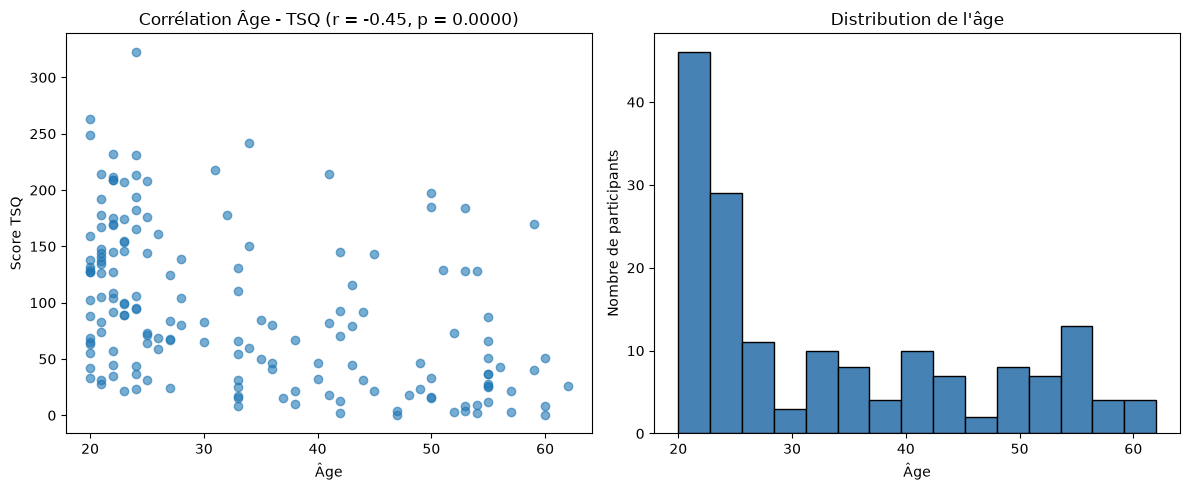

In [ ]:
r, p_value = pearsonr(df_SD_PS["age"], df_TSQ["score_total"])
print(f"r = {r:.3f}, p = {p_value:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_SD_PS["age"], df_TSQ["score_total"], alpha=0.6)
axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Score TSQ")
axes[0].set_title(f"Corrélation Âge - TSQ (r = {r:.2f}, p = {p_value:.4f})")

axes[1].hist(df_SD_PS["age"], bins=15, color="steelblue", edgecolor="black")
axes[1].set_xlabel("Âge")
axes[1].set_ylabel("Nombre de participants")
axes[1].set_title("Distribution de l'âge")

plt.tight_layout()
plt.show()

On voit qu'il y a une correl negative significative cad que plus les participants sont jeunes plus les scores TSQ sont élevés. Cependant la majorité des participants sont jeunes cela biaise donc les résultats

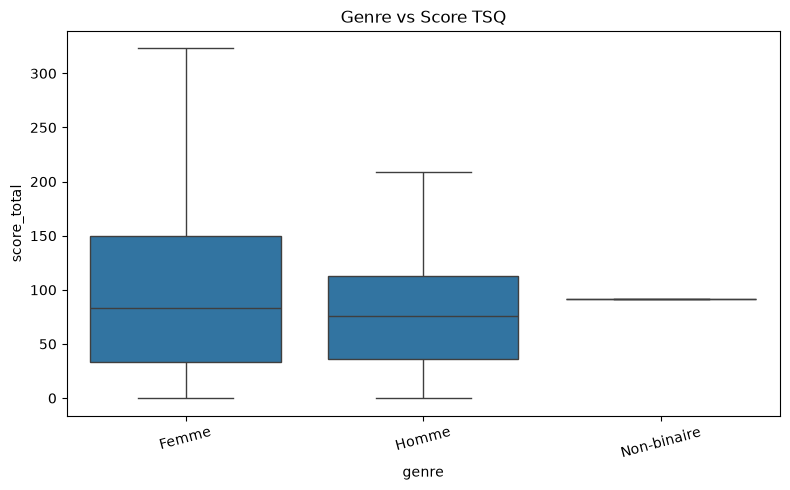

In [861]:
df_merged2 = pd.DataFrame({
    "genre": df_SD_PS["genre"].values,
    "age": df_SD_PS["age"].values,
    "score_total": df_TSQ["score_total"].values
})

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df_merged2, x="genre", y="score_total", ax=ax)
ax.set_title("Genre vs Score TSQ")
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [862]:
from scipy.stats import mannwhitneyu
groupe1 = df_merged2[df_merged2["genre"] == "Homme"]["score_total"]
groupe2 = df_merged2[df_merged2["genre"] == "Femme"]["score_total"]

stat, p_value = mannwhitneyu(groupe1, groupe2)
print(f"U = {stat:.3f}, p = {p_value:.4f}")

U = 2279.000, p = 0.4018


In [863]:
from scipy.stats import ttest_ind #suit une loi normale car p >0.05

groupe1 = df_merged2[df_merged2["genre"] == "Homme"]["score_total"]
groupe2 = df_merged2[df_merged2["genre"] == "Femme"]["score_total"]

stat, p_value = ttest_ind(groupe1, groupe2)
print(f"t = {stat:.3f}, p = {p_value:.4f}")

t = -1.258, p = 0.2102


pas de diff de genre selon TSQ 

                            OLS Regression Results                            
Dep. Variable:            score_total   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.194
Method:                 Least Squares   F-statistic:                     40.69
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           1.74e-09
Time:                        22:46:54   Log-Likelihood:                -918.84
No. Observations:                 166   AIC:                             1842.
Df Residuals:                     164   BIC:                             1848.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    172.6037     13.249     13.028      0.0

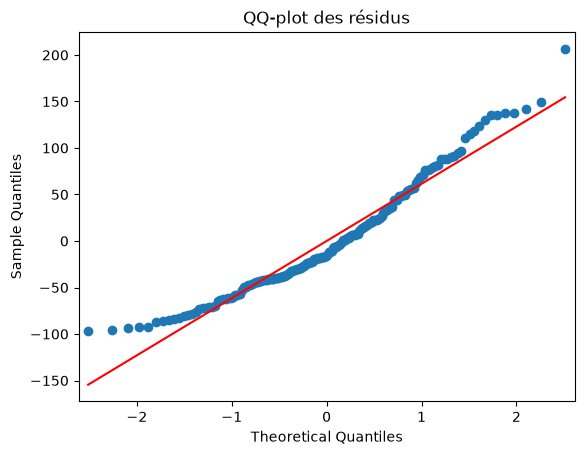

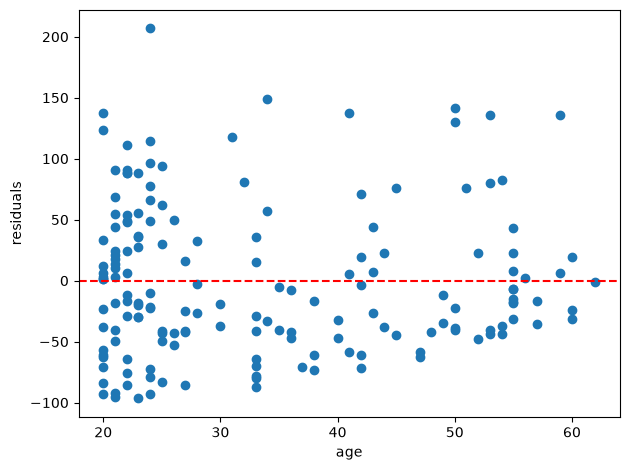

In [ ]:

import statsmodels.formula.api as smf

model = smf.ols("score_total ~ age ", data=df_merged2).fit()
print(model.summary())
import statsmodels.api as sm
resid = model.resid

sm.qqplot(resid, line='r')
plt.title('QQ-plot des résidus')
plt.show()# Distrib doit etre autour de 0
plt.scatter(df_merged2['age'], resid)
plt.xlabel('age')
plt.ylabel('residuals') 
plt.axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

# Correlation entre items core anxieux TSQ et BAI ? 

In [865]:
print(df_BAI.shape)
print(df.shape)

(166, 23)
(166, 41)


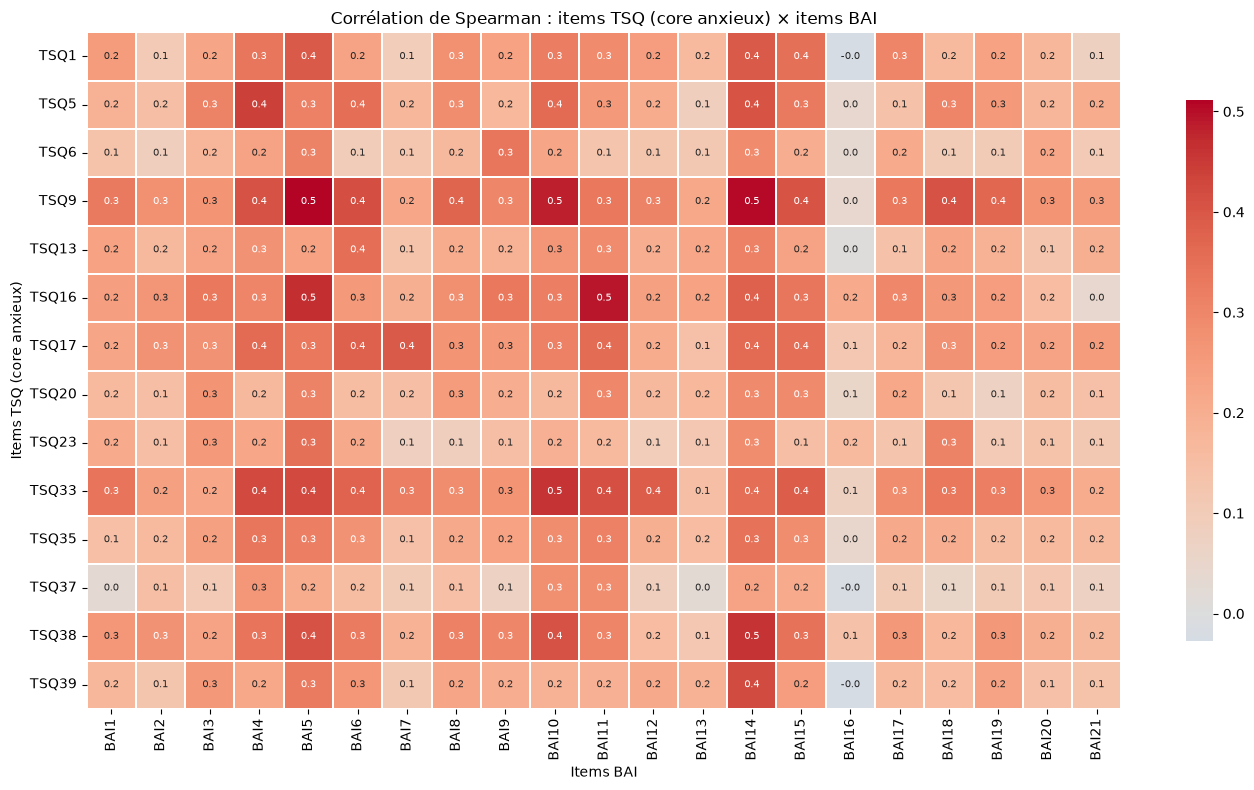

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

items_core_an = ['TSQ1','TSQ5','TSQ6','TSQ9','TSQ13','TSQ16','TSQ17','TSQ20',
                  'TSQ23','TSQ33','TSQ35','TSQ37','TSQ38','TSQ39']

cols_bai_brutes = df_BAI.columns[0:21]

df_BAI = df_BAI.rename(columns=dict(zip(cols_bai_brutes, [f"BAI{i}" for i in range(1, 22)])))
items_bai = [f"BAI{i}" for i in range(1, 22)]
df_BAI[items_bai] = df_BAI[items_bai].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

concat_items = pd.concat([df[items_core_an], df_BAI[items_bai]], axis=1)


corr_matrix_full = concat_items.corr(method='spearman')

corr_matrix = corr_matrix_full.loc[items_core_an, items_bai]

# heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", annot_kws={"size": 7}, cmap="coolwarm", center=0,
            square=False, linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Corrélation de Spearman : items TSQ (core anxieux) × items BAI")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

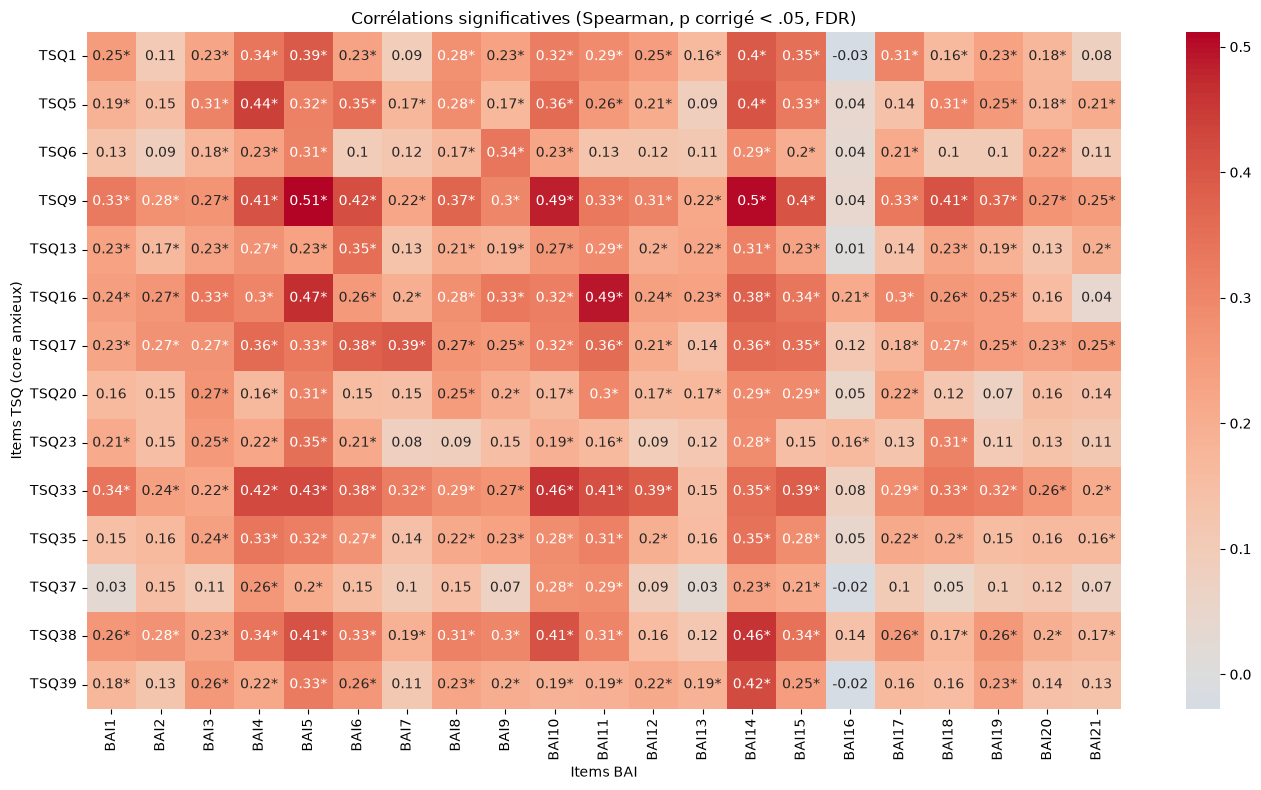

In [ ]:
from scipy.stats import spearmanr
import numpy as np
from statsmodels.stats.multitest import multipletests

corr_matrix = pd.DataFrame(index=items_core_an, columns=items_bai, dtype=float)
pval_matrix = pd.DataFrame(index=items_core_an, columns=items_bai, dtype=float)

for tsq_item in items_core_an:
    for bai_item in items_bai:
        # on retire les paires avec NaN
        paired = concat_items[[tsq_item, bai_item]].dropna()
        r, p = spearmanr(paired[tsq_item], paired[bai_item])
        corr_matrix.loc[tsq_item, bai_item] = r
        pval_matrix.loc[tsq_item, bai_item] = p


pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations significatives (Spearman, p corrigé < .05, FDR)")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

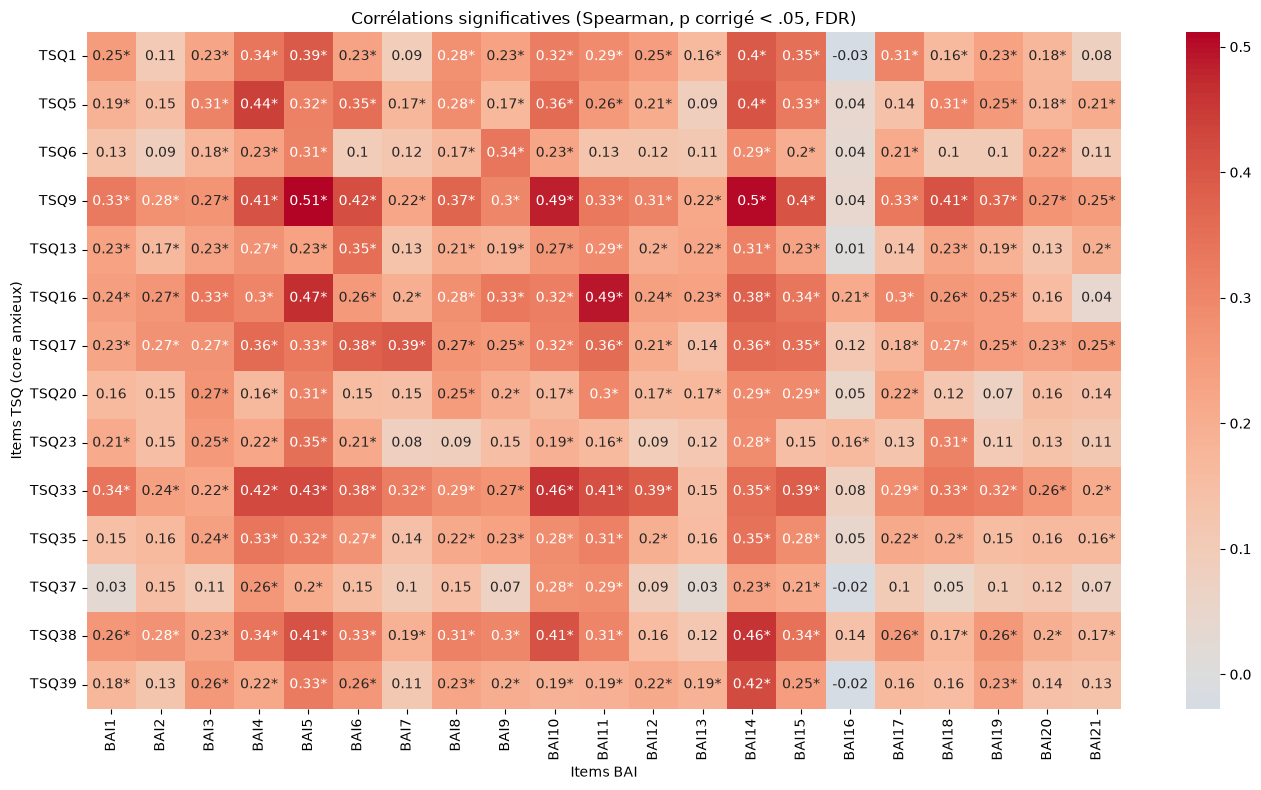

In [868]:
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations significatives (Spearman, p corrigé < .05, FDR)")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

rien au dessus de 0.5. 

Voir si different chez les personnes avec diag

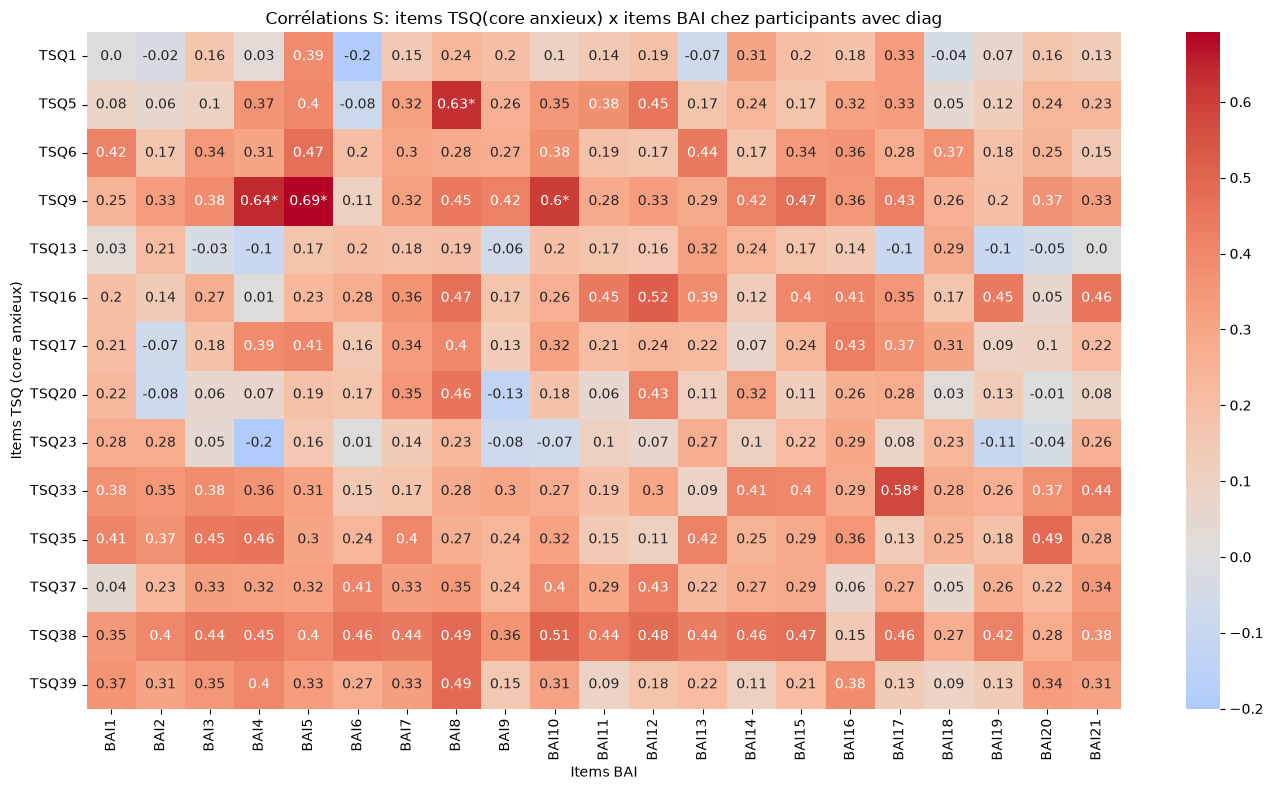

In [ ]:
cols_tsq_brutes = df_TSQ_PD.columns[0:40]
df1 = df_TSQ_PD.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df1[items] = df1[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

items_core_an = ['TSQ1','TSQ5','TSQ6','TSQ9','TSQ13','TSQ16','TSQ17','TSQ20',
                  'TSQ23','TSQ33','TSQ35','TSQ37','TSQ38','TSQ39']

cols_bai_PD= df_BAI_PD.columns[0:21]

df_BAI_PD = df_BAI_PD.rename(columns=dict(zip(cols_bai_PD, [f"BAI{i}" for i in range(1, 22)])))
items_bai = [f"BAI{i}" for i in range(1, 22)]
df_BAI_PD[items_bai] = df_BAI_PD[items_bai].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

concat_items = pd.concat([df1[items_core_an], df_BAI_PD[items_bai]], axis=1)

corr_matrix_full = concat_items.corr(method='spearman')

corr_matrix = corr_matrix_full.loc[items_core_an, items_bai]

corr_matrix = pd.DataFrame(index=items_core_an, columns=items_bai, dtype=float)
pval_matrix = pd.DataFrame(index=items_core_an, columns=items_bai, dtype=float)

for i in items_core_an:
    for u in items_bai:
        
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations S: items TSQ(core anxieux) x items BAI chez participants avec diag")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

strong_corr = corr_matrix.stack().reset_index()
strong_corr.columns = ['item_TSQ', 'item_BAI', 'correlation']

strong_corr = strong_corr[strong_corr['correlation'] > 0.6].sort_values('correlation', ascending=False)

print(strong_corr)

   item_TSQ item_BAI  correlation
67     TSQ9     BAI5     0.691685
66     TSQ9     BAI4     0.641413
28     TSQ5     BAI8     0.629847
72     TSQ9    BAI10     0.602831


In [871]:
print(df.index[:10], df_BAI.index[:10])
print(df.index.equals(df_BAI.index))
print(len(df), len(df_BAI))

Index([1, 3, 5, 9, 10, 12, 16, 17, 18, 19], dtype='int64') Index([1, 3, 5, 9, 10, 12, 16, 17, 18, 19], dtype='int64')
True
166 166


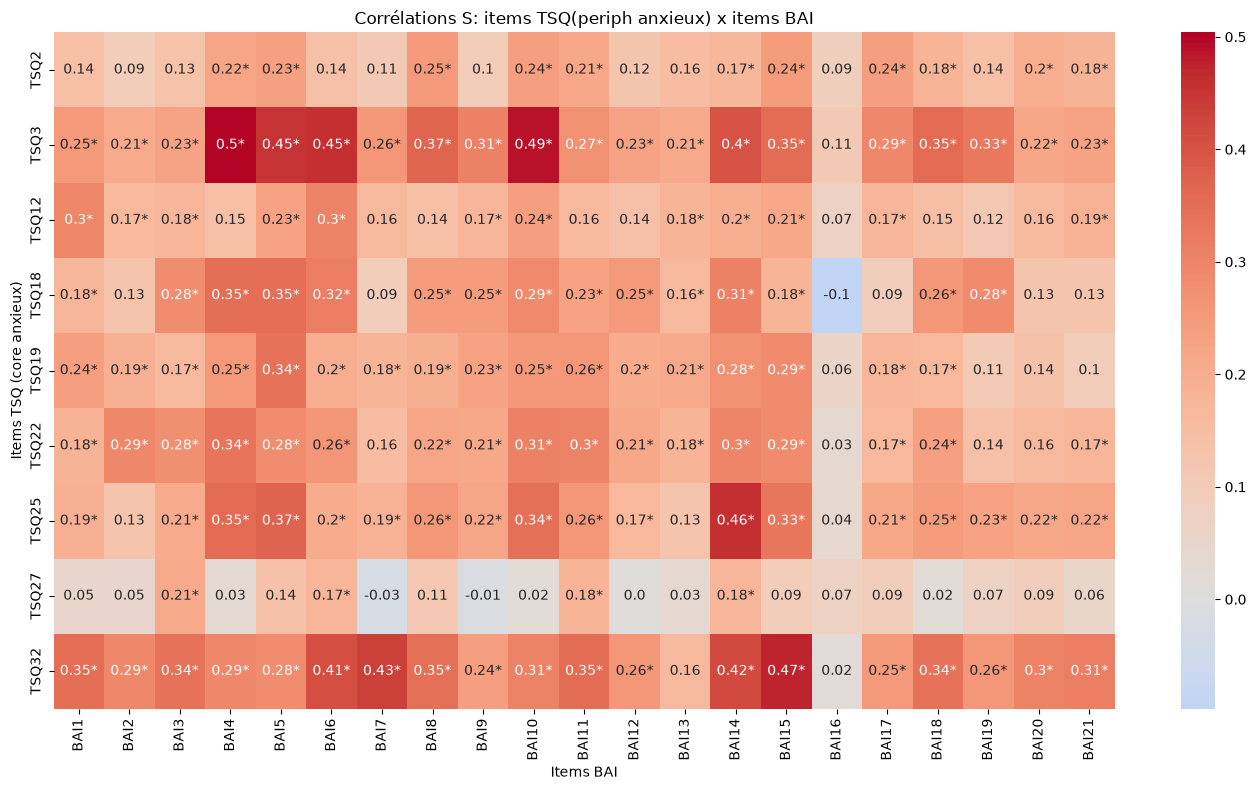

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

items_periph_an = ['TSQ2','TSQ3','TSQ12','TSQ18','TSQ19','TSQ22','TSQ25','TSQ27',
                  'TSQ32']

cols_bai_brutes = df_BAI.columns[0:21]

df_BAI = df_BAI.rename(columns=dict(zip(cols_bai_brutes, [f"BAI{i}" for i in range(1, 22)])))
items_bai = [f"BAI{i}" for i in range(1, 22)]
df_BAI[items_bai] = df_BAI[items_bai].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

concat_items = pd.concat([df[items_periph_an], df_BAI[items_bai]], axis=1)

corr_matrix_full = concat_items.corr(method='spearman')

corr_matrix = corr_matrix_full.loc[items_periph_an, items_bai]

corr_matrix = pd.DataFrame(index=items_periph_an, columns=items_bai, dtype=float)
pval_matrix = pd.DataFrame(index=items_periph_an, columns=items_bai, dtype=float)

for i in items_periph_an:
    for u in items_bai:
        
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p


pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations S: items TSQ(periph anxieux) x items BAI")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

il n'y a pas de fortes correl

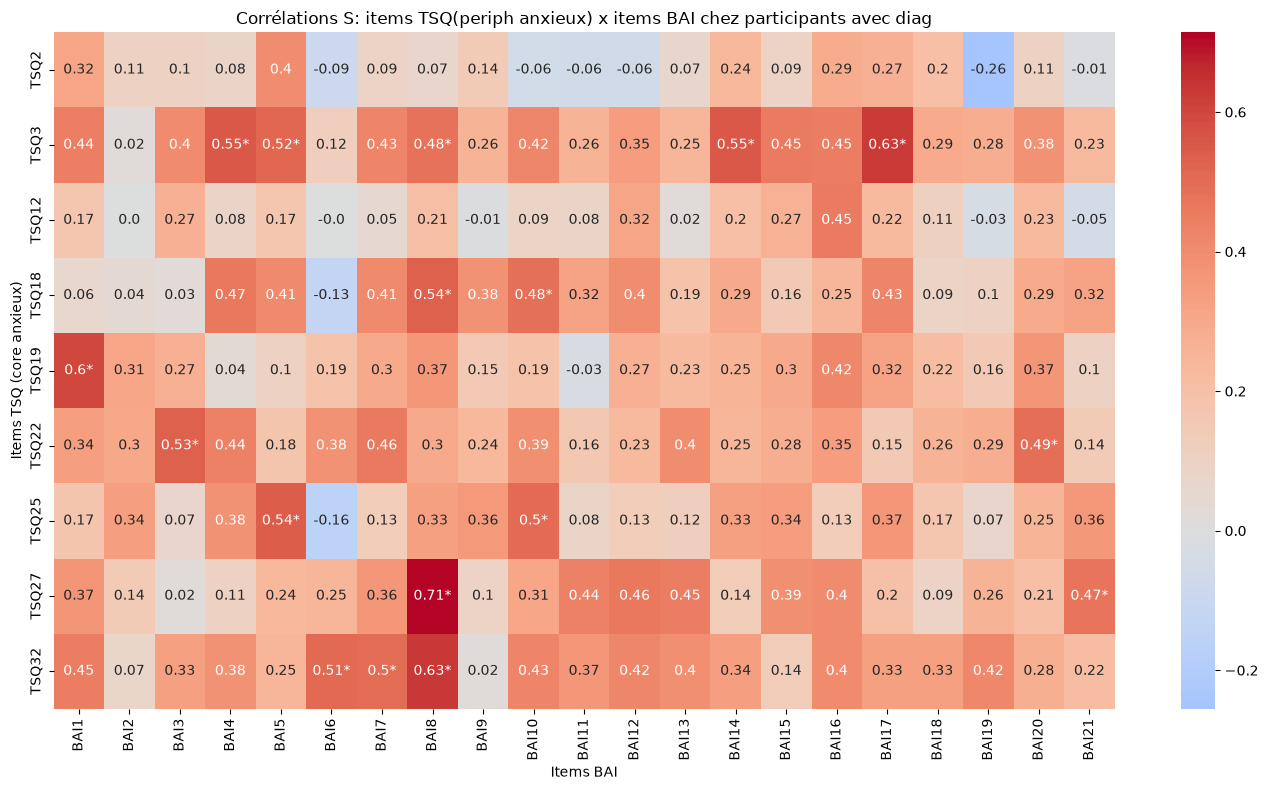

In [ ]:

items_periph_an = ['TSQ2','TSQ3','TSQ12','TSQ18','TSQ19','TSQ22','TSQ25','TSQ27',
                  'TSQ32']

cols_tsq_brutes = df_TSQ_PD.columns[0:40]
df1 = df_TSQ_PD.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df1[items] = df1[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

cols_bai_PD= df_BAI_PD.columns[0:21]

df_BAI_PD = df_BAI_PD.rename(columns=dict(zip(cols_bai_PD, [f"BAI{i}" for i in range(1, 22)])))
items_bai = [f"BAI{i}" for i in range(1, 22)]
df_BAI_PD[items_bai] = df_BAI_PD[items_bai].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

concat_items = pd.concat([df1[items_periph_an], df_BAI_PD[items_bai]], axis=1)

corr_matrix_full = concat_items.corr(method='spearman')

corr_matrix = corr_matrix_full.loc[items_periph_an, items_bai]

corr_matrix = pd.DataFrame(index=items_periph_an, columns=items_bai, dtype=float)
pval_matrix = pd.DataFrame(index=items_periph_an, columns=items_bai, dtype=float)

for i in items_periph_an:
    for u in items_bai:
        
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations S: items TSQ(periph anxieux) x items BAI chez participants avec diag")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()



In [ ]:
strong_corr = corr_matrix.stack().reset_index()
strong_corr.columns = ['item_TSQ', 'item_BAI', 'correlation']

strong_corr = strong_corr[strong_corr['correlation'] > 0.6].sort_values('correlation', ascending=False)

print(strong_corr)

    item_TSQ item_BAI  correlation
154    TSQ27     BAI8     0.714196
175    TSQ32     BAI8     0.633631
37      TSQ3    BAI17     0.625483


# Extraction df echelle positivité

In [875]:
cols_EP_PD = df_PD.columns[87:94]  # 7 items à coter de 1 à 5
print(cols_EP_PD)
df_EP_PD = df_PD[cols_EP_PD]

Index(['[1- J'ai une grande confiance en l'avenir]',
       '[2- Je suis satisfait(e) de ma vie]',
       '[3- Je regarde l'avenir avec espoir et enthousiasme]',
       '[4- Dans l’ensemble, je suis satisfait(e) de moi]',
       '[5- Par moment, l’avenir me semble incertain]',
       '[6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier]',
       '[7- En général, j’ai confiance en moi]'],
      dtype='str')


In [876]:

cols_EP = df_PS.columns[87:94]  # 7 items à coter de 1 à 5
print(cols_EP)

Index(['[1- J'ai une grande confiance en l'avenir]',
       '[2- Je suis satisfait(e) de ma vie]',
       '[3- Je regarde l'avenir avec espoir et enthousiasme]',
       '[4- Dans l’ensemble, je suis satisfait(e) de moi]',
       '[5- Par moment, l’avenir me semble incertain]',
       '[6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier]',
       '[7- En général, j’ai confiance en moi]'],
      dtype='str')


In [877]:

df_EP = df_PS[cols_EP]

In [878]:

df_EP.describe()

,[1- J'ai une grande confiance en l'avenir],[2- Je suis satisfait(e) de ma vie],[3- Je regarde l'avenir avec espoir et enthousiasme],"[4- Dans l’ensemble, je suis satisfait(e) de moi]","[5- Par moment, l’avenir me semble incertain]",[6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier],"[7- En général, j’ai confiance en moi]"
count,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,2.873494,3.620482,3.289157,3.451807,3.897590,3.433735,2.969880
std,0.954553,0.937729,1.139166,1.018360,1.065318,1.086476,1.223134
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000
50%,3.000000,4.000000,3.000000,4.000000,4.000000,4.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [ ]:

lignes_vides = df_EP.isnull().all(axis=1).sum()
print(f"Nombre de lignes complètement vides : {lignes_vides}")

Nombre de lignes complètement vides : 0


In [880]:

percent_missing = (df_EP.isnull().sum() / len(df_EP) * 100).sort_values(ascending=False)
print(percent_missing)

[1- J'ai une grande confiance en l'avenir]                                  0.0
[2- Je suis satisfait(e) de ma vie]                                         0.0
[3- Je regarde l'avenir avec espoir et enthousiasme]                        0.0
[4- Dans l’ensemble, je suis satisfait(e) de moi]                           0.0
[5- Par moment, l’avenir me semble incertain]                               0.0
[6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier]    0.0
[7- En général, j’ai confiance en moi]                                      0.0
dtype: float64


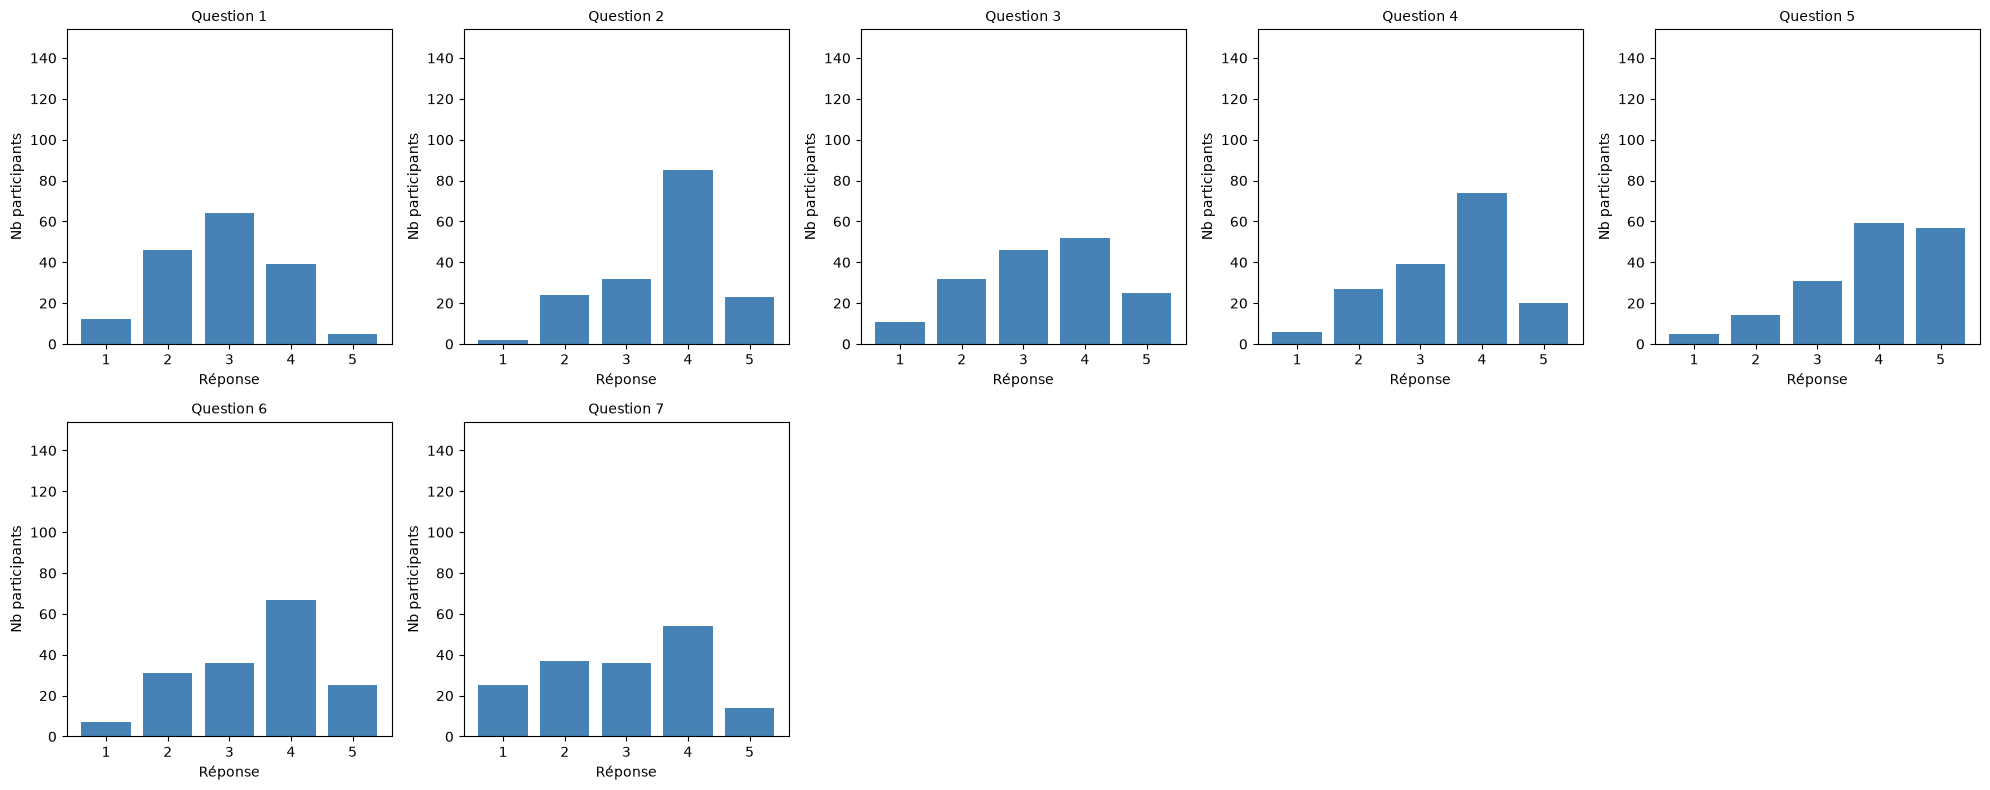

Question : [1- J'ai une grande confiance en l'avenir]
[1- J'ai une grande confiance en l'avenir]
3.0    64
2.0    46
4.0    39
1.0    12
5.0     5
Name: count, dtype: int64


Question : [2- Je suis satisfait(e) de ma vie]
[2- Je suis satisfait(e) de ma vie]
4.0    85
3.0    32
2.0    24
5.0    23
1.0     2
Name: count, dtype: int64


Question : [3- Je regarde l'avenir avec espoir et enthousiasme]
[3- Je regarde l'avenir avec espoir et enthousiasme]
4.0    52
3.0    46
2.0    32
5.0    25
1.0    11
Name: count, dtype: int64


Question : [4- Dans l’ensemble, je suis satisfait(e) de moi]
[4- Dans l’ensemble, je suis satisfait(e) de moi]
4.0    74
3.0    39
2.0    27
5.0    20
1.0     6
Name: count, dtype: int64


Question : [5- Par moment, l’avenir me semble incertain]
[5- Par moment, l’avenir me semble incertain]
4.0    59
5.0    57
3.0    31
2.0    14
1.0     5
Name: count, dtype: int64


Question : [6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier]
[6- J'ai le sen

In [881]:

# rien n'est vide, on peut donc continuer avec le traitement 

items = df_EP.columns.tolist()
df_EP[items] = df_EP[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(1, 6))  

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_EP[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 154)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
for i in items:
    print(f"Question : {i}")
    print(df_EP[i].value_counts())
    print("\n")

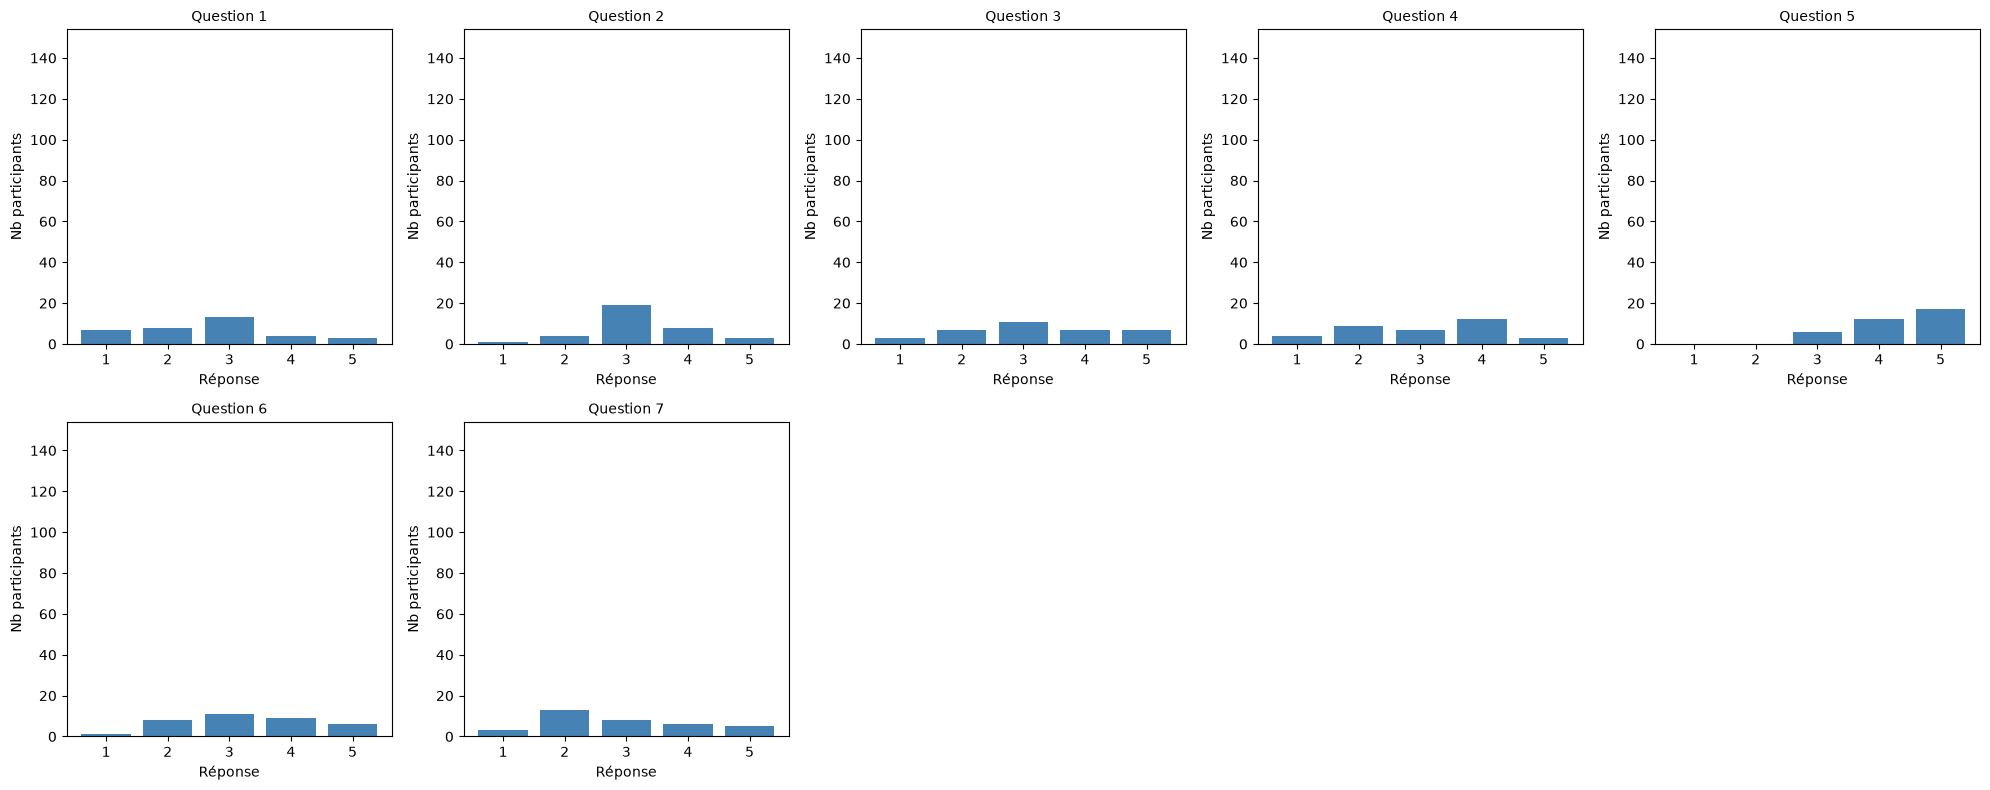

Question : [1- J'ai une grande confiance en l'avenir]
[1- J'ai une grande confiance en l'avenir]
3.0    13
2.0     8
1.0     7
4.0     4
5.0     3
Name: count, dtype: int64


Question : [2- Je suis satisfait(e) de ma vie]
[2- Je suis satisfait(e) de ma vie]
3.0    19
4.0     8
2.0     4
5.0     3
1.0     1
Name: count, dtype: int64


Question : [3- Je regarde l'avenir avec espoir et enthousiasme]
[3- Je regarde l'avenir avec espoir et enthousiasme]
3.0    11
5.0     7
4.0     7
2.0     7
1.0     3
Name: count, dtype: int64


Question : [4- Dans l’ensemble, je suis satisfait(e) de moi]
[4- Dans l’ensemble, je suis satisfait(e) de moi]
4.0    12
2.0     9
3.0     7
1.0     4
5.0     3
Name: count, dtype: int64


Question : [5- Par moment, l’avenir me semble incertain]
[5- Par moment, l’avenir me semble incertain]
5.0    17
4.0    12
3.0     6
Name: count, dtype: int64


Question : [6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier]
[6- J'ai le sentiment d'avoir beauc

In [ ]:

items = df_EP_PD.columns.tolist()
df_EP_PD[items] = df_EP_PD[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(1, 6))  

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_EP_PD[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 154)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
for i in items:
    print(f"Question : {i}")
    print(df_EP_PD[i].value_counts())
    print("\n")

In [883]:
df_EP_PD.describe()

,[1- J'ai une grande confiance en l'avenir],[2- Je suis satisfait(e) de ma vie],[3- Je regarde l'avenir avec espoir et enthousiasme],"[4- Dans l’ensemble, je suis satisfait(e) de moi]","[5- Par moment, l’avenir me semble incertain]",[6- J'ai le sentiment d'avoir beaucoup de choses dont je peux être fier],"[7- En général, j’ai confiance en moi]"
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,2.657143,3.228571,3.228571,3.028571,4.314286,3.314286,2.914286
std,1.186762,0.877353,1.238731,1.200140,0.758149,1.105373,1.221653
min,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000
25%,2.000000,3.000000,2.000000,2.000000,4.000000,2.500000,2.000000
50%,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000
75%,3.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [884]:
df_EP['score_total'] = df_EP.sum(axis=1)
df_EP_PD['score_total'] = df_EP_PD.sum(axis=1)

In [885]:
print(df_EP_PD['score_total'])

2      33.0
4      23.0
11     27.0
13     25.0
20     26.0
28     19.0
41     20.0
79     26.0
98     24.0
113    20.0
139    18.0
140    17.0
149    17.0
153    22.0
176    28.0
178    19.0
182    19.0
195    32.0
209    22.0
242    23.0
247    28.0
251    20.0
257    23.0
265    18.0
266    16.0
272    20.0
287    19.0
290    25.0
296    27.0
300    32.0
310    17.0
342    25.0
354    29.0
358    15.0
360    20.0
Name: score_total, dtype: float64


# Extraction df fPQ-16

In [886]:
cols_16 = df_PS.columns[94:126]  # 16 items (dichotomique : échelle 1: vrai ou faux et échelle 2 si vrai à quel point ou alors faux --> non concerné
cols_16_PD = df_PD.columns[94:126]
print(cols_16)

Index(['[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 1]',
       '[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]',
       '[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 1]',
       '[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]',
       '[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 1]',
       '[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]',
       '[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 1]',
       '[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 2

In [887]:
df_16 = df_PS[cols_16]
df_16_PD = df_PD[cols_16_PD]

In [888]:
df_16.describe()
df_16_PD.describe()

,[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 1],[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2],[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 1],[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2],[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 1],[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2],"[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 1]","[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 2]",[5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.][Échelle 1],[5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.][Échelle 2],...,[12- Parfois je me sens soudainement distrait par des sons éloignés dont je ne suis habituellement pas conscient.][Échelle 1],[12- Parfois je me sens soudainement distrait par des sons éloignés dont je ne suis habituellement pas conscient.][Échelle 2],[13- J'ai entendu des choses que les autres ne peuvent pas entendre comme des voix de personnes qui chuchotent où qui parlent.][Échelle 1],[13- J'ai entendu des choses que les autres ne peuvent pas entendre comme des voix de personnes qui chuchotent où qui parlent.][Échelle 2],[14- J'ai souvent l'impression que les autres sont contre moi.][Échelle 1],[14- J'ai souvent l'impression que les autres sont contre moi.][Échelle 2],[15- J'ai eu le sentiment que des personnes ou des forces m'entourent bien que je ne puisse voir personne.][Échelle 1],[15- J'ai eu le sentiment que des personnes ou des forces m'entourent bien que je ne puisse voir personne.][Échelle 2],[16- J'ai l'impression que des parties de mon corps ont changé d'une certaine manière ou que certaines parties de mon corps fonctionnent différemment d'avant.][Échelle 1],[16- J'ai l'impression que des parties de mon corps ont changé d'une certaine manière ou que certaines parties de mon corps fonctionnent différemment d'avant.][Échelle 2]
count,35,35,35,35,35,35,35,35,35,35,...,35,35,35,35,35,35,35,35,35,35
unique,2,5,2,5,2,5,2,5,2,5,...,2,5,2,5,2,4,2,5,2,5
top,FAUX,Non concerné(e),VRAI,Non concerné(e),VRAI,Non concerné(e),FAUX,Non concerné(e),VRAI,Non concerné(e),...,FAUX,Non concerné(e),FAUX,Non concerné(e),FAUX,Non concerné(e),FAUX,Non concerné(e),FAUX,Non concerné(e)
freq,24,22,20,14,19,15,20,17,18,15,...,22,21,31,28,23,21,31,28,28,28


# Score de symptomes positifs (0-16)

In [889]:
# Séparer les colonnes "vrai/faux" (échelle 1) et "intensité" (échelle 2)
echelle1 = cols_16[0::2]  # une colonne sur deux, en partant de la 1ère
echelle2 = cols_16[1::2]  # une colonne sur deux, en partant de la 2ème

print("Échelle 1 (vrai/faux) :", list(echelle1))
print("Échelle 2 (intensité) :", list(echelle2))

Échelle 1 (vrai/faux) : ["[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 1]", "[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 1]", '[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 1]', "[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 1]", '[5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.][Échelle 1]', "[6- Quand je regarde quelqu'un ou que je me regarde dans le miroir j'ai vu ce visage se modifier juste sous mes yeux.][Échelle 1]", '[7- Je me sens très anxieux quand je rencontre des gens pour la première fois.][Échelle 1]', "[8- J'ai déjà vu des choses qu'apparemment d'autres personnes ne peuvent pas voir.][Échelle 1]", '[9- Mes pensées sont parfois tellement fortes que je peux pres

In [1017]:
df_16["nb_vrai"] = (df_16[echelle1] == "VRAI").sum(axis=1)
df_16_PD["nb_vrai"] = (df_16_PD[echelle1] == "VRAI").sum(axis=1)
print(df_16_PD["nb_vrai"].describe())

count    35.000000
mean      5.828571
std       2.884907
min       0.000000
25%       4.000000
50%       6.000000
75%       8.000000
max      10.000000
Name: nb_vrai, dtype: float64


au maximum on a 14/16 vrai 

In [891]:
print(df_16["nb_vrai"].value_counts().sort_index())

nb_vrai
0     18
1      9
2     25
3     23
4     19
5     13
6     14
7     19
8      8
9      5
10     5
11     4
12     2
13     1
14     1
Name: count, dtype: int64


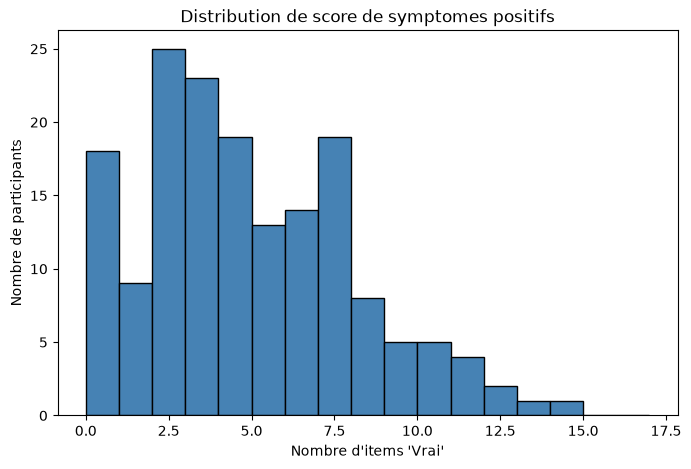

In [892]:
plt.figure(figsize=(8, 5))
plt.hist(df_16["nb_vrai"], bins=range(0, 18), color="steelblue", edgecolor="black")
plt.xlabel("Nombre d'items 'Vrai'")
plt.ylabel("Nombre de participants")
plt.title("Distribution de score de symptomes positifs")
plt.show()

In [893]:
groupe_score_sup_9 = df_16[df_16["nb_vrai"] > 9]

print(len(groupe_score_sup_9))

13


11 paritcipants ont un score au dessus du seuil (9)

In [894]:
print(groupe_score_sup_9["nb_vrai"].describe())



count    13.000000
mean     11.153846
std       1.281025
min      10.000000
25%      10.000000
50%      11.000000
75%      12.000000
max      14.000000
Name: nb_vrai, dtype: float64


In [895]:
# vérification du nombre de valeurs numériques valides par colonne, pour ce groupe uniquement
df_16_num_groupe = groupe_score_sup_9[echelle2].apply(pd.to_numeric, errors="coerce")
print(df_16_num_groupe.notna().sum())
# score total (échelle2) pour ce groupe
groupe_score_sup_9["score_total"] = df_16_num_groupe.sum(axis=1, skipna=True)
print(groupe_score_sup_9["score_total"].value_counts().sort_index())

[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]                                                                                                 8
[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]                                                            9
[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]                                                                                            8
[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 2]                                 9
[5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.][Échelle 2]                                                                           11
[6- Quand je regarde quelqu'un ou que je me regarde dans le miroi

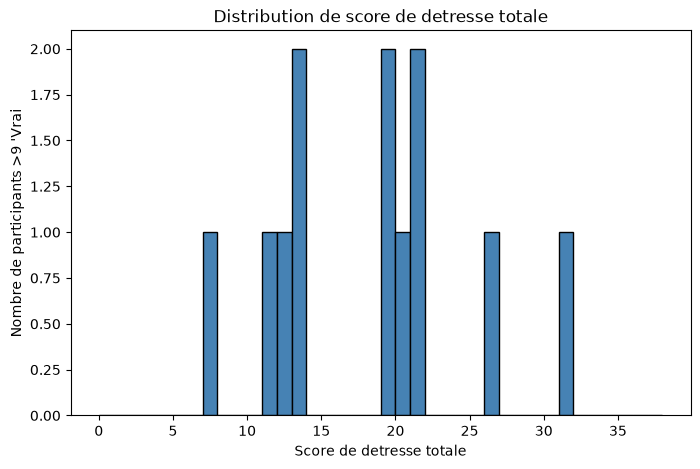

In [896]:

plt.figure(figsize=(8, 5))
plt.hist(groupe_score_sup_9["score_total"], bins=range(0, 39), color="steelblue", edgecolor="black")
plt.xlabel("Score de detresse totale")
plt.ylabel("Nombre de participants >9 'Vrai")
plt.title("Distribution de score de detresse totale")
plt.show()

In [897]:
items = list(echelle2)  # uniquement les 16 colonnes d'intensité, pas les 32
df_16[items] = df_16[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

for i in items:
    print(f"Question : {i}")
    print(groupe_score_sup_9[i].value_counts())
    print("\n")

Question : [1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]
[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]
Non concerné(e)    5
1                  4
2                  3
3                  1
Name: count, dtype: int64


Question : [2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]
[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]
1                  4
Non concerné(e)    4
2                  4
3                  1
Name: count, dtype: int64


Question : [3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]
[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]
Non concerné(e)    5
2                  3
3                  2
1                  2
0                  1
Name: count, dtype: 

# Score DE DETRESSE tot= intensité des symptomes uniquement chez les personnes qui ont repondu vrai

In [898]:
# Convertir chaque valeur en numérique ; le texte non convertible = non concerné devient NaN

df_16_num = df_16[echelle2].apply(pd.to_numeric, errors="coerce")
df_16_PD_num = df_16_PD[echelle2].apply(pd.to_numeric, errors="coerce")

# Vérification : combien de valeurs numériques valides as-tu gardées par colonne ?
print(df_16_num.notna().sum())

[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]                                                                                                47
[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]                                                           75
[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]                                                                                           75
[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 2]                                57
[5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.][Échelle 2]                                                                           49
[6- Quand je regarde quelqu'un ou que je me regarde dans le miroi

In [899]:
# Score total : la somme ignore automatiquement les NaN
df_16["score_total"] = df_16_num.sum(axis=1, skipna=True)
df_16_PD["score_total"] = df_16_PD_num.sum(axis=1, skipna=True)
print(df_16["score_total"].describe())

count    166.000000
mean       6.114458
std        6.242001
min        0.000000
25%        2.000000
50%        4.500000
75%        9.000000
max       39.000000
Name: score_total, dtype: float64


In [900]:
print(df_16["score_total"].value_counts().sort_index())

score_total
0.0     25
1.0     14
2.0     23
3.0     14
4.0      7
5.0      6
6.0     14
7.0     11
8.0      6
9.0      7
10.0     8
11.0     4
12.0     4
13.0     7
14.0     3
15.0     1
16.0     3
19.0     3
20.0     1
21.0     2
26.0     1
31.0     1
39.0     1
Name: count, dtype: int64


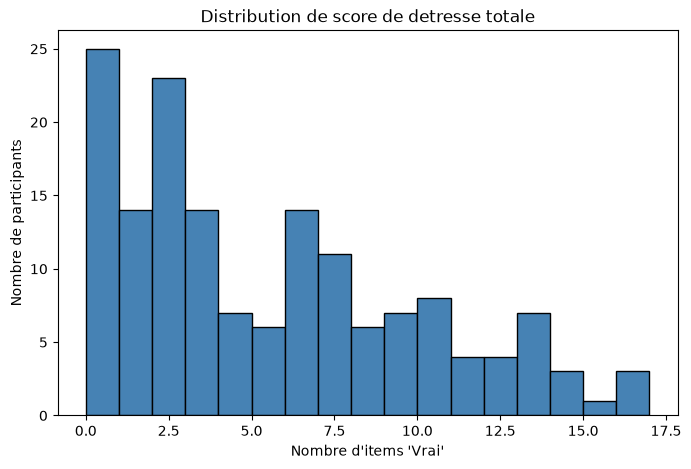

In [901]:

plt.figure(figsize=(8, 5))
plt.hist(df_16["score_total"], bins=range(0, 18), color="steelblue", edgecolor="black")
plt.xlabel("Nombre d'items 'Vrai'")
plt.ylabel("Nombre de participants")
plt.title("Distribution de score de detresse totale")
plt.show()


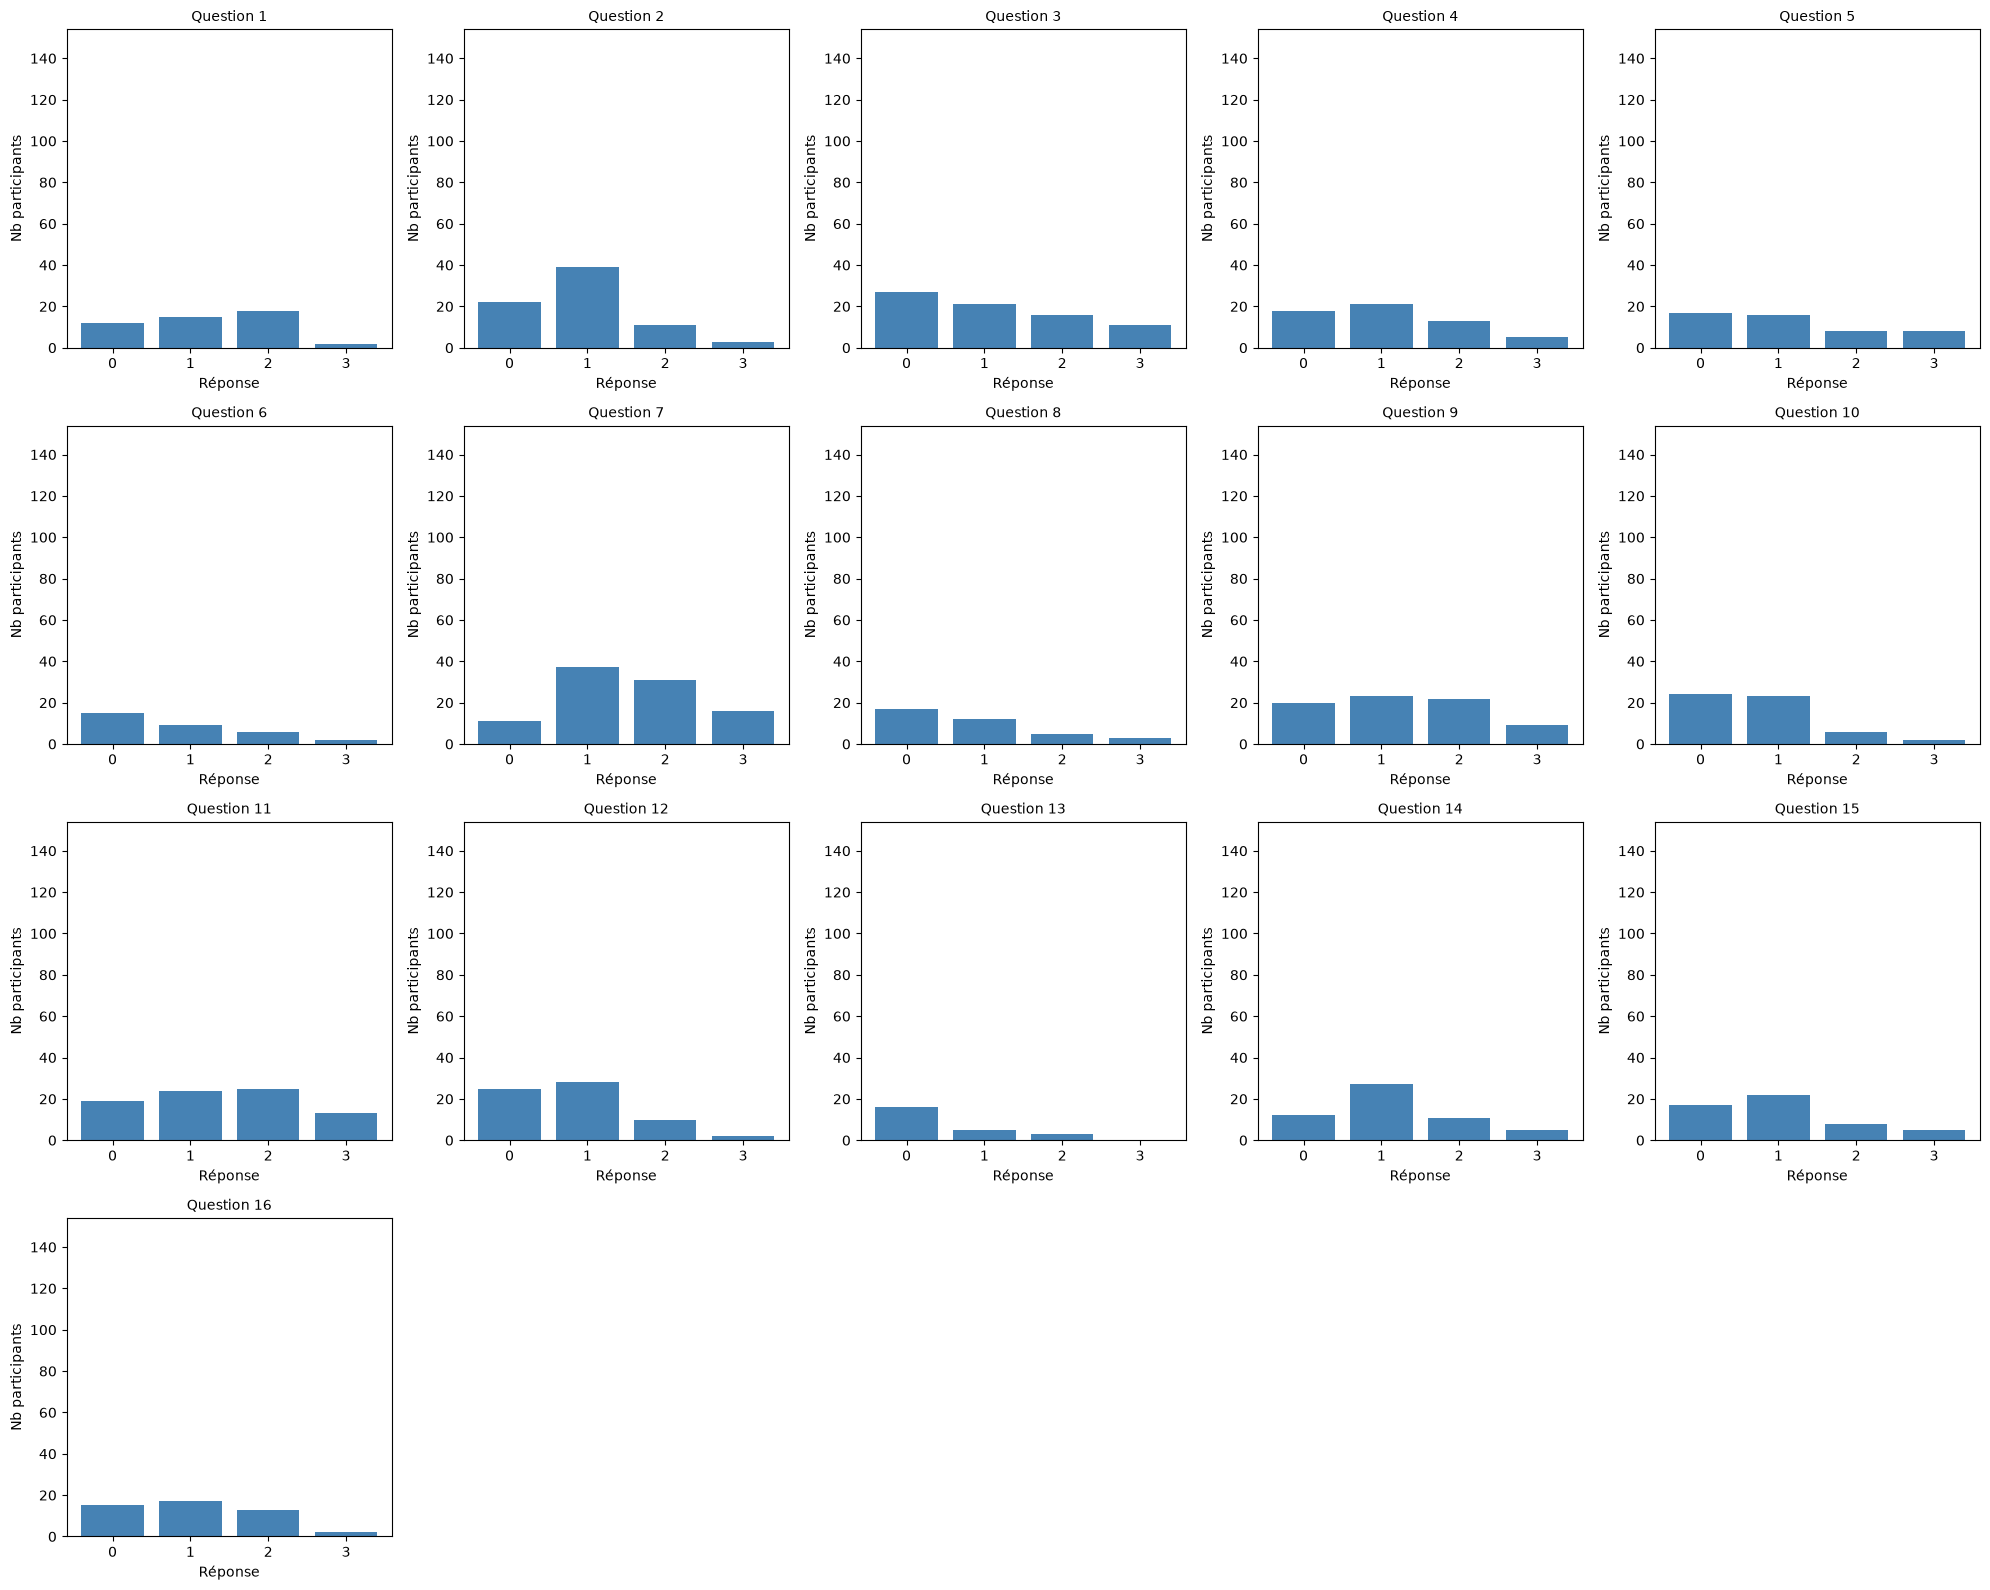

Question : [1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]
[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 2]
2.0    18
1.0    15
0.0    12
3.0     2
Name: count, dtype: int64


Question : [2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]
[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 2]
1.0    39
0.0    22
2.0    11
3.0     3
Name: count, dtype: int64


Question : [3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]
[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 2]
0.0    27
1.0    21
2.0    16
3.0    11
Name: count, dtype: int64


Question : [4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes ore

In [ ]:
items = list(echelle2)  # uniquement les 16 colonnes d'intensité, pas les 32
df_16[items] = df_16[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(0, 4))  
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_16[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 154)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

for i in items:
    print(f"Question : {i}")
    print(df_16[i].value_counts())
    print("\n")

# correlation score TSQ core sz et BAI

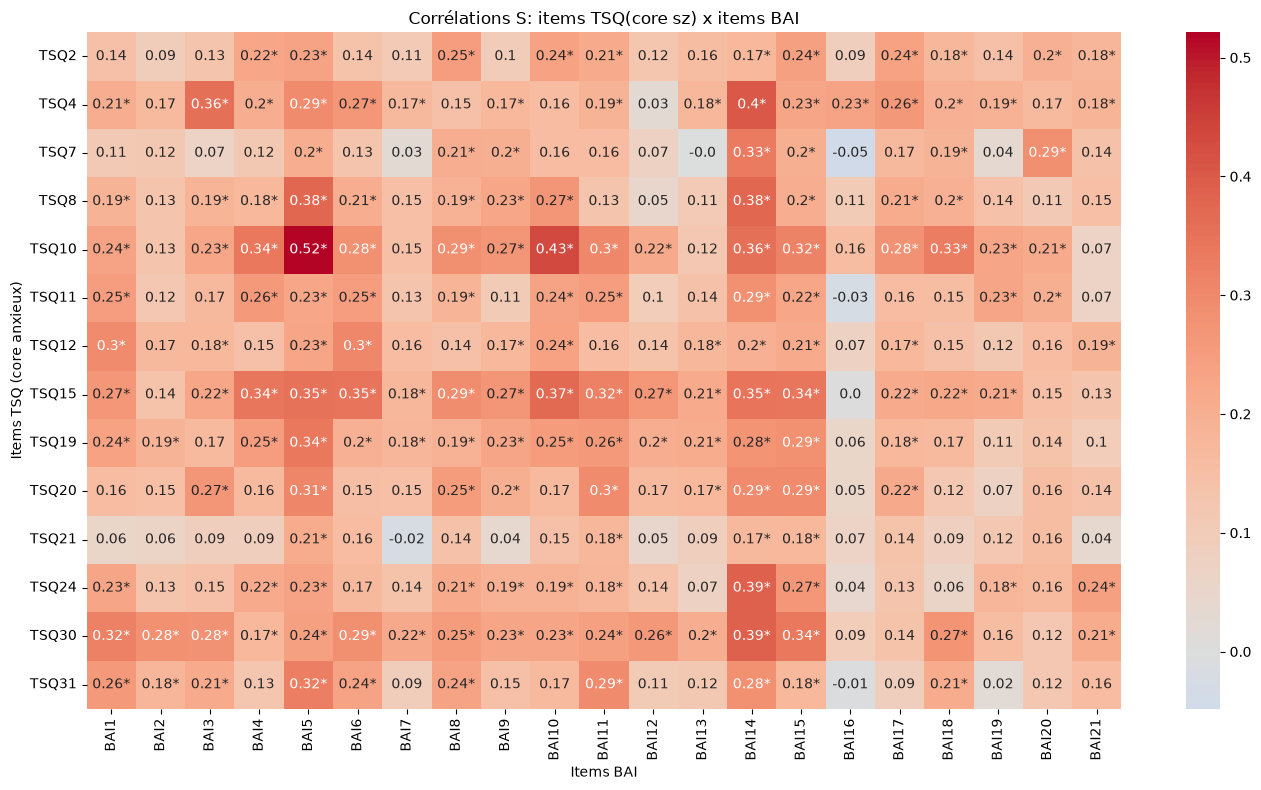

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

items_core_sz = ['TSQ2','TSQ4','TSQ7','TSQ8','TSQ10','TSQ11','TSQ12','TSQ15',
                  'TSQ19','TSQ20','TSQ21','TSQ24','TSQ30','TSQ31']

cols_bai_brutes = df_BAI.columns[0:21]

df_BAI = df_BAI.rename(columns=dict(zip(cols_bai_brutes, [f"BAI{i}" for i in range(1, 22)])))
items_bai = [f"BAI{i}" for i in range(1, 22)]
df_BAI[items_bai] = df_BAI[items_bai].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))


concat_items = pd.concat([df[items_core_sz], df_BAI[items_bai]], axis=1)

corr_matrix_full = concat_items.corr(method='spearman')

corr_matrix = corr_matrix_full.loc[items_core_sz, items_bai]

corr_matrix = pd.DataFrame(index=items_core_sz, columns=items_bai, dtype=float)
pval_matrix = pd.DataFrame(index=items_core_sz, columns=items_bai, dtype=float)

for i in items_core_sz:
    for u in items_bai:
        
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations S: items TSQ(core sz) x items BAI")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

In [ ]:

strong_corr = corr_matrix.stack().reset_index()
strong_corr.columns = ['item_TSQ', 'item_BAI', 'correlation']

strong_corr = strong_corr[strong_corr['correlation'] > 0.6].sort_values('correlation', ascending=False)

print(strong_corr)

Empty DataFrame
Columns: [item_TSQ, item_BAI, correlation]
Index: []


# participants avec des scores élevés à la BAI ont un profil TSQ type « Anxieux"??

# correlation pour TSQ total - echelle de positivité ?

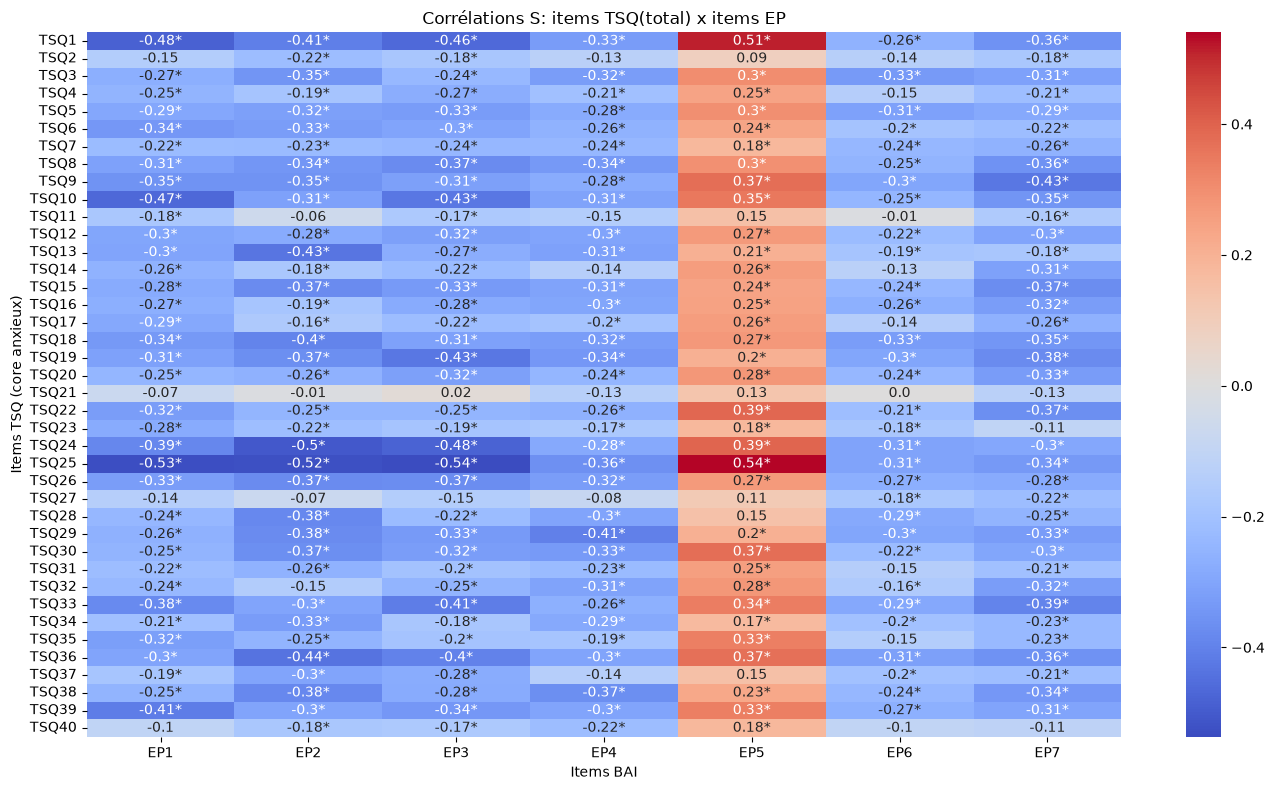

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols_tsq_brutes = df_TSQ.columns[0:40]
df = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df[items] = df[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))


items = [f"TSQ{i}" for i in range(1, 41)]


cols_ep_brutes = df_EP.columns[0:7]

df_EP = df_EP.rename(columns=dict(zip(cols_ep_brutes, [f"EP{i}" for i in range(1, 8)])))
items_ep = [f"EP{i}" for i in range(1, 8)]
df_EP[items_ep] = df_EP[items_ep].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))


concat_items = pd.concat([df[items], df_EP[items_ep]], axis=1)

corr_matrix_full = concat_items.corr(method='spearman')

corr_matrix = corr_matrix_full.loc[items, items_ep]

corr_matrix = pd.DataFrame(index=items, columns=items_ep, dtype=float)
pval_matrix = pd.DataFrame(index=items, columns=items_ep, dtype=float)

for i in items:
    for u in items_ep:
        
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05
plt.figure(figsize=(14, 8))


annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations S: items TSQ(total) x items EP")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()



TSQ1 (core ax) =  Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas 
avoir de vision claire dessus. 
TSQ 25 (core MDD, periph ax)= L’avenir s’annonce plutôt difficile ces derniers temps. C'est comme si je me noyais dans 
les inquiétudes et les peurs, ou parfois j'ai simplement l'impression que le futur n'existe pas, 
comme s'il n'avait pas d'importance. Il est difficile de trouver un sens ou d'établir un lien 
personnel avec ce futur. 

EP5 = [5- Par moment, l’avenir me semble incertain]

# plus TSQ Total est élevé, moins j’ai de positivité??

# correlation TSQ core sz vs f-PQ16? 

In [ ]:
groupe_score_sup_9 = df_16[df_16["nb_vrai"] > 9]
print(len(groupe_score_sup_9))

idx_9 = groupe_score_sup_9.index
print(idx_9)  

13
Index([46, 60, 72, 88, 147, 160, 201, 217, 260, 289, 294, 347, 361], dtype='int64')


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df_TSQ = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))

items_core_sz = ['TSQ2','TSQ4','TSQ7','TSQ8','TSQ10','TSQ11','TSQ12','TSQ15',
                  'TSQ19','TSQ20','TSQ21','TSQ24','TSQ30','TSQ31']



groupe_score_sup_9 = df_16[df_16["nb_vrai"] > 9].copy()
print(len(groupe_score_sup_9))  # doit afficher 11

df_TSQ_9 = df_TSQ.loc[groupe_score_sup_9.index, items_core_sz].copy()
print(df_TSQ_9.shape)  # doit afficher (11, 14)

df_final = df_TSQ_9.copy()
df_final["score_total_16"] = groupe_score_sup_9["score_total"]

corr_9 = df_final.corr(method="spearman")
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as patches

resultats = []
for item in items_core_sz:
    paired = df_final[[item, "score_total_16"]].dropna()
    r, p = spearmanr(paired[item], paired["score_total_16"])
    resultats.append({"item": item, "r": r, "p": p})

df_stats = pd.DataFrame(resultats).set_index("item")

rejected, p_corrected, _, _ = multipletests(df_stats["p"], alpha=0.05, method="fdr_bh")
df_stats["p_corrected"] = p_corrected
df_stats["significatif"] = rejected

print(df_stats)

13
(13, 14)
              r         p  p_corrected  significatif
item                                                
TSQ2   0.205816  0.499938     0.797249         False
TSQ4   0.245776  0.418287     0.797249         False
TSQ7   0.434327  0.138079     0.797249         False
TSQ8   0.219752  0.470674     0.797249         False
TSQ10 -0.056837  0.853679     0.853679         False
TSQ11 -0.209604  0.491903     0.797249         False
TSQ12  0.137211  0.654878     0.808974         False
TSQ15  0.218973  0.472287     0.797249         False
TSQ19  0.058334  0.849864     0.853679         False
TSQ20  0.283244  0.348372     0.797249         False
TSQ21 -0.310928  0.301123     0.797249         False
TSQ24 -0.174097  0.569464     0.797249         False
TSQ30  0.121144  0.693406     0.808974         False
TSQ31  0.186412  0.542008     0.797249         False


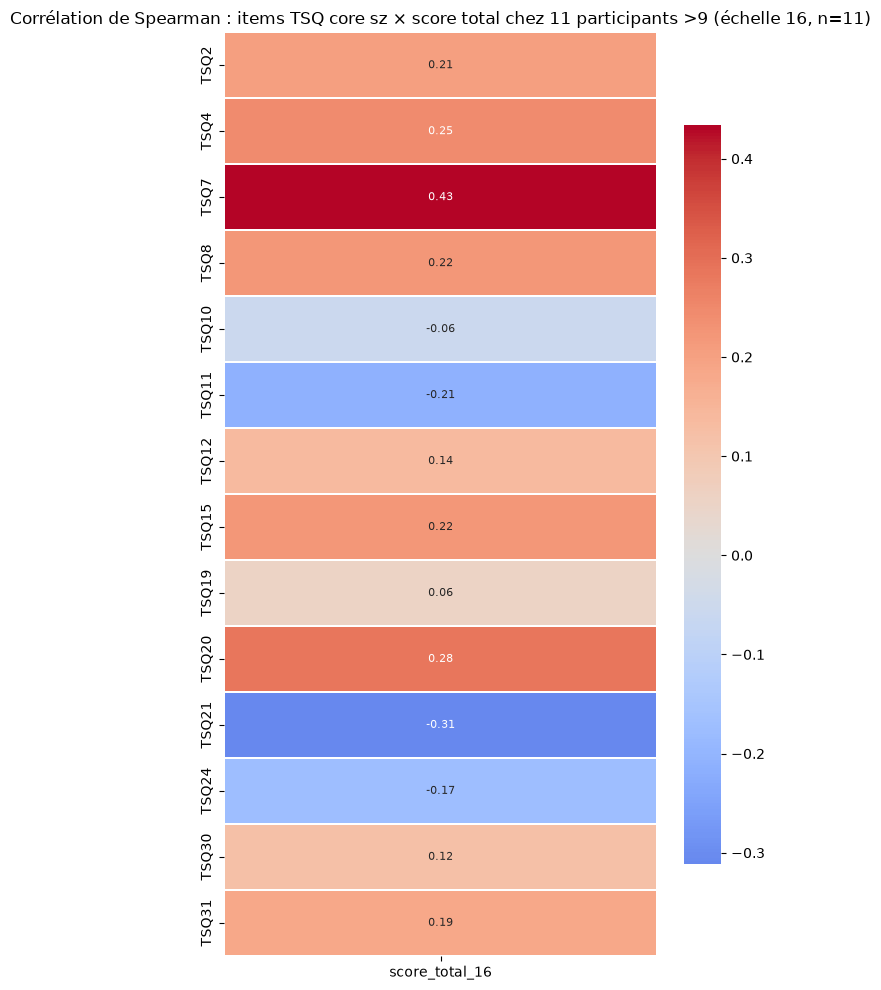

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 10))
sns.heatmap(
    corr_9[["score_total_16"]].drop("score_total_16", errors="ignore"), 
    annot=True, fmt=".2f", annot_kws={"size": 8},
    cmap="coolwarm", center=0,
    linewidths=0.3, cbar_kws={"shrink": 0.8}
)
plt.title("Corrélation de Spearman : items TSQ core sz × score total chez 11 participants >9 (échelle 16, n=11)")
plt.tight_layout()
plt.show()



TSQ4 = Parfois, certaines parties de mon corps me semblent étranges, comme si elles ne 
m'appartenaient pas ou avaient été déconnectées les unes des autres, ou même comme si elles 
n'existaient pas du tout. 
TSQ7 = Même dans des endroits que je connais bien, je me sens parfois complètement perdu(e) ou 
désorienté(e), n'étant pas certain(e) de comment avancer ou reculer. C'est comme si j'étais 
constamment désorienté(e) et confus(e). 
TSQ31 = J'ai eu l'impression que tout, autour de moi, était trop éloigné. C'est comme si l'espace et 
les choses physiques semblaient très éloignés et un peu futiles. C'est comme si tout s'étendait à 
l'infini et n'avait vraiment aucun sens. 

TSQ11 =  Parfois, je remarque que certaines parties de mon corps me paraissent comme rapetissées 
ou tendues, ou j'ai la sensation que mon corps tout entier se contracte ou s'étend, comme s'il 
était en train d'être pressé ou comprimé. 
TSQ21=  Il y a des moments où je ne peux pas vraiment dire où mon corps s'arrête et où tout le 
reste commence. C'est comme si les choses autour de moi semblaient faire partie de moi ou 
être collées à moi d'une manière ou d'une autre. Et puis il y a des moments où des choses 
semblent, depuis l'extérieur, faire directement irruption dans ma tête et dans mon corps, 
perturbant mon corps et mon esprit.

# correl TSQ periph sz vs fPQ16? 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df_TSQ = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))

items_periph_sz = ['TSQ1','TSQ3','TSQ5','TSQ6','TSQ13','TSQ14','TSQ23','TSQ27']


groupe_score_sup_9 = df_16[df_16["nb_vrai"] > 9].copy()
print(len(groupe_score_sup_9))  # doit afficher 11

df_TSQ_9 = df_TSQ.loc[groupe_score_sup_9.index, items_periph_sz].copy()
print(df_TSQ_9.shape) 

df_final = df_TSQ_9.copy()
df_final["score_total_16"] = groupe_score_sup_9["score_total"]


corr_9 = df_final.corr(method="spearman")

from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as patches

resultats = []
for item in items_periph_sz:
    paired = df_final[[item, "score_total_16"]].dropna()
    r, p = spearmanr(paired[item], paired["score_total_16"])
    resultats.append({"item": item, "r": r, "p": p})

df_stats = pd.DataFrame(resultats).set_index("item")

rejected, p_corrected, _, _ = multipletests(df_stats["p"], alpha=0.05, method="fdr_bh")
df_stats["p_corrected"] = p_corrected
df_stats["significatif"] = rejected

print(df_stats)

13
(13, 8)
              r         p  p_corrected  significatif
item                                                
TSQ1  -0.172705  0.572604     0.796559         False
TSQ3   0.128136  0.676550     0.796559         False
TSQ5  -0.079388  0.796559     0.796559         False
TSQ6   0.388530  0.189524     0.758098         False
TSQ13  0.173927  0.569848     0.796559         False
TSQ14  0.461100  0.112763     0.758098         False
TSQ23  0.219639  0.470908     0.796559         False
TSQ27  0.099615  0.746103     0.796559         False


# participants avec fpQ16 élevés ont des scores plus élevés aux items « core SZ"??

# relation avec prise de sub ou pas - suite du questionnaire fPQI

In [ ]:
cols_sub = df_PS.columns[126:131]
print(cols_sub)

df_sub= df_PS[cols_sub]


Index(['Si vous avez répondu vrai à certaines propositions, ces symptômes sont-ils :',
       'Avez-vous déjà ressenti des idées noires et/ou suicidaires ?',
       'Si vous avez ressenti des idées noires et/ou suicidaires ces derniers mois, pensez-vous qu'elles soient en lien avec les symptômes décrits dans ce questionnaire ?',
       'Si oui, quels symptômes (donner les propositions correspondantes entre 1 et 16) ?',
       'Pour chacun de ces symptômes, à quel point sont-ils en lien avec vos idées noires et/ou suicidaires selon vous (0=absence de lien 10=lien le plus intense et le plus direct)   Note .../10 :'],
      dtype='str')


In [911]:
print(df_sub["Si vous avez répondu vrai à certaines propositions, ces symptômes sont-ils :"].value_counts())

Si vous avez répondu vrai à certaines propositions, ces symptômes sont-ils :
Sans relation avec une consommation de substances                             142
Observés uniquement lors d'une consommation de substances                       1
En relation avec une consommation de substance et aussi à d'autres moments      1
Name: count, dtype: int64


In [912]:
df_merged3 = pd.DataFrame({
    "nb_vrai": df_16["nb_vrai"].values,
    "score_total": df_16["score_total"].values,
    "relation_sub": df_sub["Si vous avez répondu vrai à certaines propositions, ces symptômes sont-ils :"].values
})
groupe_relation = df_merged3[
    df_merged3["relation_sub"] == "En relation avec une consommation de substance et aussi à d'autres moments"
]

groupe_uniquement = df_merged3[
    df_merged3["relation_sub"] == "Observés uniquement lors d'une consommation de substances"
]

print("--- En relation + autres moments (n =", len(groupe_relation), ") ---")
print(groupe_relation[["nb_vrai", "score_total"]])

print("\n--- Uniquement lors de consommation (n =", len(groupe_uniquement), ") ---")
print(groupe_uniquement[["nb_vrai", "score_total"]])
   

--- En relation + autres moments (n = 1 ) ---
     nb_vrai  score_total
116        6          9.0

--- Uniquement lors de consommation (n = 1 ) ---
    nb_vrai  score_total
81        7          1.0


In [913]:
print(df_sub["Avez-vous déjà ressenti des idées noires et/ou suicidaires ?"].value_counts())

Avez-vous déjà ressenti des idées noires et/ou suicidaires ?
Non    96
Oui    70
Name: count, dtype: int64


In [914]:
df_merged3 = pd.DataFrame({
    "nb_vrai": df_16["nb_vrai"].values,
    "score_total": df_16["score_total"].values,
    "suic": df_sub["Avez-vous déjà ressenti des idées noires et/ou suicidaires ?"].values
})
groupe_idees_noires = df_merged3[
    df_merged3["suic"] == "Oui"
]

print("--- Idées noires/suic (n =", len(groupe_idees_noires), ") ---")
print(groupe_idees_noires[["nb_vrai", "score_total"]])



--- Idées noires/suic (n = 70 ) ---
     nb_vrai  score_total
0          8          9.0
1          1          3.0
3          0          0.0
4          4          4.0
5          3          5.0
..       ...          ...
151        5          6.0
157        3          3.0
160        7         13.0
161        1          1.0
165        2          3.0

[70 rows x 2 columns]


In [915]:
print(df_sub["Si vous avez ressenti des idées noires et/ou suicidaires ces derniers mois, pensez-vous qu'elles soient en lien avec les symptômes décrits dans ce questionnaire ?"].value_counts())

Si vous avez ressenti des idées noires et/ou suicidaires ces derniers mois, pensez-vous qu'elles soient en lien avec les symptômes décrits dans ce questionnaire ?
Non    61
Oui     9
Name: count, dtype: int64


In [916]:
df_merged3 = pd.DataFrame({
    "nb_vrai": df_16["nb_vrai"].values,
    "score_total": df_16["score_total"].values,
    "lien": df_sub["Si vous avez ressenti des idées noires et/ou suicidaires ces derniers mois, pensez-vous qu'elles soient en lien avec les symptômes décrits dans ce questionnaire ?"].values
})
groupe_lien_idees_noires = df_merged3[
    df_merged3["lien"] == "Oui"
]

print("--- lien idées noires/suic (n =", len(groupe_lien_idees_noires), ") ---")
print(groupe_lien_idees_noires[["nb_vrai", "score_total"]])

--- lien idées noires/suic (n = 9 ) ---
     nb_vrai  score_total
6          8         16.0
27         7          6.0
62         9         12.0
76        14         39.0
79         7         11.0
80        13         31.0
87         7         12.0
91         5          6.0
117        3          7.0


In [917]:
col_symptomes = "Si oui, quels symptômes (donner les propositions correspondantes entre 1 et 16) ?"
print(df_sub[col_symptomes].unique())

<StringArray>
[                          nan,                     '7 et 11',
                           '1',                      '1 et 5',
                           '2',                     '9 11 14',
                          '11',                    '14 et 11',
 'Sentiment de pas être aimée']
Length: 9, dtype: str


In [ ]:
mapping_questions = {i+1: col for i, col in enumerate(echelle1)}
print(mapping_questions)

{1: "[1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.][Échelle 1]", 2: "[2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu).][Échelle 1]", 3: '[3- Je sens parfois des odeurs ou des goûts que les autres ne peuvent pas sentir.][Échelle 1]', 4: "[4- J'entends souvent des sons inhabituels comme des tapes, des clics, des sifflements, des claquements ou des tintements dans mes oreilles.][Échelle 1]", 5: '[5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.][Échelle 1]', 6: "[6- Quand je regarde quelqu'un ou que je me regarde dans le miroir j'ai vu ce visage se modifier juste sous mes yeux.][Échelle 1]", 7: '[7- Je me sens très anxieux quand je rencontre des gens pour la première fois.][Échelle 1]', 8: "[8- J'ai déjà vu des choses qu'apparemment d'autres personnes ne peuvent pas voir.][Échelle 1]", 9: '[9- Mes pensées sont parfois tellement fortes que je peux p

In [ ]:
import re

def extraire_numeros(texte):
    if pd.isna(texte):
        return []
    return [int(n) for n in re.findall(r"\d+", str(texte))]


df_merged3["symptomes_texte"] = df_sub[col_symptomes].values
df_merged3["symptomes_numeros"] = df_merged3["symptomes_texte"].apply(extraire_numeros)
df_merged3["symptomes_questions"] = df_merged3["symptomes_numeros"].apply(
    lambda liste: [mapping_questions.get(n, f"Numéro {n} inconnu") for n in liste]
)

In [921]:
groupe_sympt = df_merged3[df_merged3["lien"] == "Oui"]

pd.set_option('display.max_colwidth', None)
print(groupe_sympt[["nb_vrai", "score_total", "symptomes_numeros", "symptomes_questions"]])

     nb_vrai  score_total symptomes_numeros  \
6          8         16.0           [7, 11]   
27         7          6.0               [1]   
62         9         12.0            [1, 5]   
76        14         39.0               [2]   
79         7         11.0       [9, 11, 14]   
80        13         31.0              [11]   
87         7         12.0              [11]   
91         5          6.0          [14, 11]   
117        3          7.0                []   

                                                                                                                                                                                                                                                              symptomes_questions  
6                                                                                 [[7- Je me sens très anxieux quand je rencontre des gens pour la première fois.][Échelle 1], [11- Parfois j'ai senti que je n'ai pas le contrôle sur mes propres idées où p

In [ ]:
col_note_lien = "Pour chacun de ces symptômes, à quel point sont-ils en lien avec vos idées noires et/ou suicidaires selon vous (0=absence de lien 10=lien le plus intense et le plus direct)   Note .../10 :"

df_merged3["note_lien"] = df_sub[col_note_lien].values

print(df_merged3["note_lien"].unique())

<StringArray>
[nan, '5/10 et 8/10', '5', '1 = 7 et 5 = 8', '8', '7/10', '6', '7', '10']
Length: 9, dtype: str


# Manuellement car je n'y arrive pas

In [985]:
#participant 6         nb vrai= 8         score_total= 16.0        note_lien = nan                                        items concernés= nan
# participant 28       nb vrai  7        score tot  6.0               note_lien = 5/10 pour item 7 et 8/10 pour item 11      items concernés= [7, 11]   -->  [[7- Je me sens très anxieux quand je rencontre des gens pour la première fois.][Échelle 1], [11- Parfois j'ai senti que je n'ai pas le contrôle sur mes propres idées où pensées.]
#participant 64        nb vrai= 9         score tot = 12.0          note_lien = 5                                        item concerné = 1                --> [1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.
#participant 78        14                    39.0                  note_lien=7/10 et 8/10                              item concerné = 1 et 5            --> [1- Je me sens indifférent(e) face aux choses que j'apprécie habituellement.  [5- Je suis parfois confus parce que je ne sais pas si une expérience était réelle ou imaginaire.
#participant 81           7                  11.0                           note_lien= 8                                 = 2                              --> [2- J'ai souvent l'impression de vivre les événements exactement comme ils se sont produits auparavant (déjà vu)
#participant 82        13                    31.0                       note_lien=7                                    = 9,11,14                         --> [9- Mes pensées sont parfois tellement fortes que je peux presque les entendre.][Échelle 1], [11- Parfois j'ai senti que je n'ai pas le contrôle sur mes propres idées où pensées.][Échelle 1], [14- J'ai souvent l'impression que les autres sont contre moi.]
#participant 89         7                    12.0                         note_lien6=                                = 11                                 --> [11- Parfois j'ai senti que je n'ai pas le contrôle sur mes propres idées où pensées.]
#participant 93         5                     6.0                         note_lien=7                                = 14 et 11                            --> [11- Parfois j'ai senti que je n'ai pas le contrôle sur mes propres idées où pensées.][Échelle 1], [14- J'ai souvent l'impression que les autres sont contre moi.]
#participant 120        3                      7.0                        note_lien=10                                = sentiment de pas etre aimé (on ne sait pas quelle question cela correspond)

# Extraction df ZTPI

* 56 items avec cinq sous-dimensions que sont le passé négatif, le passé positif, le présent fataliste, le présent hédoniste, et le futur – 1 (pas du tout caractéristique de moi) à 5 (tout à fait caractéristique de moi)
* 1 (pas du tout caractéristique de moi) à 5 (tout à fait caractéristique de moi).

In [924]:
cols_ZTPI = df_PS.columns[131:187]
cols_ZTPI = [col for i, col in enumerate(cols_ZTPI) if i not in (15, 36)]
print(cols_ZTPI)
df_ZTPI= df_PS[cols_ZTPI]


['[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]', '[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]', '[3- Le destin détermine beaucoup de choses dans ma vie.]', '[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]', '[5- Mes décisions sont principalement influencées par les événements et les gens autour de moi.]', '[6- Je crois que la journée d’une personne doit être planifiée à l’avance chaque matin.]', '[7- Le fait de penser à mon passé me donne du plaisir.]', '[8- Je fais les choses de manière impulsive.]', '[9- Si les choses ne sont pas faites à temps, je ne m’en préoccupe pas.]', '[10- Quand je dois réaliser quelque chose, je me fixe des buts et j’envisage les moyens précis pour les atteindre.]', '[11- Tout compte fait, il y a beaucoup plus de bonnes choses à se souvenir dans mon passé que de mauvaises.]', '[12- Quand j’écoute ma musiq

In [925]:
df_ZTPI.describe()

,[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ],"[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]",[3- Le destin détermine beaucoup de choses dans ma vie.],[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.],[5- Mes décisions sont principalement influencées par les événements et les gens autour de moi.],[6- Je crois que la journée d’une personne doit être planifiée à l’avance chaque matin.],[7- Le fait de penser à mon passé me donne du plaisir.],[8- Je fais les choses de manière impulsive.],"[9- Si les choses ne sont pas faites à temps, je ne m’en préoccupe pas.]","[10- Quand je dois réaliser quelque chose, je me fixe des buts et j’envisage les moyens précis pour les atteindre.]",...,"[47- Aujourd’hui, la vie est trop compliquée ; j’aurais préféré la vie simple du passé. ]",[48- Je préfère les amis qui sont spontanés à ceux qui sont prévisibles.],[49- J’aime bien les traditions et les coutumes familiales qui sont régulièrement répétées. ],[50- Je pense aux mauvaises choses qui me sont arrivées dans le passé],[51- Je persiste à travailler à des activités difficiles et sans intérêt si elles m’aident à prendre de l’avance.],[52- Je préfère dépenser ce que je gagne en me faisant plaisir aujourd’hui plutôt que d’épargner pour ma sécurité de demain.],"[53- Souvent, la chance rapporte plus que de travailler dur.]",[54- Je pense aux bonnes choses que j’ai ratées dans ma vie.],[55- J’aime bien que les relations avec mes proches soient passionnées.],[56- Il y aura toujours le temps pour que je rattrape mon travail.]
count,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.00000,166.000000,166.000000,166.000000,...,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,4.060241,3.783133,2.530120,3.222892,3.030120,2.361446,2.86747,2.656627,1.825301,3.692771,...,2.138554,3.150602,3.421687,2.566265,2.457831,2.614458,2.162651,2.313253,3.530120,2.632530
std,0.970466,1.067971,1.189218,1.299774,1.075483,1.191671,1.08735,1.224566,0.990665,1.110095,...,1.190399,1.098856,1.118662,1.276290,1.142047,1.137049,1.156296,1.235120,1.019059,1.102571
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.000000,3.000000,2.000000,2.000000,2.000000,1.000000,2.00000,2.000000,1.000000,3.000000,...,1.000000,3.000000,3.000000,1.000000,1.250000,2.000000,1.000000,1.000000,3.000000,2.000000
50%,4.000000,4.000000,2.000000,3.000000,3.000000,2.000000,3.00000,3.000000,1.500000,4.000000,...,2.000000,3.000000,4.000000,2.000000,2.000000,3.000000,2.000000,2.000000,4.000000,3.000000
75%,5.000000,5.000000,3.000000,4.000000,4.000000,3.000000,4.00000,4.000000,2.000000,4.750000,...,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [926]:
df_ZTPI.median()

[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]                                  4.0
[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]                            4.0
[3- Le destin détermine beaucoup de choses dans ma vie.]                                                                                     2.0
[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]                                                                      3.0
[5- Mes décisions sont principalement influencées par les événements et les gens autour de moi.]                                             3.0
[6- Je crois que la journée d’une personne doit être planifiée à l’avance chaque matin.]                                                     2.0
[7- Le fait de penser à mon passé me donne du plaisir.]                                                                           

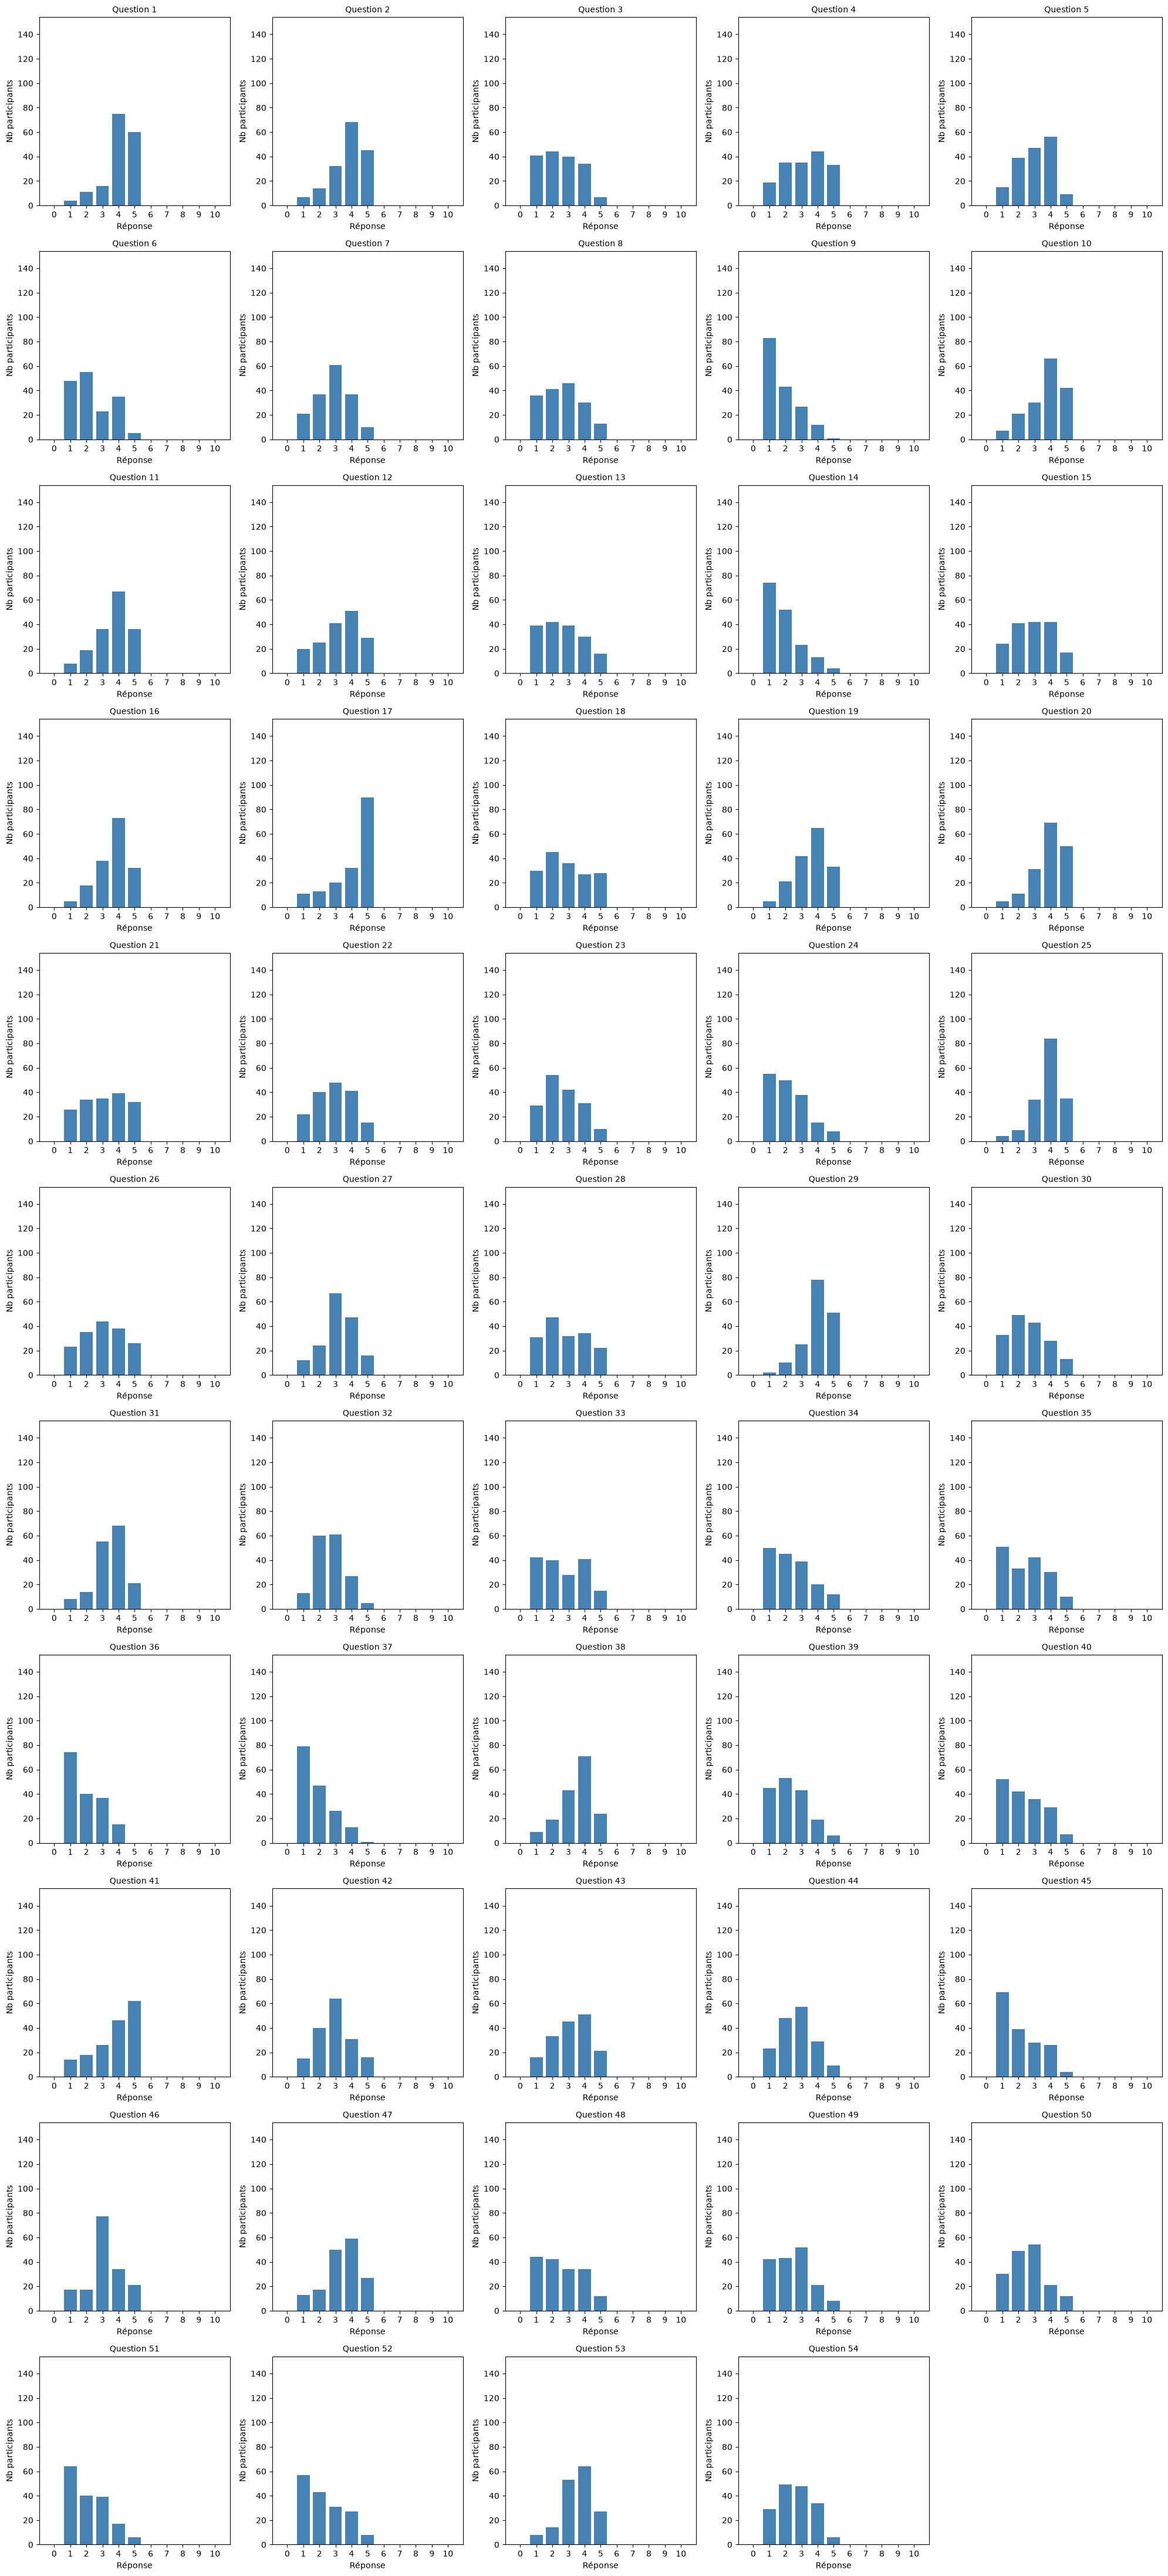

In [927]:
items = df_ZTPI.columns.tolist()
df_ZTPI[items] = df_ZTPI[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(0, 11))  

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_ZTPI[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 154)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [928]:

for i in items:
    print(f"Question : {i}")
    print(df_ZTPI[i].value_counts())
    print("\n")

Question : [1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]
[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]
4.0    75
5.0    60
3.0    16
2.0    11
1.0     4
Name: count, dtype: int64


Question : [2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]
[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]
4.0    68
5.0    45
3.0    32
2.0    14
1.0     7
Name: count, dtype: int64


Question : [3- Le destin détermine beaucoup de choses dans ma vie.]
[3- Le destin détermine beaucoup de choses dans ma vie.]
2.0    44
1.0    41
3.0    40
4.0    34
5.0     7
Name: count, dtype: int64


Question : [4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]
[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]
4.0    44
3.0    35


In [929]:
cols_ZTPI_PD= df_PD.columns[131:187]
cols_ZTPI_PD = [col for i, col in enumerate(cols_ZTPI_PD) if i not in (15, 36)]

df_ZTPI_PD= df_PD[cols_ZTPI_PD]


In [930]:
df_ZTPI_PD.describe()

,[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ],"[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]",[3- Le destin détermine beaucoup de choses dans ma vie.],[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.],[5- Mes décisions sont principalement influencées par les événements et les gens autour de moi.],[6- Je crois que la journée d’une personne doit être planifiée à l’avance chaque matin.],[7- Le fait de penser à mon passé me donne du plaisir.],[8- Je fais les choses de manière impulsive.],"[9- Si les choses ne sont pas faites à temps, je ne m’en préoccupe pas.]","[10- Quand je dois réaliser quelque chose, je me fixe des buts et j’envisage les moyens précis pour les atteindre.]",...,"[47- Aujourd’hui, la vie est trop compliquée ; j’aurais préféré la vie simple du passé. ]",[48- Je préfère les amis qui sont spontanés à ceux qui sont prévisibles.],[49- J’aime bien les traditions et les coutumes familiales qui sont régulièrement répétées. ],[50- Je pense aux mauvaises choses qui me sont arrivées dans le passé],[51- Je persiste à travailler à des activités difficiles et sans intérêt si elles m’aident à prendre de l’avance.],[52- Je préfère dépenser ce que je gagne en me faisant plaisir aujourd’hui plutôt que d’épargner pour ma sécurité de demain.],"[53- Souvent, la chance rapporte plus que de travailler dur.]",[54- Je pense aux bonnes choses que j’ai ratées dans ma vie.],[55- J’aime bien que les relations avec mes proches soient passionnées.],[56- Il y aura toujours le temps pour que je rattrape mon travail.]
count,35.00000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,...,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,4.00000,3.285714,2.342857,3.514286,3.228571,2.514286,2.257143,2.771429,1.657143,3.914286,...,2.400000,3.085714,3.285714,3.400000,2.800000,2.971429,2.542857,3.000000,3.657143,2.514286
std,1.16316,1.273518,1.282068,1.221653,1.285341,1.379928,1.244821,1.308023,0.905631,1.067472,...,1.438954,1.121224,1.486635,1.090062,1.255576,1.200140,1.146423,1.236694,1.027357,1.291862
min,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.00000,2.000000,1.000000,3.000000,2.500000,1.000000,1.000000,2.000000,1.000000,3.000000,...,1.000000,3.000000,2.500000,3.000000,2.000000,2.000000,1.500000,2.000000,3.000000,1.500000
50%,4.00000,3.000000,2.000000,4.000000,3.000000,2.000000,2.000000,3.000000,1.000000,4.000000,...,2.000000,3.000000,4.000000,4.000000,3.000000,3.000000,3.000000,3.000000,4.000000,2.000000
75%,5.00000,4.000000,3.000000,4.500000,4.000000,3.500000,3.000000,4.000000,2.000000,5.000000,...,3.500000,3.500000,4.500000,4.000000,4.000000,4.000000,3.500000,4.000000,4.000000,3.500000
max,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.000000,5.000000,5.000000,5.000000


In [931]:
df_ZTPI_PD.median()

[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]                                  4.0
[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]                            3.0
[3- Le destin détermine beaucoup de choses dans ma vie.]                                                                                     2.0
[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]                                                                      4.0
[5- Mes décisions sont principalement influencées par les événements et les gens autour de moi.]                                             3.0
[6- Je crois que la journée d’une personne doit être planifiée à l’avance chaque matin.]                                                     2.0
[7- Le fait de penser à mon passé me donne du plaisir.]                                                                           

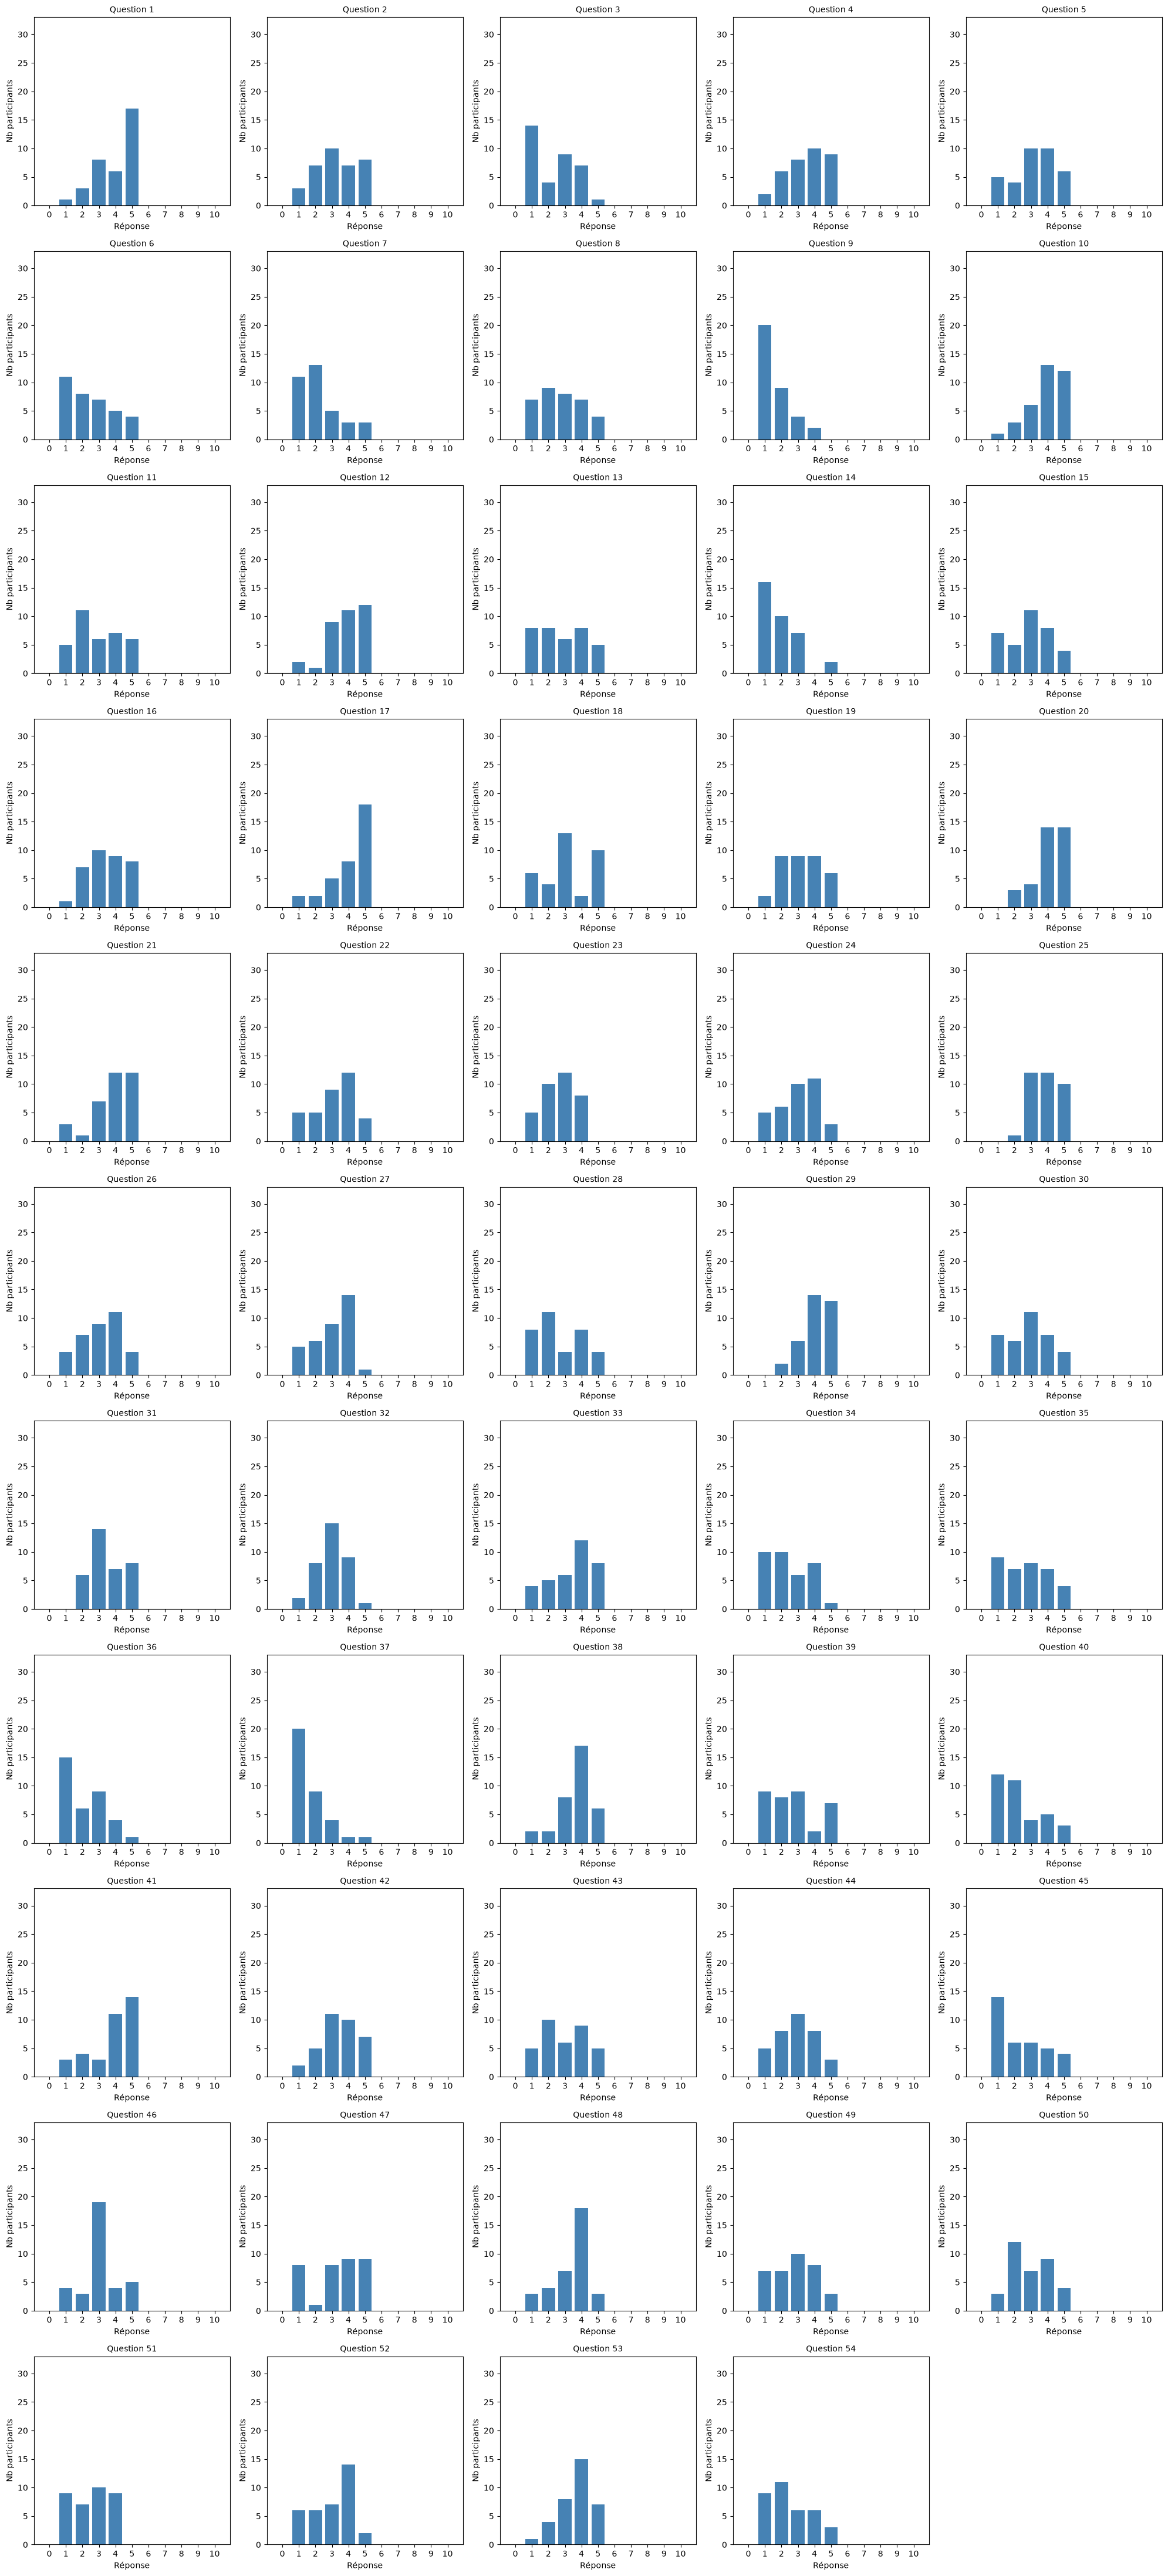

In [932]:

items = df_ZTPI_PD.columns.tolist()
df_ZTPI_PD[items] = df_ZTPI_PD[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))
n = len(items)
ncols = 5
nrows = int(np.ceil(n / ncols))

echelle = list(range(0, 11))  

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for i, q in enumerate(items):
    counts = df_ZTPI_PD[q].value_counts().reindex(echelle, fill_value=0)
    axes[i].bar(counts.index, counts.values, color="steelblue")
    axes[i].set_title(f"Question {i+1}", fontsize=10)
    axes[i].set_xlabel("Réponse")
    axes[i].set_ylabel("Nb participants")
    axes[i].set_xticks(echelle)
    axes[i].set_ylim(0, 33)

for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [933]:

for i in items:
    print(f"Question : {i}")
    print(df_ZTPI_PD[i].value_counts())
    print("\n")

Question : [1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]
[1- Je crois que se retrouver avec des amis pour faire la fête est l’un des plaisirs important de la vie. ]
5.0    17
3.0     8
4.0     6
2.0     3
1.0     1
Name: count, dtype: int64


Question : [2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]
[2- Les images, les odeurs et les sons familiers de mon enfance me rappellent souvent des souvenirs merveilleux.]
3.0    10
5.0     8
2.0     7
4.0     7
1.0     3
Name: count, dtype: int64


Question : [3- Le destin détermine beaucoup de choses dans ma vie.]
[3- Le destin détermine beaucoup de choses dans ma vie.]
1.0    14
3.0     9
4.0     7
2.0     4
5.0     1
Name: count, dtype: int64


Question : [4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]
[4- Je pense souvent à ce que j’aurais dû faire autrement dans ma vie.]
4.0    10
5.0     9


In [934]:
df_ZTPI["score_total"] = df_ZTPI.sum(axis=1)
df_ZTPI["score_total"].describe()

count    166.000000
mean     158.228916
std       16.450348
min      116.000000
25%      146.250000
50%      159.000000
75%      167.000000
max      219.000000
Name: score_total, dtype: float64

In [935]:
df_ZTPI["score_total"].median()

np.float64(159.0)

In [936]:
df_ZTPI_PD["score_total"] = df_ZTPI_PD.sum(axis=1)
df_ZTPI_PD["score_total"].describe()

count     35.000000
mean     164.600000
std       19.621717
min      128.000000
25%      149.000000
50%      164.000000
75%      179.500000
max      212.000000
Name: score_total, dtype: float64

In [937]:
df_ZTPI_PD["score_total"].median()

np.float64(164.0)

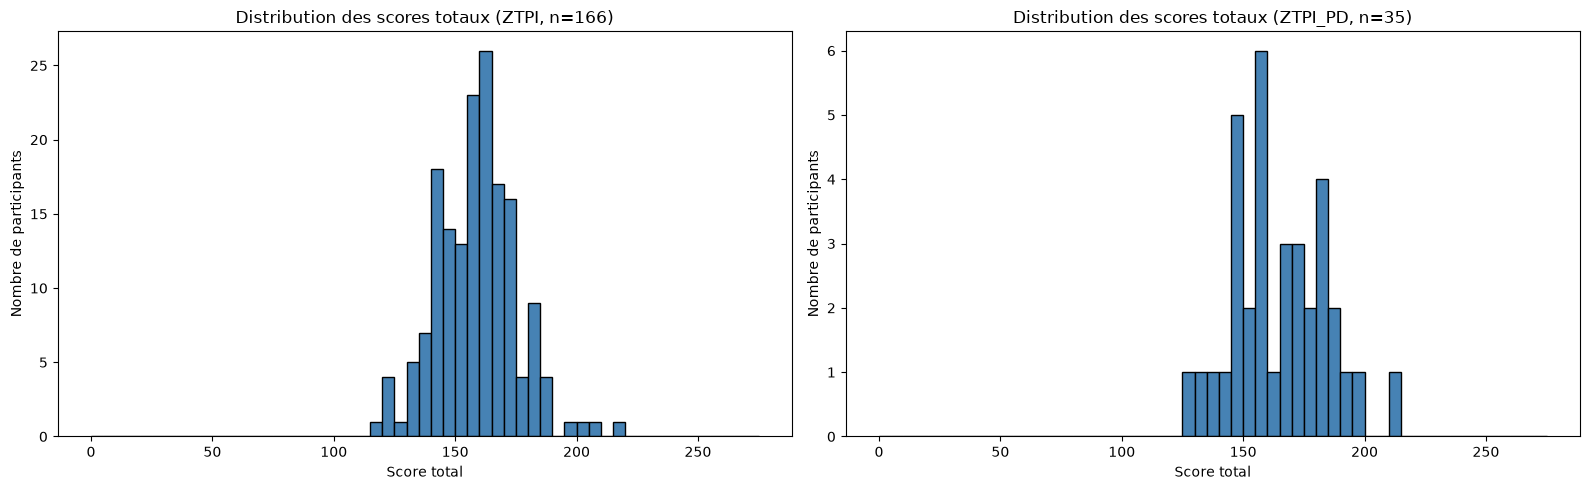

In [938]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_ZTPI["score_total"], bins=range(0, 280, 5), color="steelblue", edgecolor="black")
axes[0].set_xlabel("Score total")
axes[0].set_ylabel("Nombre de participants")
axes[0].set_title(f"Distribution des scores totaux (ZTPI, n={len(df_ZTPI)})")

axes[1].hist(df_ZTPI_PD["score_total"], bins=range(0, 280, 5), color="steelblue", edgecolor="black")
axes[1].set_xlabel("Score total")
axes[1].set_ylabel("Nombre de participants")
axes[1].set_title(f"Distribution des scores totaux (ZTPI_PD, n={len(df_ZTPI_PD)})")

plt.tight_layout()
plt.show()

In [939]:
print(df_EP_PD.loc[242, "score_total"]) # pour voir les scores d'une ligne en particulier

23.0


# correlation BAI et present fataliste ZTPI? 
item ZTPI : 28, 14, 39, 35, 53

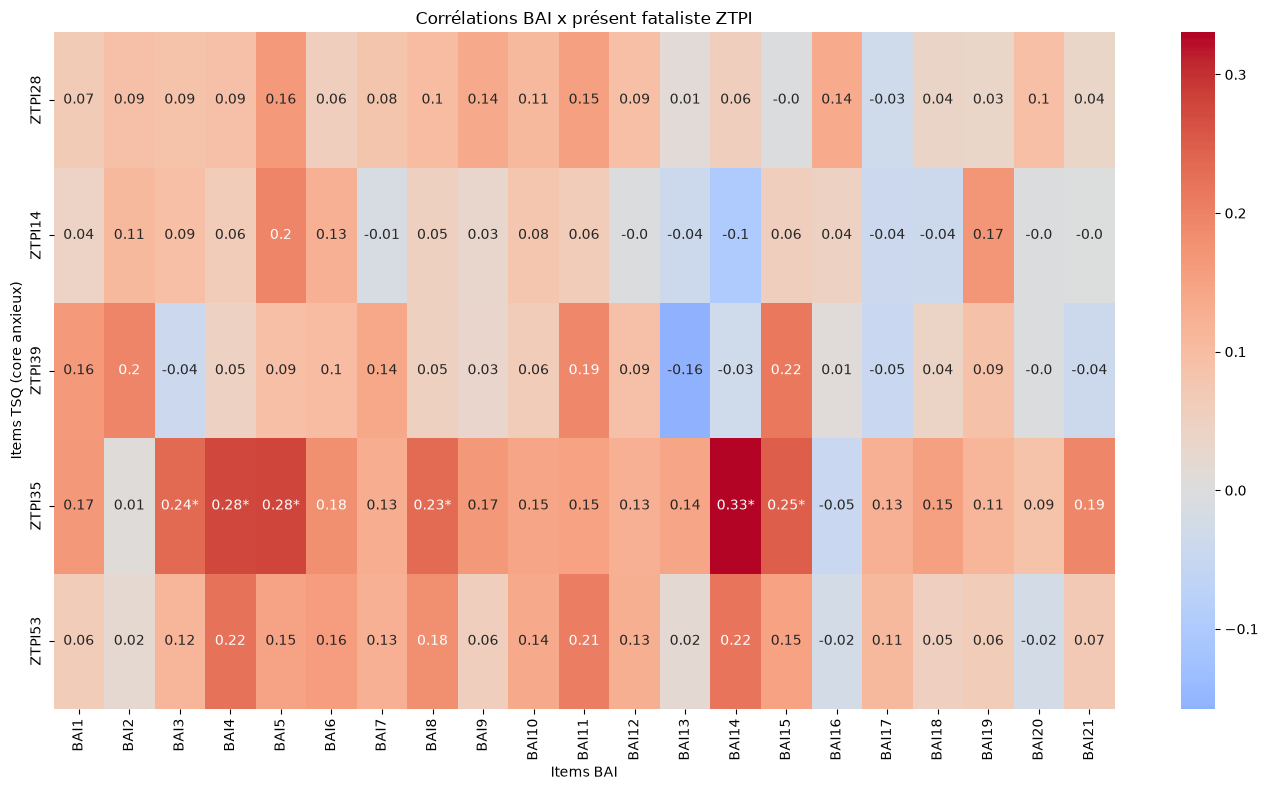

In [940]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- ZTPI ---
cols_ZTPI_brutes = df_ZTPI.columns[0:53]
df_ZTPI = df_ZTPI.rename(columns=dict(zip(cols_ZTPI_brutes, [f"ZTPI{i}" for i in range(1, 54)])))
items_ZTPI = [f"ZTPI{i}" for i in range(1, 54)]
df_ZTPI[items_ZTPI] = df_ZTPI[items_ZTPI].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

items_PF_ZTPI = ['ZTPI28', 'ZTPI14', 'ZTPI39', 'ZTPI35', 'ZTPI53']  # ✅ sans underscore, cohérent avec le renommage

# --- BAI ---
cols_bai_brutes = df_BAI.columns[0:21]  # ✅ définie AVANT utilisation
df_BAI = df_BAI.rename(columns=dict(zip(cols_bai_brutes, [f"BAI{i}" for i in range(1, 22)])))
items_bai = [f"BAI{i}" for i in range(1, 22)]
df_BAI[items_bai] = df_BAI[items_bai].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

# --- Assemblage (ZTPI et non df !) ---
concat_items = pd.concat([df_ZTPI[items_PF_ZTPI], df_BAI[items_bai]], axis=1)

# --- Corrélation ---
corr_matrix_full = concat_items.corr(method='spearman')
corr_matrix = corr_matrix_full.loc[items_PF_ZTPI, items_bai]

# Matrices vides pour stocker r et p
corr_matrix = pd.DataFrame(index=items_PF_ZTPI, columns=items_bai, dtype=float)
pval_matrix = pd.DataFrame(index=items_PF_ZTPI, columns=items_bai, dtype=float)

for i in items_PF_ZTPI:
    for u in items_bai:
        # on retire les paires avec NaN
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

# --- Correction pour comparaisons multiples (FDR, méthode Benjamini-Hochberg) ---
pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05

plt.figure(figsize=(14, 8))

annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations BAI x présent fataliste ZTPI")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

BAI 4 = Au cours des 7 derniers jours, j’ai été affecté(e) par… [4- Incapacité de se détendre]
BAI5= Au cours des 7 derniers jours, j’ai été affecté(e) par… [5- Crainte que le pire ne survienne]
BAi8 =Au cours des 7 derniers jours, j’ai été affecté(e) par… [8- Mal assuré(e), manque d’assurance dans mes mouvements ]
BAI 14= Au cours des 7 derniers jours, j’ai été affecté(e) par… [14- Crainte de perdre le contrôle de soi]
BAI 15= Au cours des 7 derniers jours, j’ai été affecté(e) par… [15- Respiration difficile ]

ZTPI35 = [35- Je n’ai plus aucun plaisir à faire des choses si je dois penser aux objectifs, aux conséquences et aux résultats.]

# correlation TSQ core anxieux vs present fataliste ZTPI? 

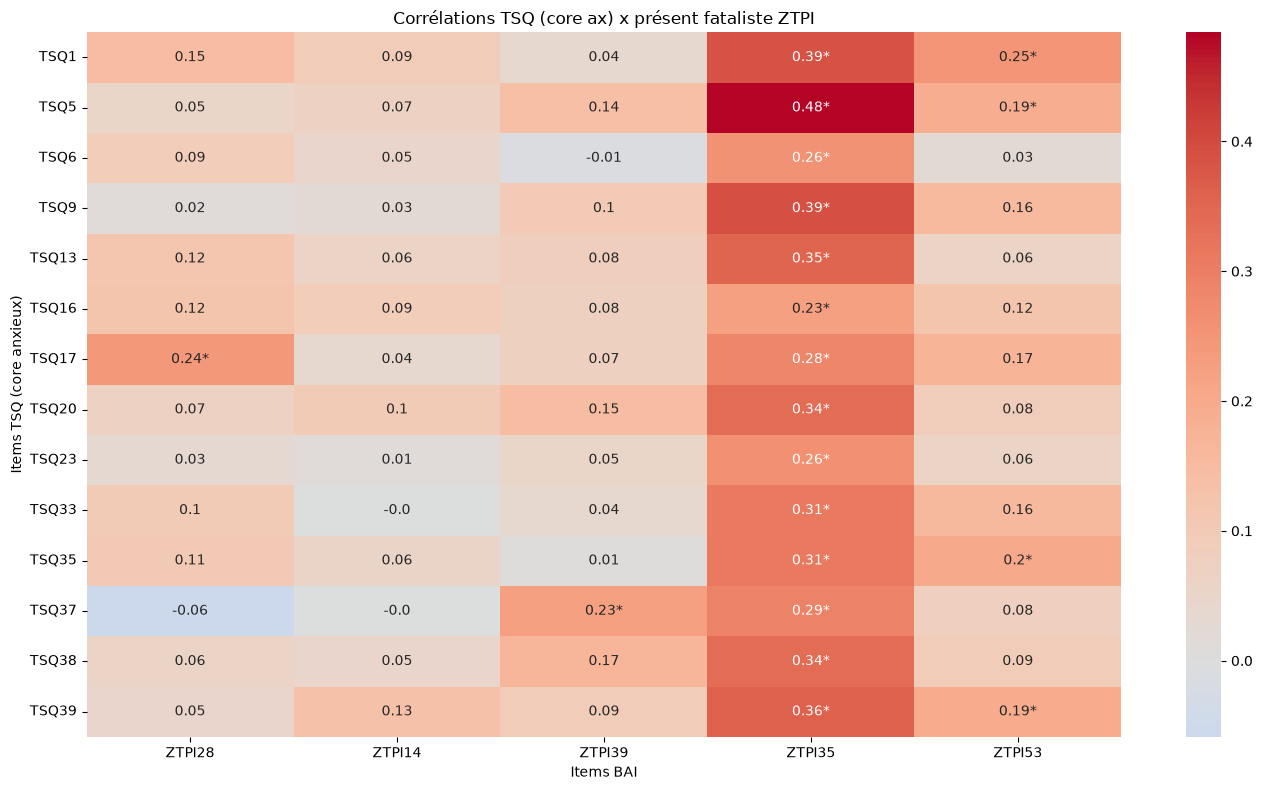

In [941]:

cols_tsq_brutes = df_TSQ.columns[0:40]
df = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df[items] = df[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

items_core_an = ['TSQ1','TSQ5','TSQ6','TSQ9','TSQ13','TSQ16','TSQ17','TSQ20',
                  'TSQ23','TSQ33','TSQ35','TSQ37','TSQ38','TSQ39']


cols_ZTPI_brutes = df_ZTPI.columns[0:53]
df_ZTPI = df_ZTPI.rename(columns=dict(zip(cols_ZTPI_brutes, [f"ZTPI{i}" for i in range(1, 54)])))
items_ZTPI = [f"ZTPI{i}" for i in range(1, 54)]
df_ZTPI[items_ZTPI] = df_ZTPI[items_ZTPI].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

items_PF_ZTPI = ['ZTPI28', 'ZTPI14', 'ZTPI39', 'ZTPI35', 'ZTPI53']  # ✅ sans underscore, cohérent avec le renommage


# on assemble les deux blocs de données (valeurs, pas noms) dans un seul DataFrame
# en s'assurant que les index (participants) correspondent bien entre df et df_BAI
concat_items = pd.concat([df[items_core_an], df_ZTPI[items_PF_ZTPI]], axis=1)

# matrice de corrélation complète (TSQ + ZTPI ensemble)
corr_matrix_full = concat_items.corr(method='spearman')

# on garde uniquement le bloc croisé : lignes TSQ x colonnes ZTPI
corr_matrix = corr_matrix_full.loc[items_core_an, items_PF_ZTPI]

# Matrices vides pour stocker r et p
corr_matrix = pd.DataFrame(index=items_core_an, columns=items_PF_ZTPI, dtype=float)
pval_matrix = pd.DataFrame(index=items_core_an, columns=items_PF_ZTPI, dtype=float)

for i in items_core_an:
    for u in items_PF_ZTPI:
        # on retire les paires avec NaN
        paired = concat_items[[i, u]].dropna()
        r, p = spearmanr(paired[i], paired[u])
        corr_matrix.loc[i, u] = r
        pval_matrix.loc[i, u] = p

# --- Correction pour comparaisons multiples (FDR, méthode Benjamini-Hochberg) ---
pvals_flat = pval_matrix.values.flatten()
rejected, pvals_corrected, _, _ = multipletests(pvals_flat, alpha=0.05, method='fdr_bh')

pval_corrected_matrix = pd.DataFrame(
    pvals_corrected.reshape(pval_matrix.shape),
    index=pval_matrix.index,
    columns=pval_matrix.columns
)

sig_matrix = pval_corrected_matrix < 0.05

plt.figure(figsize=(14, 8))

annot_labels = corr_matrix.round(2).astype(str) + sig_matrix.map(lambda x: "*" if x else "")
sns.heatmap(corr_matrix.astype(float), annot=annot_labels, fmt="", cmap="coolwarm", center=0)

plt.title("Corrélations TSQ (core ax) x présent fataliste ZTPI")
plt.xlabel("Items BAI")
plt.ylabel("Items TSQ (core anxieux)")
plt.tight_layout()
plt.show()

ZTPI35 correle avec TSQ1, 5, 9, 13, 38, 39
1. Je me sens incertain(e) quant à ce qui va advenir, particulièrement quand je ne peux pas 
avoir de vision claire dessus.
5.  Parfois, j'ai l'impression qu'il y a un espace énorme entre ce qu'il s'est passé avant par 
rapport à ce qu'il se passe maintenant ou pourrait se passer après. C'est que j'ai tellement de 
mauvais souvenirs qu'il m'est difficile de me concentrer sur autre chose que le passé. 
9.Je suis inquiet(e) des changements dans ma vie, et me sens submergé(e). 
13.- En ce moment, j’ai l’impression qu’il y a un fossé entre qui je suis aujourd’hui et celui 
(celle) que j’étais. 
38.Je me sens submergé(e) par ma situation actuelle et incapable de contrôler quoi que ce 
soit dans ma vie. On dirait que c'est comme si je n'avais pas assez d'espace pour bouger, 
respirer ou pour atteindre les gens/les choses. 
39.  Mes pensées peuvent parfois être très irrégulières, changeant d'une manière que je ne 
peux pas prévoir ou prédire. 


# Correletion des 40 items de la TSQ

In [942]:
cols_tsq_brutes = df_TSQ.columns[0:40]
df = df_TSQ.rename(columns=dict(zip(cols_tsq_brutes, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df[items] = df[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

cols_tsq_PD = df_TSQ_PD.columns[0:40]
df_PD = df_TSQ_PD.rename(columns=dict(zip(cols_tsq_PD, [f"TSQ{i}" for i in range(1, 41)])))
items = [f"TSQ{i}" for i in range(1, 41)]
df_PD[items] = df_PD[items].apply(lambda col: col.astype(str).str.extract(r"(\d+)")[0].astype(float))

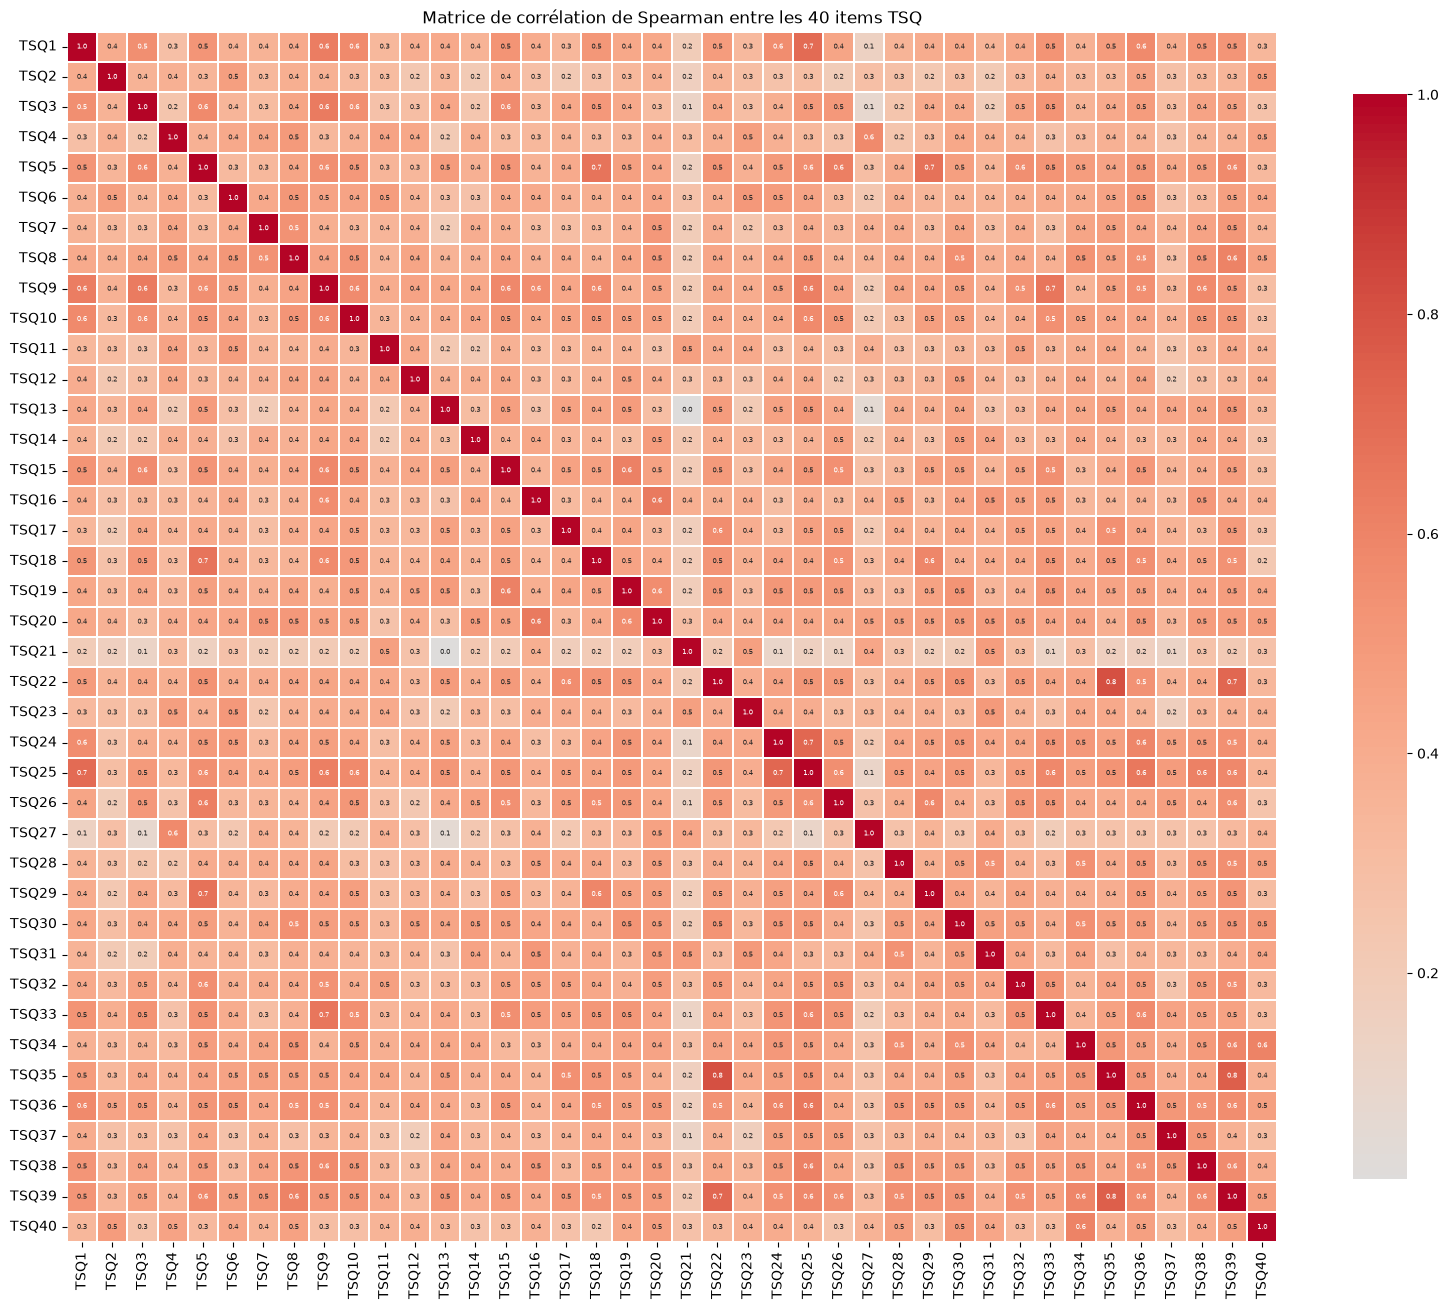

In [943]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


items = [f"TSQ{i}" for i in range(1, 41)]

# Matrice de corrélation 40x40
corr_matrix = df[items].corr(method='spearman')  # spearman

# Affichage sous forme de heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", annot_kws={"size": 5}, cmap="coolwarm", center=0, 
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation de Spearman entre les 40 items TSQ")
plt.tight_layout()
plt.show()

In [944]:
import numpy as np

# Ne garder que la partie triangulaire supérieure (évite les doublons et la diagonale)
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Transformer en liste de paires, filtrer > 0.7
strong_corr = corr_pairs.stack().reset_index()
strong_corr.columns = ['item_1', 'item_2', 'correlation']
strong_corr = strong_corr[strong_corr['correlation'] > 0.6].sort_values('correlation', ascending=False)

print(strong_corr)

     item_1 item_2  correlation
874   TSQ22  TSQ35     0.810809
1398  TSQ35  TSQ39     0.751867
944   TSQ24  TSQ25     0.725057
878   TSQ22  TSQ39     0.719194
24     TSQ1  TSQ25     0.708458
188    TSQ5  TSQ29     0.672351
177    TSQ5  TSQ18     0.668284
352    TSQ9  TSQ33     0.662612
995   TSQ25  TSQ36     0.649541
619   TSQ16  TSQ20     0.647461
88     TSQ3   TSQ9     0.633417
8      TSQ1   TSQ9     0.627404
344    TSQ9  TSQ25     0.621106
185    TSQ5  TSQ26     0.620693
578   TSQ15  TSQ19     0.617167
997   TSQ25  TSQ38     0.616205
318    TSQ8  TSQ39     0.609639
1359  TSQ34  TSQ40     0.607672


si seuil >0.7 => garder uniquement TSQ22 et supprimer TSQ35 et 39 car correlent chacun avec 22 et entre eux
si seuil >0.6 => garder uniquement TSQ9 et supp 33 et 25 + pareil qu'au dessus
A la main, je trouve aussi qu'il faut supp 36 et 26 et 18 qui correlent fortement avec 5 et entre eux

In [ ]:
print(corr_matrix.round(2))
corr_matrix.to_csv("correlation_items_TSQ.csv")

       TSQ1  TSQ2  TSQ3  TSQ4  TSQ5  TSQ6  TSQ7  TSQ8  TSQ9  TSQ10  ...  \
TSQ1   1.00  0.40  0.55  0.28  0.52  0.37  0.36  0.41  0.63   0.57  ...   
TSQ2   0.40  1.00  0.36  0.38  0.35  0.47  0.33  0.39  0.37   0.32  ...   
TSQ3   0.55  0.36  1.00  0.25  0.57  0.35  0.31  0.44  0.63   0.55  ...   
TSQ4   0.28  0.38  0.25  1.00  0.37  0.42  0.44  0.50  0.33   0.38  ...   
TSQ5   0.52  0.35  0.57  0.37  1.00  0.31  0.33  0.44  0.56   0.50  ...   
TSQ6   0.37  0.47  0.35  0.42  0.31  1.00  0.42  0.51  0.45   0.45  ...   
TSQ7   0.36  0.33  0.31  0.44  0.33  0.42  1.00  0.54  0.39   0.35  ...   
TSQ8   0.41  0.39  0.44  0.50  0.44  0.51  0.54  1.00  0.45   0.52  ...   
TSQ9   0.63  0.37  0.63  0.33  0.56  0.45  0.39  0.45  1.00   0.56  ...   
TSQ10  0.57  0.32  0.55  0.38  0.50  0.45  0.35  0.52  0.56   1.00  ...   
TSQ11  0.33  0.31  0.27  0.44  0.35  0.48  0.35  0.36  0.40   0.35  ...   
TSQ12  0.40  0.23  0.29  0.43  0.34  0.36  0.38  0.44  0.44   0.38  ...   
TSQ13  0.42  0.34  0.44  

In [946]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[items].dropna()
vif_data = pd.DataFrame()
vif_data['item'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

     item       VIF
24  TSQ25  5.122997
38  TSQ39  4.965845
34  TSQ35  4.889250
21  TSQ22  4.641221
8    TSQ9  4.541315
35  TSQ36  3.733816
4    TSQ5  3.664137
25  TSQ26  3.535783
29  TSQ30  3.516345
37  TSQ38  3.352587
7    TSQ8  3.316788
17  TSQ18  3.278956
31  TSQ32  3.272803
3    TSQ4  3.217947
22  TSQ23  3.208609
32  TSQ33  3.206259
33  TSQ34  3.199338
23  TSQ24  3.137039
19  TSQ20  3.069898
14  TSQ15  3.025491
28  TSQ29  3.011147
2    TSQ3  2.992248
0    TSQ1  2.988199
39  TSQ40  2.984333
27  TSQ28  2.958624
30  TSQ31  2.803006
5    TSQ6  2.708787
9   TSQ10  2.691538
18  TSQ19  2.678131
26  TSQ27  2.412305
1    TSQ2  2.393714
15  TSQ16  2.368103
12  TSQ13  2.338062
11  TSQ12  2.334776
16  TSQ17  2.274357
36  TSQ37  2.262885
13  TSQ14  2.154583
20  TSQ21  2.087555
6    TSQ7  1.849736
10  TSQ11  1.834622


Algo Gloutton Greedy (selectionner les var les + redondantes) : retirer la variable qui a la corrélation moyenne la plus élevée avec toutes les autres variables (celle qui est la plus "redondante" globalement).

In [ ]:


import numpy as np
import pandas as pd

def reduce_correlated_features(df, cols, threshold=0.7):
    cols = list(cols)
    while True:
        corr_df = df[cols].corr().abs()
        corr_np = corr_df.to_numpy(copy=True)  
        np.fill_diagonal(corr_np, 0)
        
        max_corr = corr_np.max()
        if max_corr <= threshold:
            break
        
        mean_corr = corr_np.mean(axis=0)
        i, j = np.unravel_index(np.argmax(corr_np), corr_np.shape)
        var1, var2 = cols[i], cols[j]
        to_drop = var1 if mean_corr[i] > mean_corr[j] else var2
        cols.remove(to_drop)
    return cols

selected_items = reduce_correlated_features(df, items, threshold=0.65)
print(f"Items conservés ({len(selected_items)}/{len(items)}) :")
print(selected_items)

dropped_items = [i for i in items if i not in selected_items]
print(f"\nItems retirés ({len(dropped_items)}) :")
print(dropped_items)

Items conservés (35/40) :
['TSQ1', 'TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29', 'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ36', 'TSQ37', 'TSQ38', 'TSQ40']

Items retirés (5) :
['TSQ5', 'TSQ9', 'TSQ22', 'TSQ25', 'TSQ39']


# faire nv df sans TSQ 1, 5,9,22,25,36, 39

In [ ]:
colonnes_a_exclure = ['TSQ1', 'TSQ5', 'TSQ9', 'TSQ22', 'TSQ25','TSQ36', 'TSQ39']  
df_red = df.drop(columns=colonnes_a_exclure)

In [ ]:
len(df_red.columns)  
print(df_red.columns)

Index(['TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11',
       'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19',
       'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29',
       'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ37', 'TSQ38',
       'TSQ40', 'score_total'],
      dtype='str')


In [950]:
df_red.drop(columns=["score_total"], inplace=True)

In [951]:
print(df_red.columns)

Index(['TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11',
       'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19',
       'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29',
       'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ37', 'TSQ38',
       'TSQ40'],
      dtype='str')


# matrice correle PD


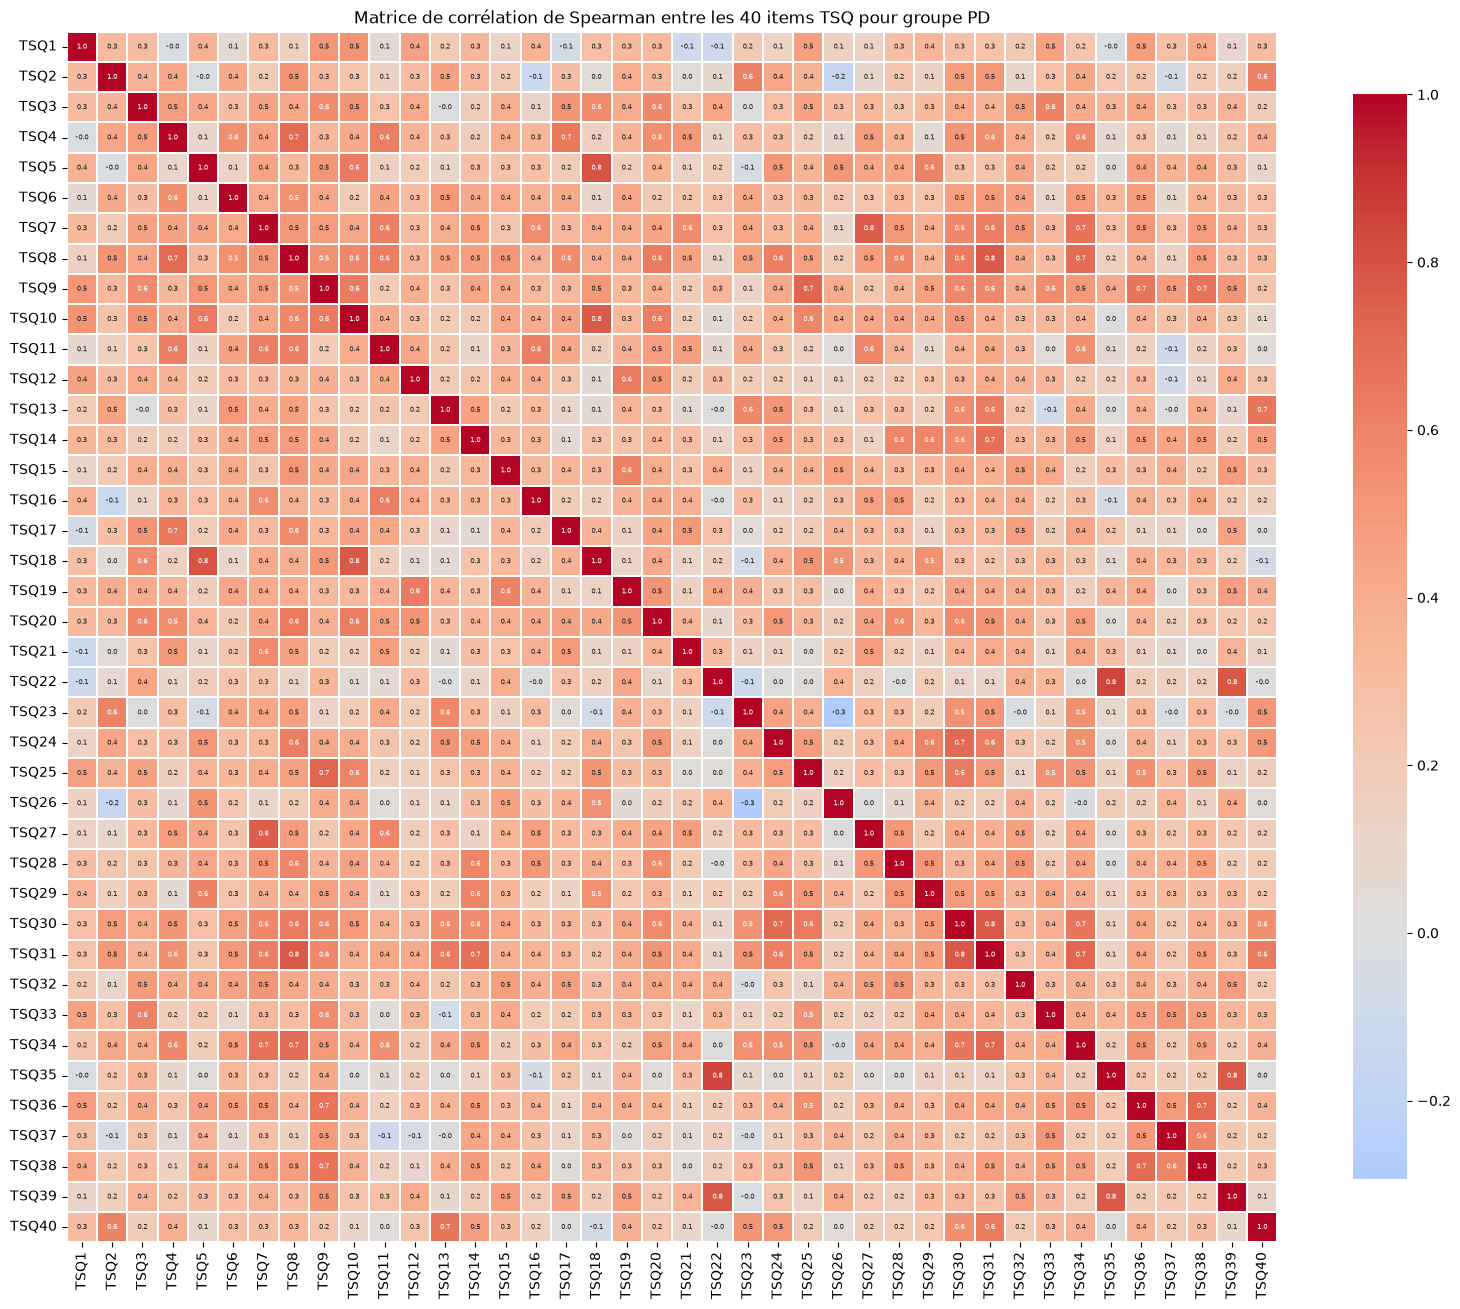

     item_1 item_2  correlation
874   TSQ22  TSQ35     0.843959
177    TSQ5  TSQ18     0.789676
878   TSQ22  TSQ39     0.782282
1190  TSQ30  TSQ31     0.774170
377   TSQ10  TSQ18     0.768746
1398  TSQ35  TSQ39     0.767713
310    TSQ8  TSQ31     0.764613
266    TSQ7  TSQ27     0.761848
344    TSQ9  TSQ25     0.727396
1233  TSQ31  TSQ34     0.722831
949   TSQ24  TSQ30     0.711957
127    TSQ4   TSQ8     0.710984
1437  TSQ36  TSQ38     0.709985
313    TSQ8  TSQ34     0.698986
550   TSQ14  TSQ31     0.684039
273    TSQ7  TSQ34     0.675944
357    TSQ9  TSQ38     0.668159
355    TSQ9  TSQ36     0.666793
1193  TSQ30  TSQ34     0.658562
519   TSQ13  TSQ40     0.656695
136    TSQ4  TSQ17     0.651142
309    TSQ8  TSQ30     0.640185
1239  TSQ31  TSQ40     0.640081
458   TSQ12  TSQ19     0.640030
989   TSQ25  TSQ30     0.637144
299    TSQ8  TSQ20     0.636612
329    TSQ9  TSQ10     0.635425
169    TSQ5  TSQ10     0.632394
510   TSQ13  TSQ31     0.631809
130    TSQ4  TSQ11     0.628663
290    T

In [ ]:

corr_matrix_PD = df_PD[items].corr(method='spearman')  


plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix_PD, annot=True, fmt=".1f", annot_kws={"size": 5}, cmap="coolwarm", center=0, 
            square=True, linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Matrice de corrélation de Spearman entre les 40 items TSQ pour groupe PD")
plt.tight_layout()
plt.show()

import numpy as np

corr_pairs = corr_matrix_PD.where(np.triu(np.ones(corr_matrix_PD.shape), k=1).astype(bool))

strong_corr = corr_pairs.stack().reset_index()
strong_corr.columns = ['item_1', 'item_2', 'correlation']
strong_corr = strong_corr[strong_corr['correlation'] > 0.6].sort_values('correlation', ascending=False)

print(strong_corr)

In [953]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_PD[items].dropna()
vif_data = pd.DataFrame()
vif_data['item'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))



     item           VIF
0    TSQ1  1.000800e+15
1    TSQ2  1.000800e+15
2    TSQ3  1.000800e+15
3    TSQ4  1.000800e+15
4    TSQ5  1.000800e+15
5    TSQ6  1.000800e+15
6    TSQ7  1.000800e+15
7    TSQ8  1.000800e+15
8    TSQ9  1.000800e+15
9   TSQ10  1.000800e+15
10  TSQ11  1.000800e+15
11  TSQ12  1.000800e+15
12  TSQ13  1.000800e+15
13  TSQ14  1.000800e+15
14  TSQ15  1.000800e+15
15  TSQ16  1.000800e+15
16  TSQ17  1.000800e+15
17  TSQ18  1.000800e+15
18  TSQ19  1.000800e+15
19  TSQ20  1.000800e+15
20  TSQ21  1.000800e+15
21  TSQ22  1.000800e+15
22  TSQ23  1.000800e+15
23  TSQ24  1.000800e+15
24  TSQ25  1.000800e+15
25  TSQ26  1.000800e+15
26  TSQ27  1.000800e+15
27  TSQ28  1.000800e+15
28  TSQ29  1.000800e+15
29  TSQ30  1.000800e+15
30  TSQ31  1.000800e+15
31  TSQ32  1.000800e+15
32  TSQ33  1.000800e+15
33  TSQ34  1.000800e+15
34  TSQ35  1.000800e+15
35  TSQ36  1.000800e+15
36  TSQ37  1.000800e+15
37  TSQ38  1.000800e+15
38  TSQ39  1.000800e+15
39  TSQ40  1.000800e+15


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19564\2677786665.py:6: UserWarning: The design matrix is poorly conditioned (condition number=3.95e+16). VIF calculations may be numerically unstable.
  vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = 

In [ ]:
import numpy as np
import pandas as pd
def reduce_correlated_features(df_PD, cols, threshold=0.7):
    cols = list(cols)
    while True:
        corr_df = df_PD[cols].corr().abs()
        corr_np = corr_df.to_numpy(copy=True)  
        np.fill_diagonal(corr_np, 0)
        
        max_corr = corr_np.max()
        if max_corr <= threshold:
            break
        
        mean_corr = corr_np.mean(axis=0)
        i, j = np.unravel_index(np.argmax(corr_np), corr_np.shape)
        var1, var2 = cols[i], cols[j]
        to_drop = var1 if mean_corr[i] > mean_corr[j] else var2
        cols.remove(to_drop)
    return cols

selected_items = reduce_correlated_features(df, items, threshold=0.65)
print(f"Items conservés ({len(selected_items)}/{len(items)}) :")
print(selected_items)

dropped_items = [i for i in items if i not in selected_items]
print(f"\nItems retirés ({len(dropped_items)}) :")
print(dropped_items)

Items conservés (35/40) :
['TSQ1', 'TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11', 'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19', 'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29', 'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ36', 'TSQ37', 'TSQ38', 'TSQ40']

Items retirés (5) :
['TSQ5', 'TSQ9', 'TSQ22', 'TSQ25', 'TSQ39']


In [955]:
colonnes_a_exclure = ['TSQ1', 'TSQ5', 'TSQ9', 'TSQ22', 'TSQ25','TSQ36', 'TSQ39', 'score_total']  # remplace par tes colonnes
df_red_PD = df_PD.drop(columns=colonnes_a_exclure)

# PCA
composantes principales qui capturent (ou détiennent) la majeure partie de la variance (information) des données.La direction représente les axes principaux sur lesquels les données sont principalement réparties ou présentent le plus de variance, et l'ampleur signifie la quantité de variance que la composante principale capture des données lorsqu'elle est projetée sur cet axe.

Variance expliquée par composante :
  PC1: 0.382  (cumulée: 0.382)
  PC2: 0.067  (cumulée: 0.449)
  PC3: 0.050  (cumulée: 0.499)
  PC4: 0.043  (cumulée: 0.542)
  PC5: 0.036  (cumulée: 0.578)
  PC6: 0.033  (cumulée: 0.611)
  PC7: 0.029  (cumulée: 0.640)
  PC8: 0.028  (cumulée: 0.669)
  PC9: 0.026  (cumulée: 0.695)
  PC10: 0.025  (cumulée: 0.720)
  PC11: 0.023  (cumulée: 0.743)
  PC12: 0.021  (cumulée: 0.764)
  PC13: 0.021  (cumulée: 0.785)
  PC14: 0.020  (cumulée: 0.805)
  PC15: 0.018  (cumulée: 0.823)
  PC16: 0.018  (cumulée: 0.841)
  PC17: 0.016  (cumulée: 0.857)
  PC18: 0.015  (cumulée: 0.872)
  PC19: 0.014  (cumulée: 0.886)
  PC20: 0.013  (cumulée: 0.899)
  PC21: 0.012  (cumulée: 0.911)
  PC22: 0.012  (cumulée: 0.923)
  PC23: 0.010  (cumulée: 0.933)
  PC24: 0.009  (cumulée: 0.942)
  PC25: 0.009  (cumulée: 0.952)
  PC26: 0.008  (cumulée: 0.960)
  PC27: 0.008  (cumulée: 0.968)
  PC28: 0.007  (cumulée: 0.975)
  PC29: 0.006  (cumulée: 0.981)
  PC30: 0.006  (cumulée: 0.986)
  PC31: 0.005

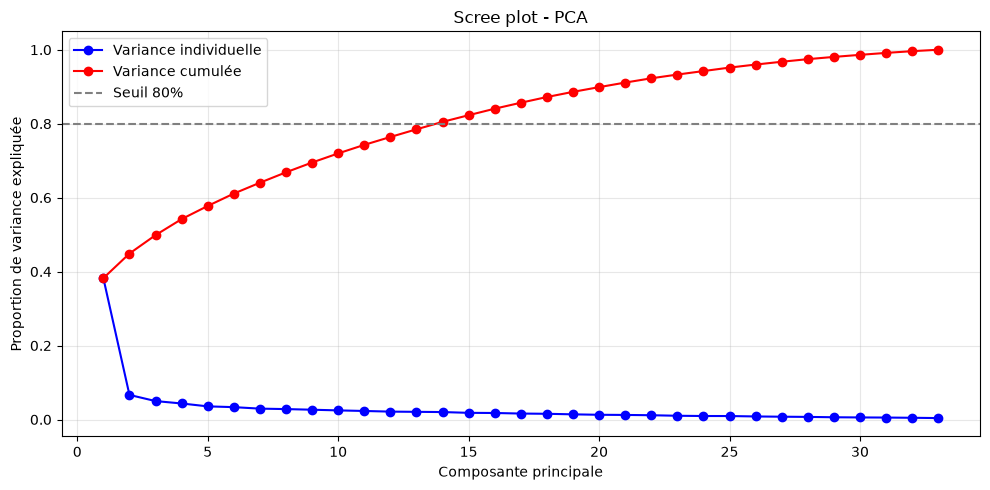

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardiser les données car la var des items n'est pas forcement la meme. J'ai essayé sans ca me donne rien de bon
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_red)

pca = PCA()
pca.fit(X_scaled)

#  Variance expliquée par chaque composante
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Variance expliquée par composante :")
for i, (var, cum) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"  PC{i}: {var:.3f}  (cumulée: {cum:.3f})")

#  Scree plot (graphique du coude)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_var) + 1), explained_var, 'bo-', label='Variance individuelle')
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'ro-', label='Variance cumulée')
plt.axhline(y=0.8, color='gray', linestyle='--', label='Seuil 80%')
plt.xlabel('Composante principale')
plt.ylabel('Proportion de variance expliquée')
plt.title('Scree plot - PCA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [957]:
eigenvalues = pca.explained_variance_
n_components_kaiser = sum(eigenvalues > 1)
print(f"Nombre de composantes selon Kaiser (eigenvalue > 1) : {n_components_kaiser}")

Nombre de composantes selon Kaiser (eigenvalue > 1) : 6


In [958]:
n_components_80 = np.argmax(cumulative_var >= 0.8) + 1
print(f"Nombre de composantes pour 80% de variance expliquée : {n_components_80}")

Nombre de composantes pour 80% de variance expliquée : 14


In [959]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

X = df_red

# PCA avec toutes les composantes (pour voir la variance expliquée)
pca = PCA()
pca.fit(X)

print("Variance expliquée par composante :")
print(pca.explained_variance_ratio_)

print("\nVariance cumulée :")
print(np.cumsum(pca.explained_variance_ratio_))

print("\nValeurs singulières :")
print(pca.singular_values_)

Variance expliquée par composante :
[0.41480455 0.0608982  0.04266893 0.04048062 0.03911091 0.0370487
 0.0317392  0.02888859 0.02745703 0.02419713 0.02298924 0.02206489
 0.02103998 0.01800403 0.01658536 0.01497238 0.0147209  0.01334821
 0.01266435 0.01174019 0.0109722  0.01059005 0.00918453 0.00836075
 0.00764485 0.00745104 0.00677087 0.00533186 0.00464575 0.00426919
 0.00356684 0.00322734 0.00256135]

Variance cumulée :
[0.41480455 0.47570274 0.51837168 0.5588523  0.59796321 0.63501191
 0.66675112 0.6956397  0.72309673 0.74729386 0.7702831  0.79234799
 0.81338797 0.831392   0.84797736 0.86294974 0.87767064 0.89101884
 0.90368319 0.91542337 0.92639558 0.93698562 0.94617015 0.9545309
 0.96217575 0.96962679 0.97639767 0.98172952 0.98637528 0.99064447
 0.99421131 0.99743865 1.        ]

Valeurs singulières :
[123.26785992  47.2313449   39.53520544  38.50806451  37.85097313
  36.83957474  34.09778115  32.53053857  31.71427949  29.77213997
  29.01953065  28.43013847  27.76200164  25.6810632

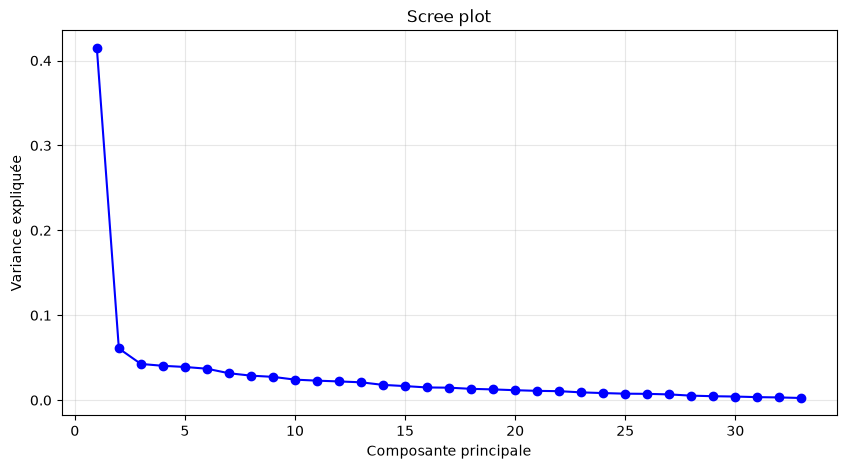

In [960]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Composante principale')
plt.ylabel('Variance expliquée')
plt.title('Scree plot')
plt.grid(True, alpha=0.3)
plt.show()

au coude s'arreter la

In [961]:
n_components_kaiser = sum(pca.explained_variance_ > 1)
print(f"Nombre de composantes (Kaiser) : {n_components_kaiser}")

Nombre de composantes (Kaiser) : 29


Une composante n'est "utile" que si elle explique plus de variance qu'une seule variable originale ne le ferait.

Tu prends le nombre minimal de composantes qui capture au moins X% de la variance totale.

In [962]:
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
n_components_80 = np.argmax(cumulative_var >= 0.80) + 1
print(f"Nombre de composantes pour 80% de variance : {n_components_80}")

Nombre de composantes pour 80% de variance : 13


In [963]:
from sklearn.decomposition import PCA
pca_TSQ = PCA(n_components=2)
principalComponents_TSQ = pca_TSQ.fit_transform(X_scaled)


In [964]:
principal_TSQ_Df = pd.DataFrame(data = principalComponents_TSQ
             , columns = ['principal component 1', 'principal component 2'])



In [965]:
principal_TSQ_Df.tail()


,principal component 1,principal component 2
161,-1.801158,-0.901208
162,1.432196,-1.138831
163,-2.648055,0.232640
164,-4.011566,0.479872
165,-3.384365,0.191742


In [966]:
print('Explained variability per principal component: {}'.format(pca_TSQ.explained_variance_ratio_))


Explained variability per principal component: [0.38230789 0.06650005]


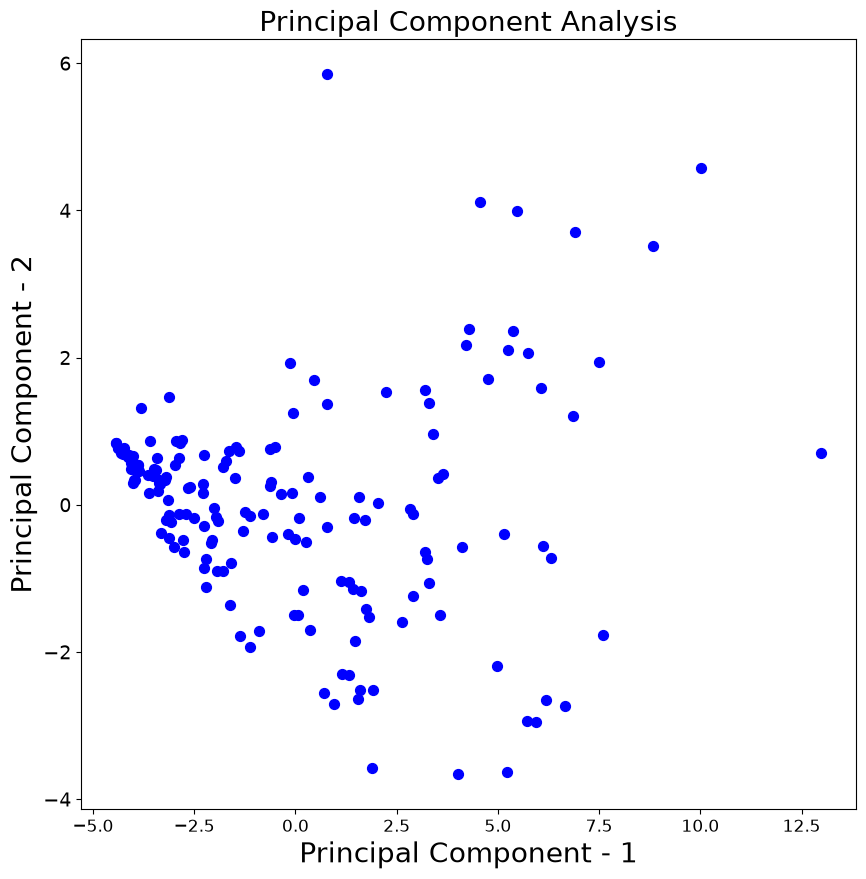

In [967]:
plt.figure(figsize=(10,10))
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlabel('Principal Component - 1', fontsize=20)
plt.ylabel('Principal Component - 2', fontsize=20)
plt.title("Principal Component Analysis", fontsize=20)

plt.scatter(principal_TSQ_Df['principal component 1'],
            principal_TSQ_Df['principal component 2'],
            c='b', s=50)

plt.show()

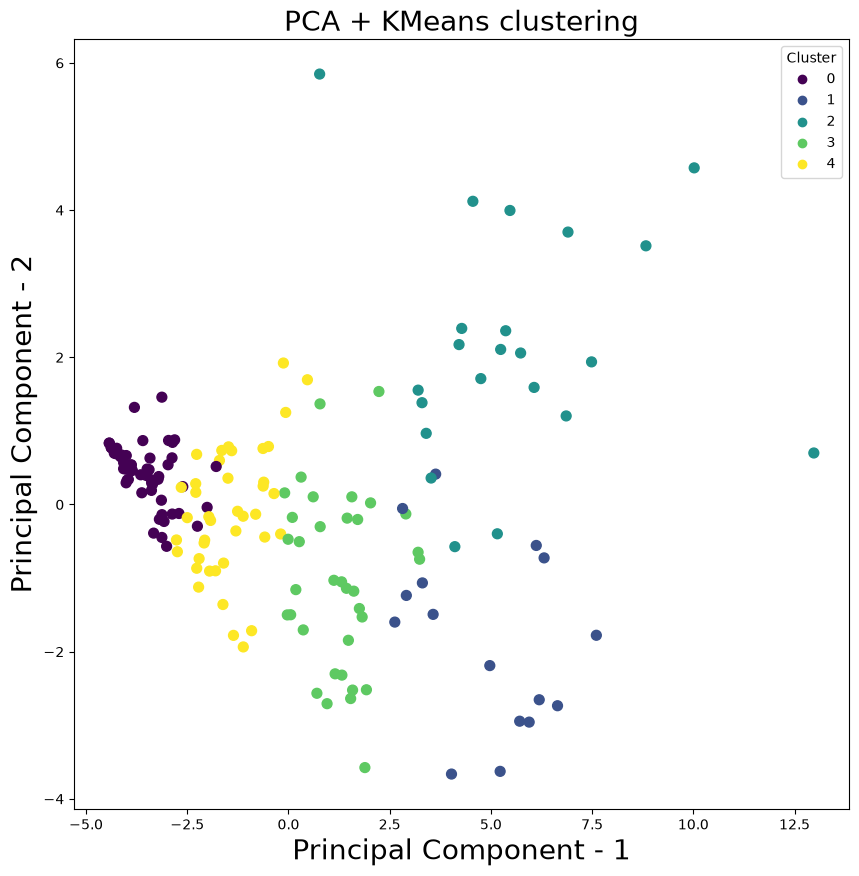

In [968]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(10,10))
plt.xlabel('Principal Component - 1', fontsize=20)
plt.ylabel('Principal Component - 2', fontsize=20)
plt.title("PCA + KMeans clustering", fontsize=20)
scatter = plt.scatter(principal_TSQ_Df['principal component 1'],
                       principal_TSQ_Df['principal component 2'],
                       c=clusters, cmap='viridis', s=50)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

# t-SNE embedding 

divergence KL" (qui mesure à quel point l'espace réduit respecte la structure des données originales

In [969]:
import numpy as np
from sklearn.manifold import TSNE
import plotly.express as px

from sklearn.preprocessing import StandardScaler

# Standardiser les données car la var des items n'est pas forcement la meme. J'ai essayé sans ca me donne rien de bon
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df)
# X = X_scaled 

# change tout de normaliser et j'ai l'impression que c'est pas mieux donc à voir
X = df.values # la j'ai pris le df avec les 40 items , j'ai essayé avec le df_red (sans 7 items qui etaient corrélés mais ca donne moins bien)

perplexity = np.arange(5, 55, 5)
divergence = []


for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i, random_state=42)
    reduced = model.fit_transform(X)
    divergence.append(model.kl_divergence_)

fig = px.line(x=perplexity, y=divergence, markers=True)
fig.update_layout(xaxis_title="Perplexity Values", yaxis_title="Divergence")
fig.update_traces(line_color="red", line_width=1)
fig.show(renderer="browser")

* Perplexité =variance de la gaussienne utilisée pour calculer les similarités entre les paires de points dans l’espace de départ. Plus la perplexité est élevée, plus les voisins éloignés d’un point seront considérés. À l’inverse, une perplexité faible n’accordera d’importance qu’aux voisins les plus proches du point.

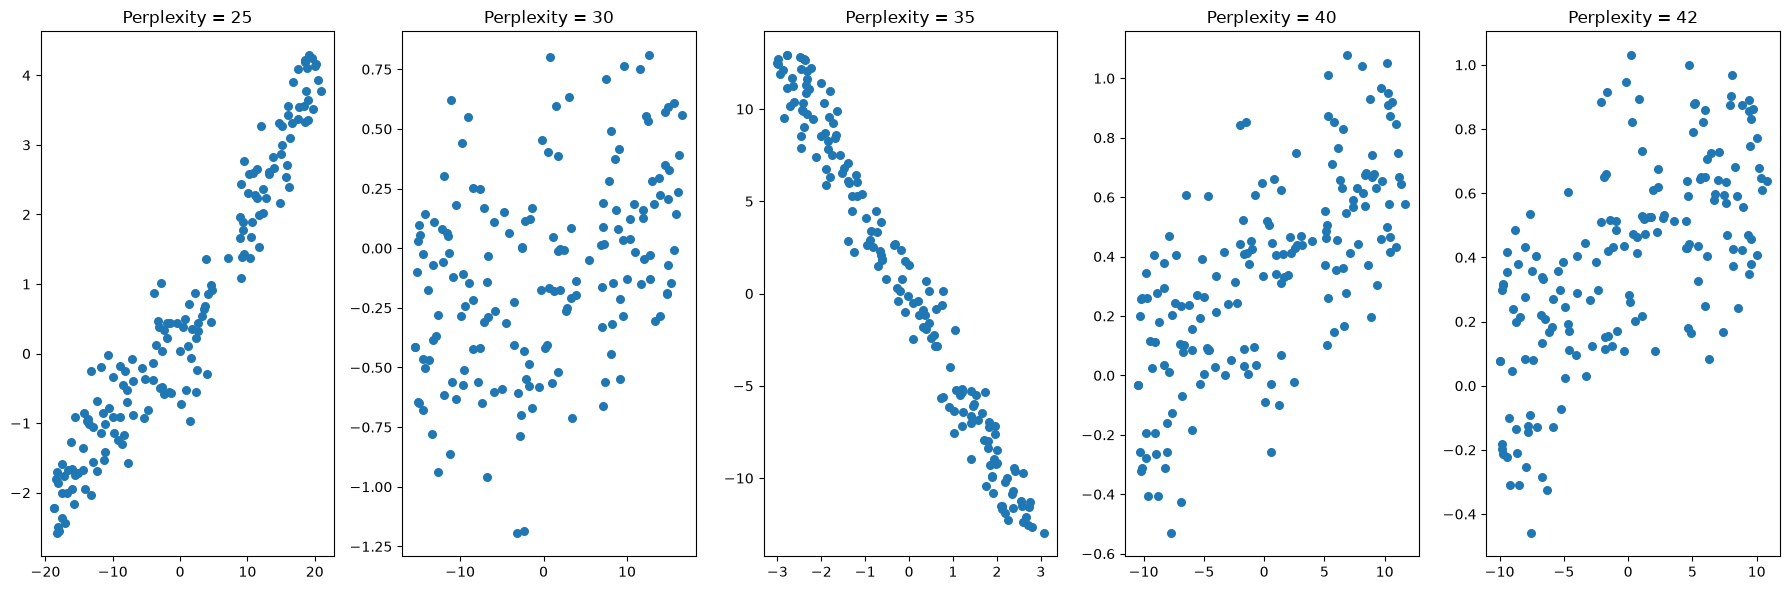

In [970]:
import matplotlib.pyplot as plt

perplexities_to_test = [25, 30, 35, 40, 42]
fig, axes = plt.subplots(1, len(perplexities_to_test), figsize=(18, 6))

for ax, p in zip(axes, perplexities_to_test):
    model = TSNE(n_components=2, init="pca", perplexity=p, random_state=42) #hyperpara : init, generalement "random" mais ici c'est plus  en faisant pca
    reduced = model.fit_transform(X)
    ax.scatter(reduced[:, 0], reduced[:, 1], s=30)
    ax.set_title(f"Perplexity = {p}")

plt.tight_layout()
plt.show()

+ on aug la perplexity + ca va conserver la strucure originelle, mais + petit + ca separe

In [971]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="pca", perplexity=40, random_state=42)
X_tsne = tsne.fit_transform(X)

tsne.kl_divergence_

0.09323961287736893

In [972]:
participant_ids = df.index  # [0, 1, 2, ..., 153]
fig = px.scatter(x=X_tsne[:, 0], y=X_tsne[:, 1])

fig.update_layout(
    title="t-SNE visualization - Participants sains",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show(renderer="browser")


In [973]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)  # essaie différents n_clusters
clusters = kmeans.fit_predict(X)
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 
fig = px.scatter(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1],
    hover_name=participant_ids,
    color=clusters.astype(str),  # colore par cluster trouvé
    color_discrete_sequence=custom_colors
)
fig.update_layout(
    title="t-SNE coloré par clusters KMeans",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show(renderer="browser")
# donne un graph interactif en cliquant sur les points : on sait qui est le aprticipant

* Outre les paramètres généraux de l’algorithme, l’optimisation de TSNE peut être modifiée à l’aide des paramètres optionnels suivants:

early_exaggeration: facteur d’exagération des similarités pour la phase initiale de l’optimisation.

learning_rate: détermine le pas de l’algorithme de descente de gradient. L’utilisation de la valeur "auto" est recommandée (elle exploite l’heuristique de [BCA19]).

n_iter: nombre d’itérations de la descente de gradient. Il peut être utile d’augmenter ce paramètre si t-SNE ne converge pas dans le temps imparti.

method ("barnes_hut" par défaut, accepte aussi la valeur "exact"): définit la méthode utilisée pour le calcul du gradient. Par défaut, TSNE utilise la méthode de Barnes-Hut qui est une approximation en O(NlogN)
 plutôt que la méthode exacte en O(N2)
. La méthode exacte ne passe pas à l’échelle au-delà de quelques milliers d’exemples

# Visu en 3D

In [ ]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import plotly.express as px
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 


tsne = TSNE(n_components=3, perplexity=45, random_state=42)
projections = tsne.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

fig = px.scatter_3d(
    projections, x=0, y=1, z=2,
    color=clusters.astype(str),
    labels={'color': 'Cluster'},
    hover_name=[f"Participant {i}" for i in df_red.index],
    color_discrete_sequence=custom_colors
)
fig.update_traces(marker_size=5)
fig.update_layout(title="t-SNE 3D - Participants sains (TSQ)")
fig.show(renderer="browser")

In [975]:
for trace in fig.data:
    print(trace.name, "->", len(trace.x), "points")

3 -> 29 points
1 -> 18 points
2 -> 59 points
0 -> 45 points
4 -> 15 points


Extraire les groupes de  participants par cluster

cluster 0 = jaune, 1 =violet , 2 = rouge, 3= vert , 4 = bleu

In [976]:
# on ajoute directement le label de cluster à df_clust
df_clust = df.copy()
df_clust['cluster'] = clusters

# vérifier la répartition
print(df_clust['cluster'].value_counts().sort_index())

cluster
0    45
1    18
2    59
3    29
4    15
Name: count, dtype: int64


In [ ]:
groupes = {c: df_clust[df_clust['cluster'] == c] for c in sorted(df_clust['cluster'].unique())}


groupes[0]   # DataFrame des participants du cluster 0
groupes[1]   # DataFrame des participants du cluster 1
groupes[2]   # DataFrame des participants du cluster 2
groupes[3]   # DataFrame des participants du cluster 3
groupes[4]   # DataFrame des participants du cluster 4

participants_par_cluster = {c: grp.index.tolist() for c, grp in groupes.items()}
print(participants_par_cluster)

{np.int32(0): [12, 17, 40, 54, 55, 59, 66, 83, 104, 110, 115, 116, 117, 118, 122, 141, 146, 147, 157, 161, 163, 164, 165, 174, 185, 194, 197, 202, 214, 241, 255, 264, 267, 268, 271, 275, 294, 301, 308, 337, 340, 344, 349, 352, 357], np.int32(1): [3, 27, 31, 44, 46, 52, 67, 86, 129, 132, 159, 200, 201, 217, 223, 260, 279, 281], np.int32(2): [9, 10, 18, 19, 24, 32, 37, 38, 39, 42, 48, 49, 50, 53, 56, 60, 61, 64, 65, 68, 73, 85, 87, 90, 95, 99, 106, 108, 114, 119, 125, 130, 136, 155, 166, 168, 179, 181, 186, 204, 205, 231, 236, 238, 248, 261, 262, 263, 270, 292, 298, 304, 311, 314, 346, 351, 363, 366, 367], np.int32(3): [1, 5, 21, 22, 51, 74, 75, 138, 142, 144, 172, 173, 184, 207, 210, 215, 218, 222, 224, 250, 253, 289, 291, 297, 306, 307, 348, 353, 361], np.int32(4): [16, 72, 88, 121, 124, 145, 160, 170, 175, 206, 212, 226, 229, 246, 347]}


In [978]:
for c, grp in groupes.items():
    grp.to_csv(f"cluster_{c}_participants.csv")

ou des df par groupe

In [979]:
df_cluster0 = df_clust[df_clust['cluster'] == 0]
df_cluster1 = df_clust[df_clust['cluster'] == 1]
df_cluster2 = df_clust[df_clust['cluster'] == 2]
df_cluster3 = df_clust[df_clust['cluster'] == 3]
df_cluster4 = df_clust[df_clust['cluster'] == 4]

for i, d in enumerate([df_cluster0, df_cluster1, df_cluster2, df_cluster3, df_cluster4]):
    print(f"Cluster {i}: {len(d)} participants")

Cluster 0: 45 participants
Cluster 1: 18 participants
Cluster 2: 59 participants
Cluster 3: 29 participants
Cluster 4: 15 participants


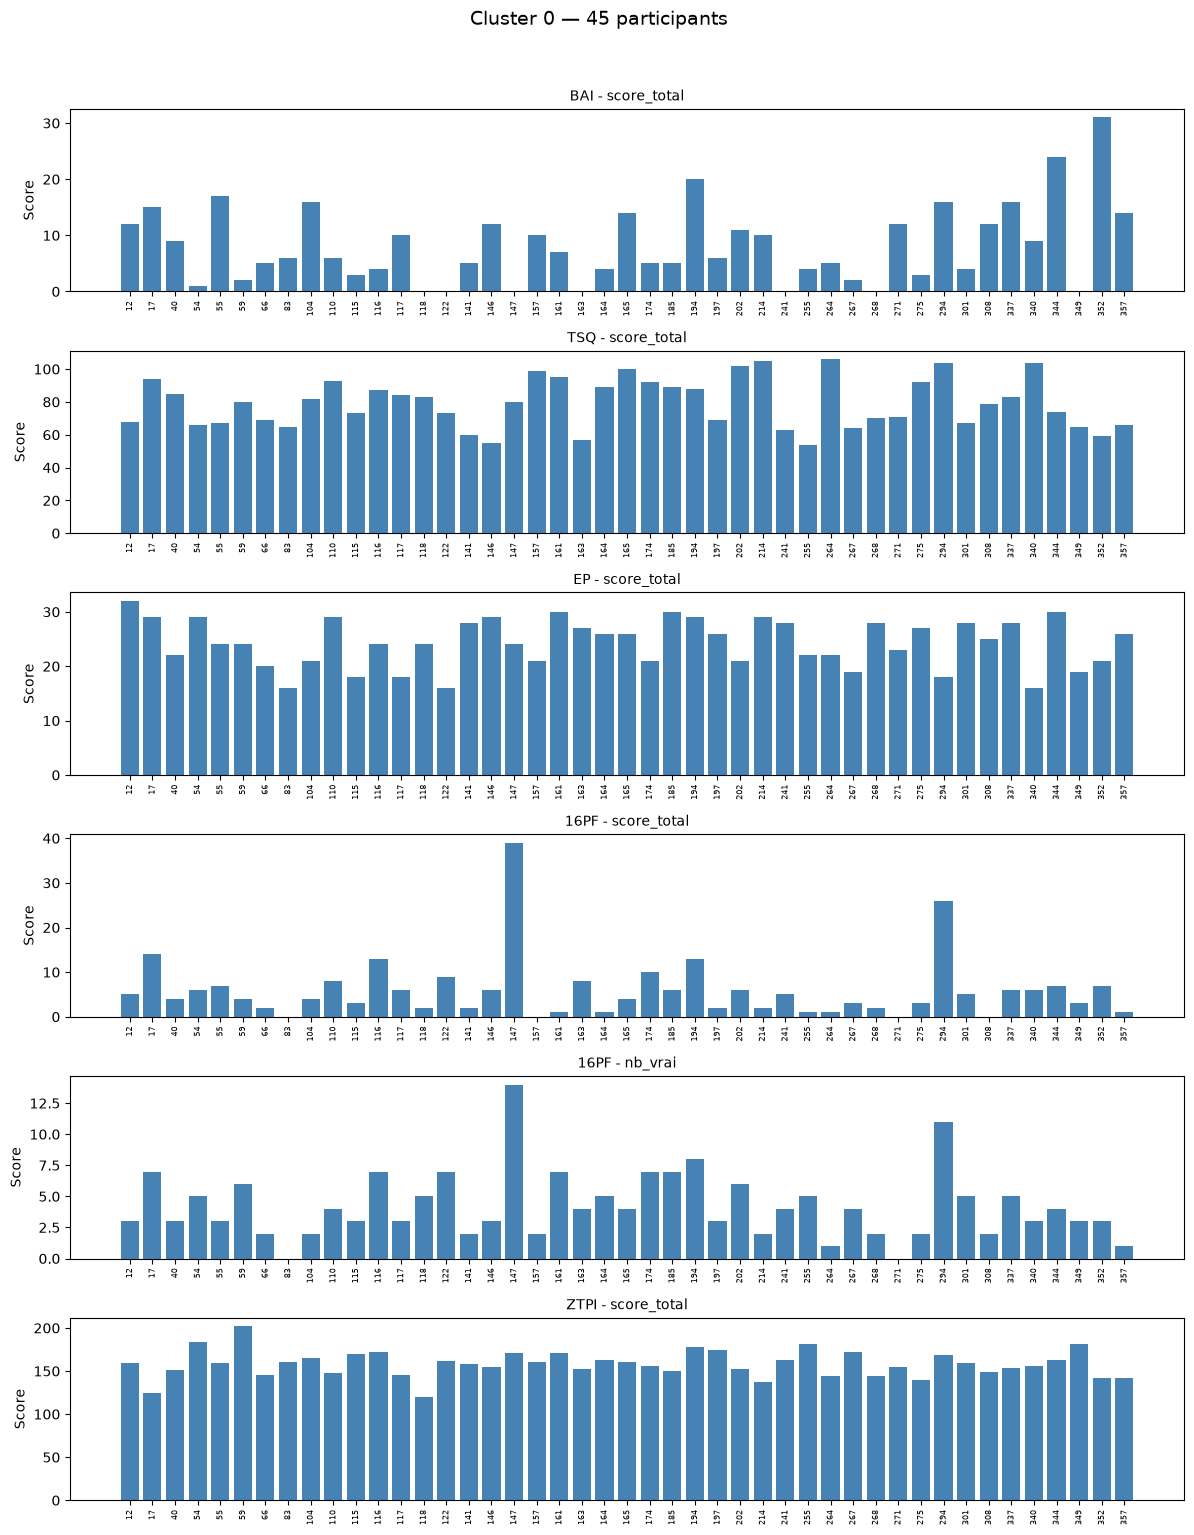

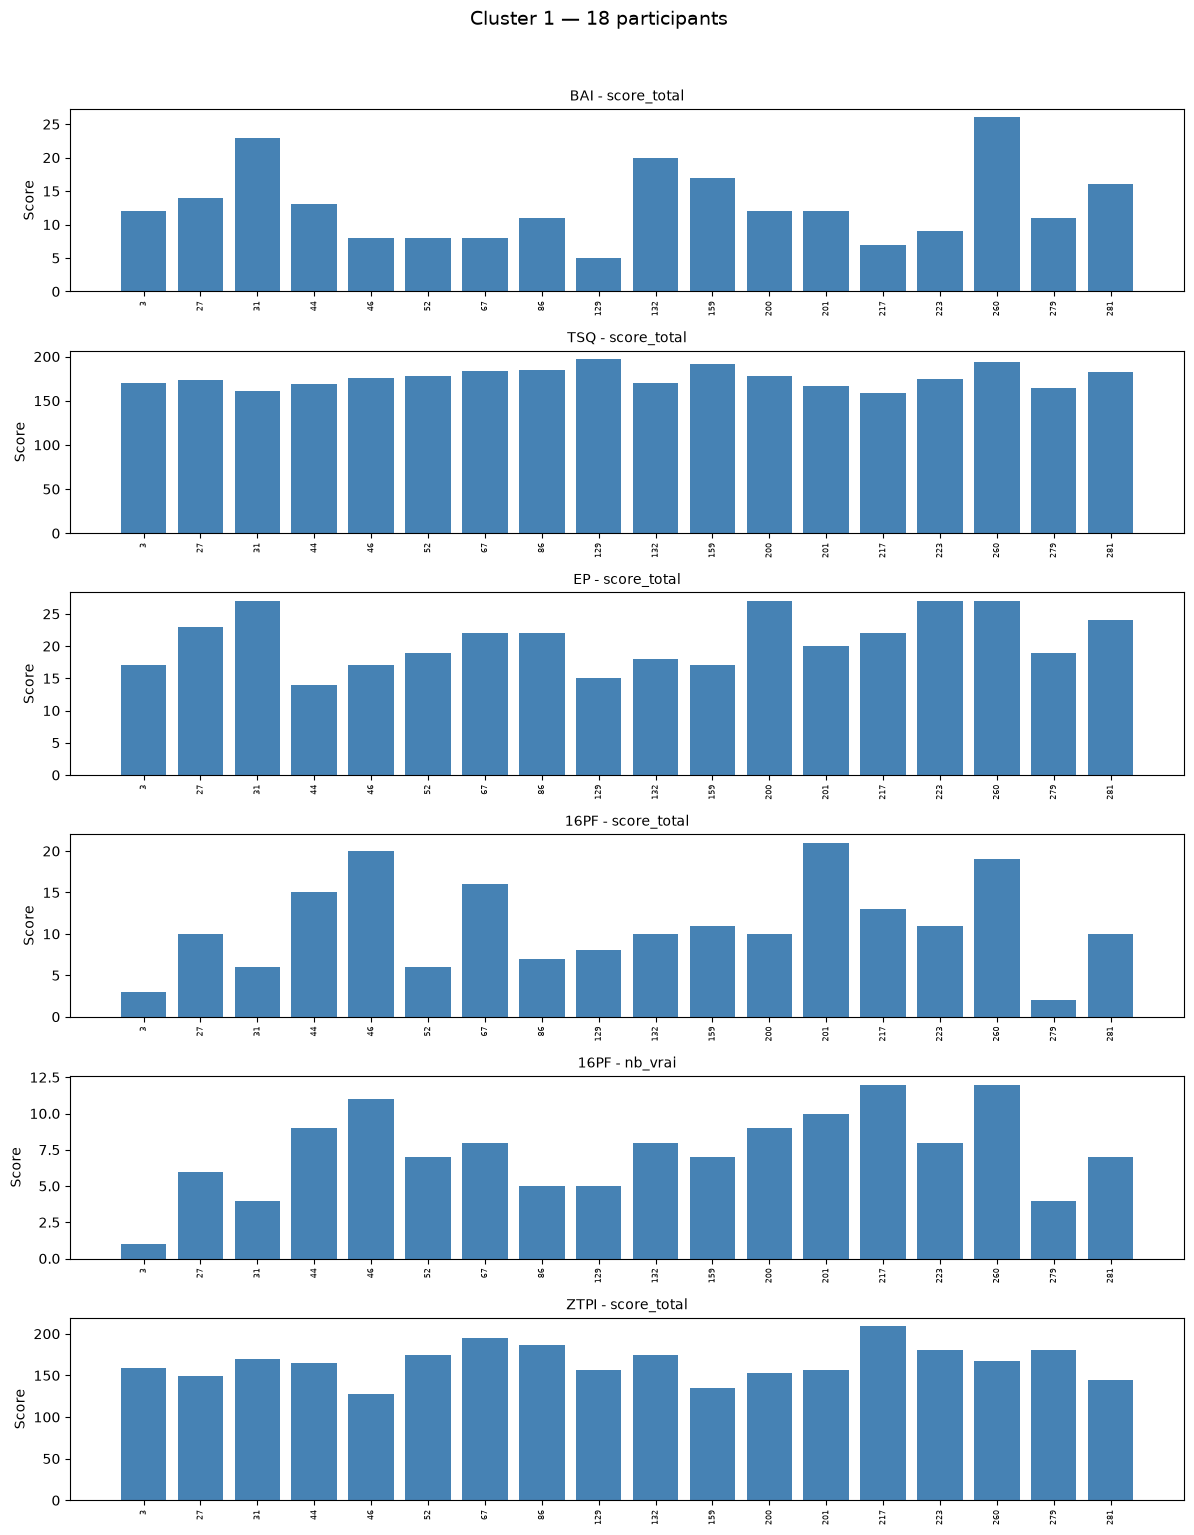

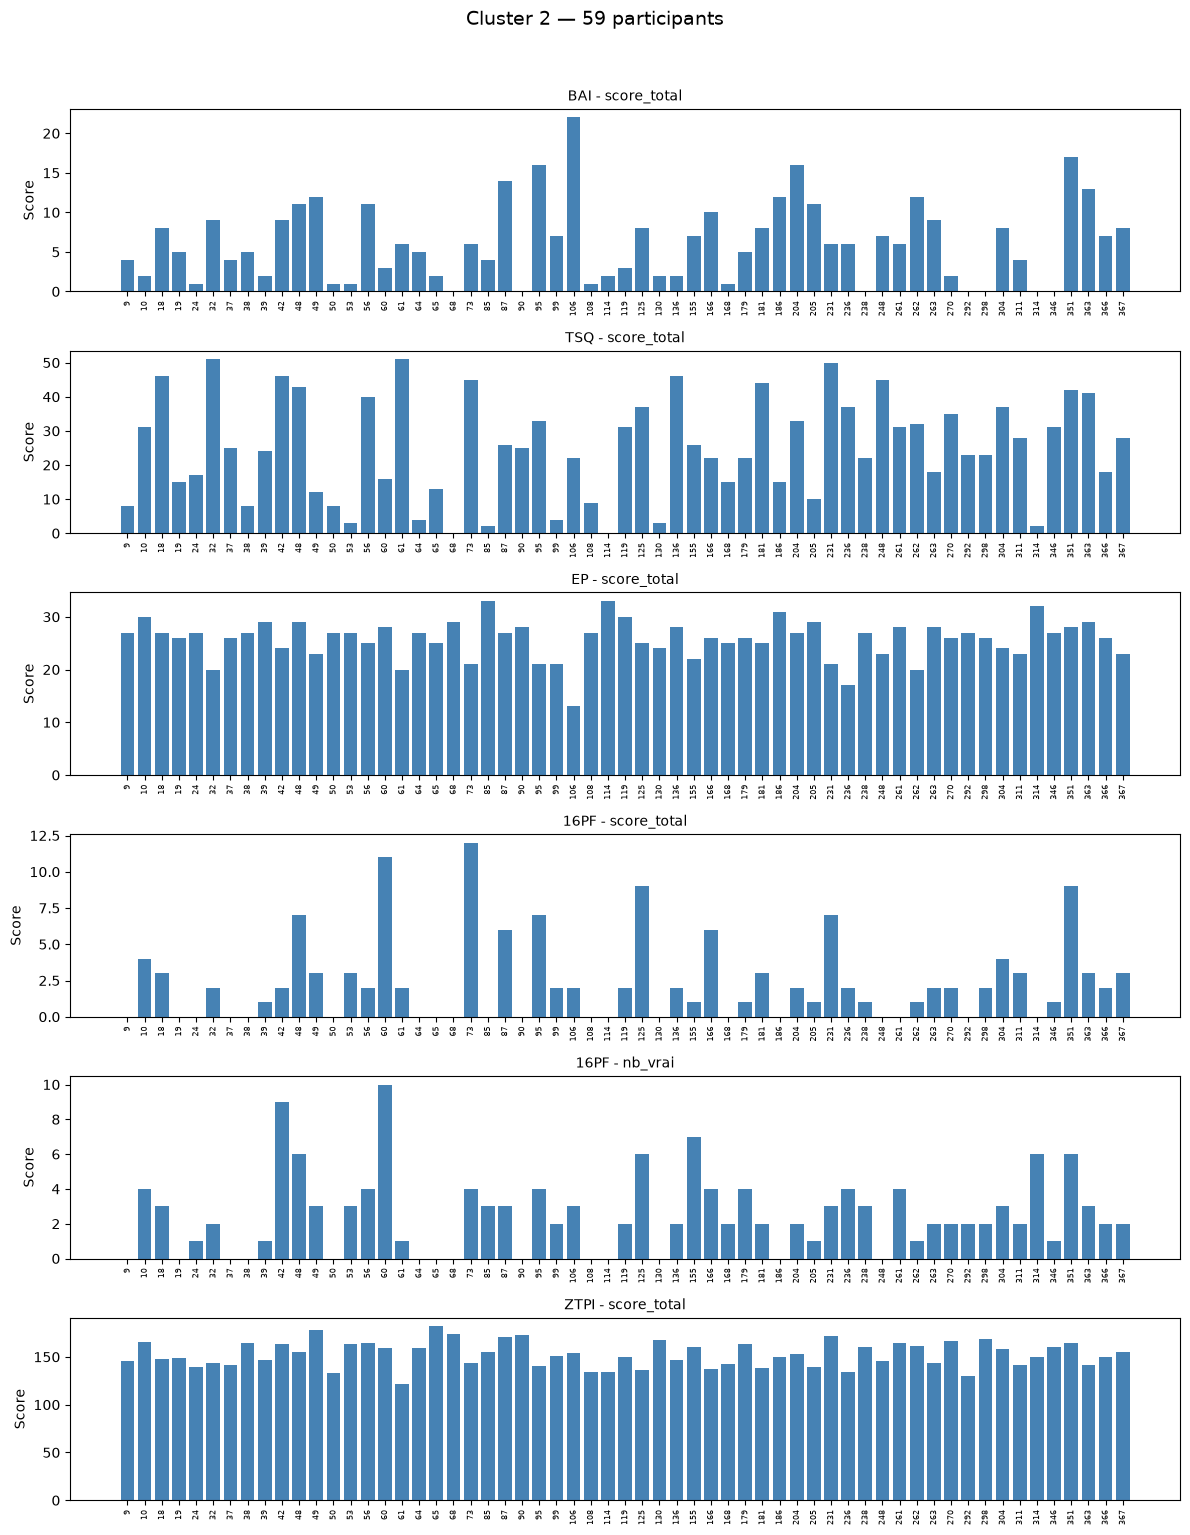

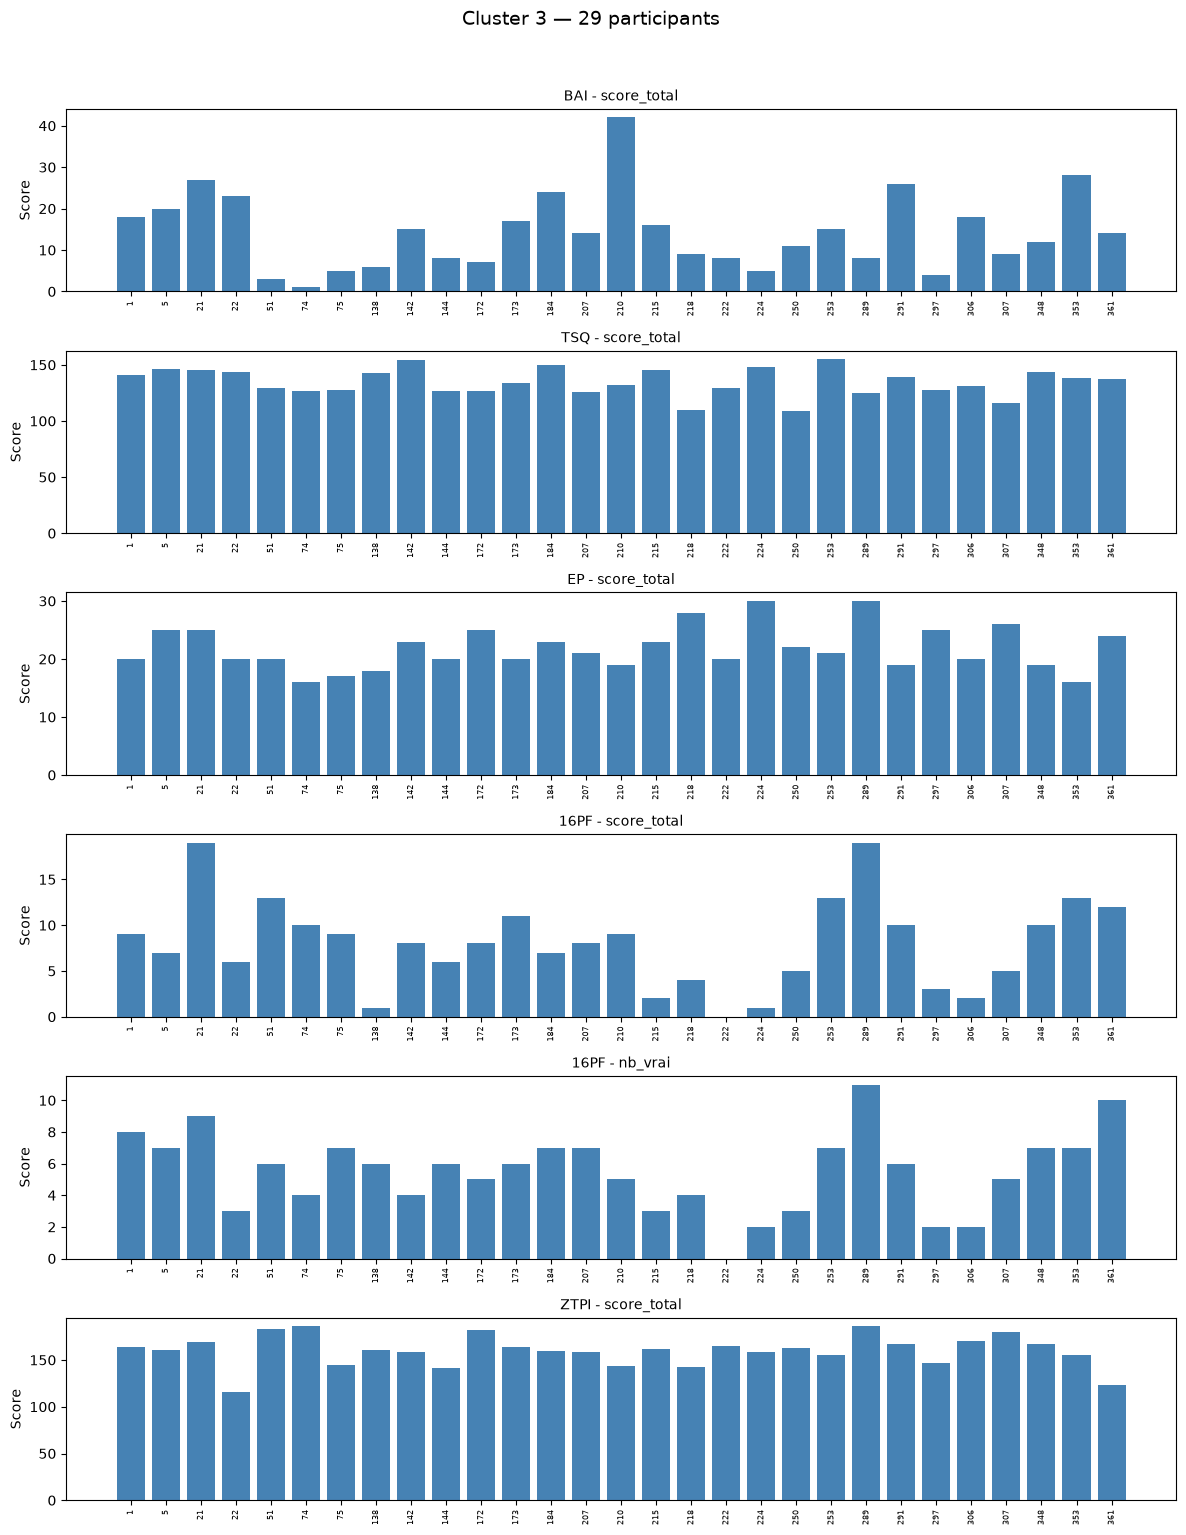

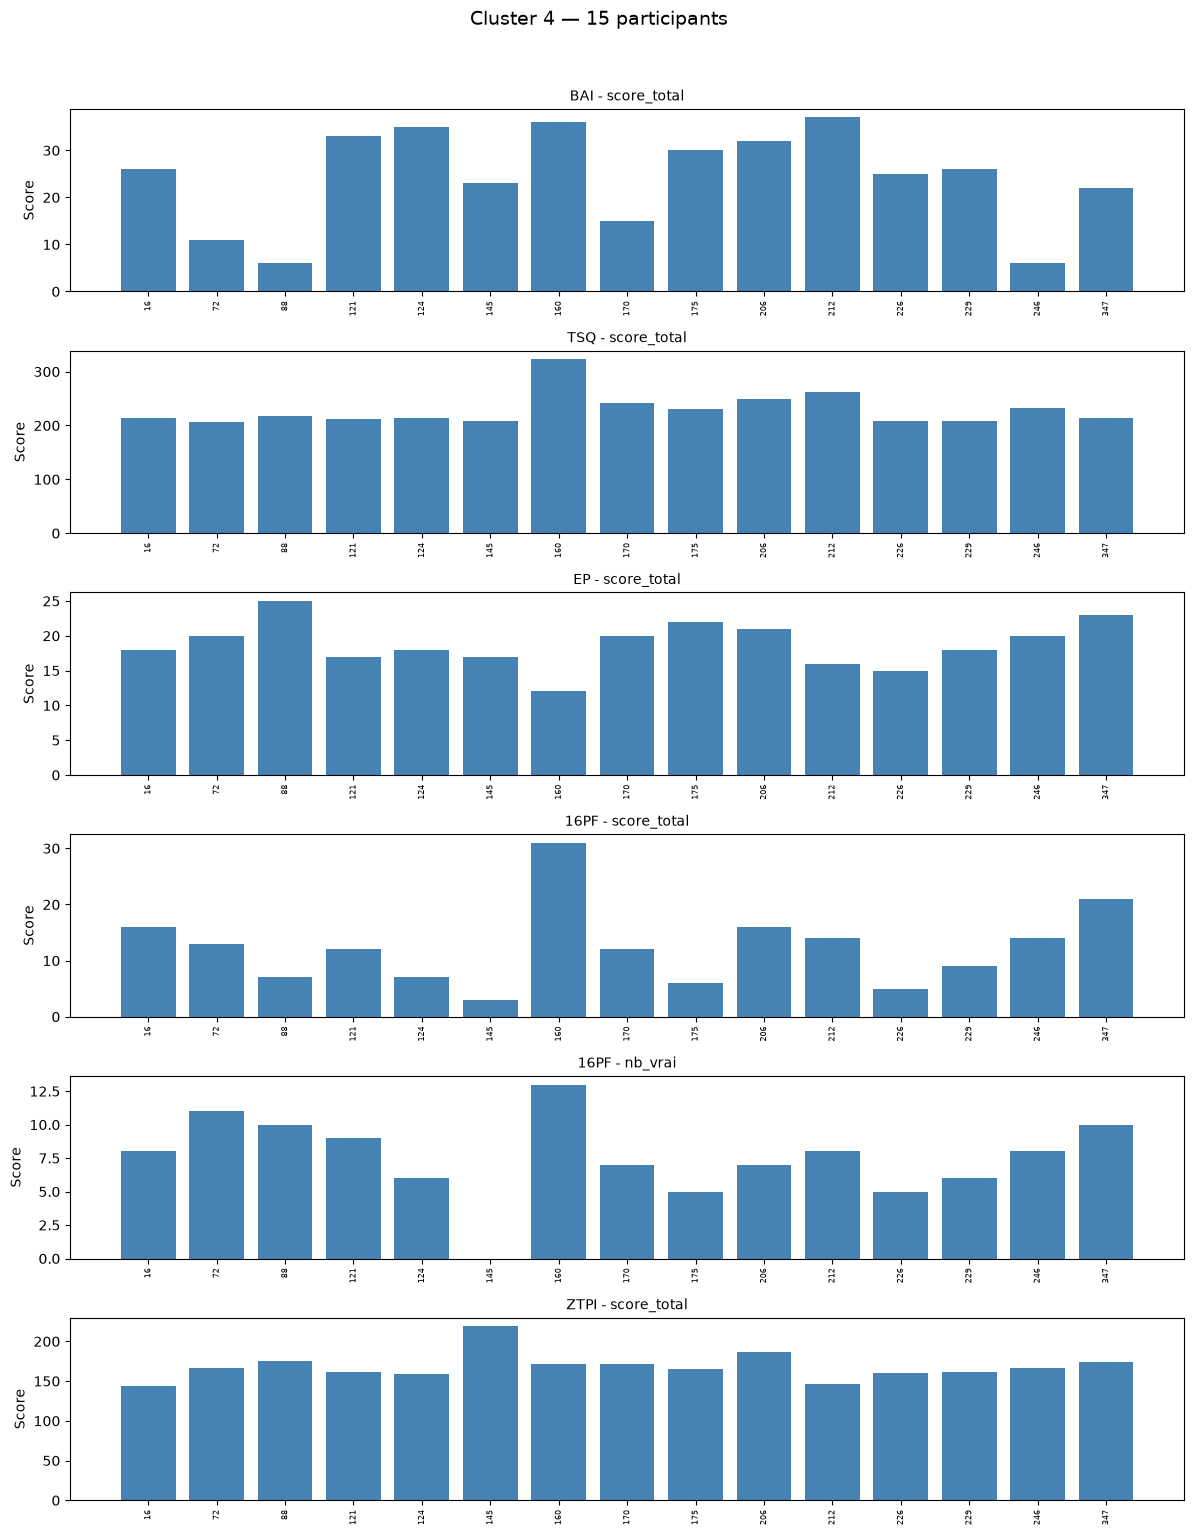

In [980]:
import matplotlib.pyplot as plt

# dictionnaire des variables à visualiser
variables = {
    "BAI - score_total": df_BAI["score_total"],
    "TSQ - score_total": df_TSQ["score_total"],
    "EP - score_total": df_EP["score_total"],
    "16PF - score_total": df_16["score_total"],
    "16PF - nb_vrai": df_16["nb_vrai"],
    "ZTPI - score_total": df_ZTPI["score_total"],
}

clusters_list = [df_cluster0, df_cluster1, df_cluster2, df_cluster3, df_cluster4]

for c, d in enumerate(clusters_list):
    participants = d.index
    n_vars = len(variables)

    fig, axes = plt.subplots(n_vars, 1, figsize=(12, 2.5 * n_vars), sharex=False)
    fig.suptitle(f"Cluster {c} — {len(participants)} participants", fontsize=14, y=1.02)

    for ax, (name, series) in zip(axes, variables.items()):
        # reindex plutôt que .loc pour éviter un crash si un participant manque
        values = series.reindex(participants)
        ax.bar(values.index.astype(str), values.values, color='steelblue')
        ax.set_title(name, fontsize=10)
        ax.set_ylabel("Score")
        ax.tick_params(axis='x', rotation=90, labelsize=6)

    plt.tight_layout()
    plt.show()

In [981]:
variables = {
    "BAI_score_total": df_BAI["score_total"],
    "TSQ_score_total": df_TSQ["score_total"],
    "EP_score_total": df_EP["score_total"],
    "16PF_score_total": df_16["score_total"],
    "16PF_nb_vrai": df_16["nb_vrai"],
    "ZTPI_score_total": df_ZTPI["score_total"],
}

clusters_list = [df_cluster0, df_cluster1, df_cluster2, df_cluster3, df_cluster4]

resultats_par_cluster = {}

for c, d in enumerate(clusters_list):
    participants = d.index
    tableau = pd.DataFrame({name: series.reindex(participants) for name, series in variables.items()})
    tableau.index.name = "participant"
    resultats_par_cluster[c] = tableau
    print(f"\n--- Cluster {c} ({len(participants)} participants) ---")
    print(tableau)


--- Cluster 0 (45 participants) ---
             BAI_score_total  TSQ_score_total  EP_score_total  \
participant                                                     
12                      12.0             68.0            32.0   
17                      15.0             94.0            29.0   
40                       9.0             85.0            22.0   
54                       1.0             66.0            29.0   
55                      17.0             67.0            24.0   
59                       2.0             80.0            24.0   
66                       5.0             69.0            20.0   
83                       6.0             65.0            16.0   
104                     16.0             82.0            21.0   
110                      6.0             93.0            29.0   
115                      3.0             73.0            18.0   
116                      4.0             87.0            24.0   
117                     10.0             84.0        

In [982]:
resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)

                   Cluster 0   Cluster 1   Cluster 2   Cluster 3   Cluster 4
BAI_score_total     8.155556   12.888889    6.152542   14.241379   24.200000
TSQ_score_total    79.333333  176.444444   24.983051  134.724138  229.600000
EP_score_total     24.288889   20.944444   25.762712   21.896552   18.800000
16PF_score_total    5.844444   11.000000    2.338983    7.931034   12.400000
16PF_nb_vrai        4.200000    7.388889    2.474576    5.482759    7.533333
ZTPI_score_total  158.177778  165.666667  152.627119  159.793103  168.466667


Comme UMAP on a un clustering en fonction des scores de tt les échelles : cad --> le cluster 3 (vert) a des participants qui ont des scores de tt les échelles + élevés (sauf pour EP : la plus petite ce qui est coherent). Ensuite les clusters gardent cette categorisation et dans l'ordre on a le cluster 1 (violet), 2 (rouge),  0(jaune), 4 (bleu) qui sont du + "patho" au + "sain". 

ce serait comme des clusters de participants "à risque"

In [986]:
import pandas as pd
from TSQ_scoring import calculer_scores_tsq

for i, d in enumerate(clusters_list, start=1):
    print(f"Cluster {i}: {len(d)} participants")


df_TSQ_scores = calculer_scores_tsq(df_TSQ)

items_tsq = [f"TSQ{i}" for i in range(1, 41)]
score_cols = [c for c in df_TSQ_scores.columns if c not in items_tsq]
print("Colonnes de scores disponibles :", score_cols)

# vérification d'alignement d'index
assert df_TSQ.index.equals(df_clust.index), "Index df_TSQ / df_clust non alignés !"

# ============================================================
# 3. Scores TSQ par participant + describe() par cluster
# ============================================================
resultats_scores_par_cluster = {}

for i, d in enumerate(clusters_list, start=1):
    sous_scores = df_TSQ_scores.reindex(d.index)[score_cols]
    resultats_scores_par_cluster[i] = sous_scores

    print(f"\n{'='*60}")
    print(f"Cluster {i} — {len(d)} participants")
    print(f"{'='*60}")
    print("\n--- Scores TSQ par participant ---")
    print(sous_scores)
    print("\n--- Describe (moyenne, écart-type, min, max...) ---")
    print(sous_scores.describe())

# ============================================================
# 4. Tableau récapitulatif : moyenne par cluster, toutes dimensions
# ============================================================
resume_moyennes = pd.DataFrame({
    f"Cluster {i}": sous.mean()
    for i, sous in resultats_scores_par_cluster.items()
})
print("\n--- Résumé des moyennes par cluster ---")
print(resume_moyennes)

Cluster 1: 45 participants
Cluster 2: 18 participants
Cluster 3: 59 participants
Cluster 4: 29 participants
Cluster 5: 15 participants
Colonnes de scores disponibles : ['score_total', 'grand_score', 'core_sz', 'core_md', 'core_ma', 'core_an', 'core_pt', 'per_sz', 'per_md', 'per_ma', 'per_an', 'per_pt', 'tot_sz', 'tot_md', 'tot_ma', 'tot_an', 'tot_pt']

Cluster 1 — 45 participants

--- Scores TSQ par participant ---
             score_total  grand_score  core_sz   core_md  core_ma   core_an  \
participant                                                                   
12                  68.0       0.1700  0.05000  0.228571    0.350  0.207143   
17                  94.0       0.2350  0.14375  0.385714    0.325  0.321429   
40                  85.0       0.2125  0.20000  0.100000    0.350  0.278571   
54                  66.0       0.1650  0.08750  0.200000    0.450  0.185714   
55                  67.0       0.1675  0.09375  0.257143    0.000  0.185714   
59                  80.0    

les clusters suivent aussi les TSQ_scoring de Nortoff

# UMAP

In [987]:
from umap import UMAP
from sklearn.cluster import KMeans
import plotly.express as px

# Clustering pour avoir une couleur (comme pour le TSNE)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=40) # ou init 10 jsp ce qui est le mieux
clusters = kmeans.fit_predict(X)

# UMAP en 2D et 3D
umap_2d = UMAP(n_components=2, init='random', random_state=42)
umap_3d = UMAP(n_components=3, init='random', random_state=42)

proj_2d = umap_2d.fit_transform(X)
proj_3d = umap_3d.fit_transform(X)

hover_labels = [f"Participant {i}" for i in df.index]
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 
fig_2d = px.scatter(
    proj_2d, x=0, y=1,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_2d.update_layout(title="UMAP 2D - Participants sains (TSQ)")

fig_3d = px.scatter_3d(
    proj_3d, x=0, y=1, z=2,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_3d.update_traces(marker_size=5)
fig_3d.update_layout(title="UMAP 3D - Participants sains (TSQ)")

fig_2d.show(renderer="browser")
fig_3d.show(renderer="browser")

c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [988]:
df_clust = df_clust.copy()
df_clust['cluster'] = clusters

print(df_clust['cluster'].value_counts().sort_index())

df_cluster1 = df_clust[df_clust['cluster'] == 0]
df_cluster2 = df_clust[df_clust['cluster'] == 1]
df_cluster3 = df_clust[df_clust['cluster'] == 2]
df_cluster4 = df_clust[df_clust['cluster'] == 3]
df_cluster5 = df_clust[df_clust['cluster'] == 4]

for i, d in enumerate([df_cluster1, df_cluster2, df_cluster3, df_cluster4, df_cluster5]):
    print(f"Cluster {i}: {len(d)} participants")

cluster
0    31
1    59
2    25
3    45
4     6
Name: count, dtype: int64
Cluster 0: 31 participants
Cluster 1: 59 participants
Cluster 2: 25 participants
Cluster 3: 45 participants
Cluster 4: 6 participants


In [989]:

clusters_list = [df_cluster1, df_cluster2, df_cluster3, df_cluster4, df_cluster5]

variables = {
    "BAI_score_total": df_BAI["score_total"],
    "TSQ_score_total": df_TSQ["score_total"],
    "EP_score_total": df_EP["score_total"],
    "16PF_score_total": df_16["score_total"],
    "16PF_nb_vrai": df_16["nb_vrai"],
    "ZTPI_score_total": df_ZTPI["score_total"],
}

resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)

                   Cluster 0   Cluster 1  Cluster 2   Cluster 3   Cluster 4
BAI_score_total    14.290323    6.152542      16.36    8.155556   26.000000
TSQ_score_total   136.354839   24.983051     190.40   79.333333  256.666667
EP_score_total     22.064516   25.762712      19.96   24.288889   18.500000
16PF_score_total    8.032258    2.338983      10.88    5.844444   15.500000
16PF_nb_vrai        5.645161    2.474576       7.28    4.200000    8.000000
ZTPI_score_total  161.709677  152.627119     165.00  158.177778  167.500000


On a un clustering en fonction des scores de tt les échelles : cad --> le cluster 4 (bleu) a des participants qui ont des scores de tt les échelles + élevés (sauf pour EP : la plus petite ce qui est coherent). Ensuite les clusters gardent cette categorisation et dans l'ordre on a le cluster 1 (violet), 3 (vert), 2 (rouge), 0 (jaune) qui sont du + "patho" au + "sain". 

ce serait comme des clusters de participants "à risque"

Clusters en fonction du TSQ_scoring de Nortoff

In [990]:
import pandas as pd
from TSQ_scoring import calculer_scores_tsq

for i, d in enumerate(clusters_list, start=1):
    print(f"Cluster {i}: {len(d)} participants")


df_TSQ_scores = calculer_scores_tsq(df_TSQ)

items_tsq = [f"TSQ{i}" for i in range(1, 41)]
score_cols = [c for c in df_TSQ_scores.columns if c not in items_tsq]
print("Colonnes de scores disponibles :", score_cols)


assert df_TSQ.index.equals(df_clust.index), "Index df_TSQ / df_clust non alignés !"

resultats_scores_par_cluster = {}

for i, d in enumerate(clusters_list, start=1):
    sous_scores = df_TSQ_scores.reindex(d.index)[score_cols]
    resultats_scores_par_cluster[i] = sous_scores

    print(f"\n{'='*60}")
    print(f"Cluster {i} — {len(d)} participants")
    print(f"{'='*60}")
    print("\n--- Scores TSQ par participant ---")
    print(sous_scores)
    print("\n--- Describe (moyenne, écart-type, min, max...) ---")
    print(sous_scores.describe())


resume_moyennes = pd.DataFrame({
    f"Cluster {i}": sous.mean()
    for i, sous in resultats_scores_par_cluster.items()
})
print("\n--- Résumé des moyennes par cluster ---")
print(resume_moyennes)

Cluster 1: 31 participants
Cluster 2: 59 participants
Cluster 3: 25 participants
Cluster 4: 45 participants
Cluster 5: 6 participants
Colonnes de scores disponibles : ['score_total', 'grand_score', 'core_sz', 'core_md', 'core_ma', 'core_an', 'core_pt', 'per_sz', 'per_md', 'per_ma', 'per_an', 'per_pt', 'tot_sz', 'tot_md', 'tot_ma', 'tot_an', 'tot_pt']

Cluster 1 — 31 participants

--- Scores TSQ par participant ---
     score_total  grand_score  core_sz   core_md  core_ma   core_an   core_pt  \
1          141.0       0.3525  0.13750  0.485714    0.525  0.514286  0.466667   
5          146.0       0.3650  0.30000  0.300000    0.400  0.450000  0.488889   
21         145.0       0.3625  0.16250  0.528571    0.500  0.478571  0.477778   
22         144.0       0.3600  0.33750  0.314286    0.250  0.450000  0.511111   
31         161.0       0.4025  0.28750  0.442857    0.700  0.514286  0.433333   
51         129.0       0.3225  0.23750  0.257143    0.500  0.342857  0.466667   
74         127.

les clusters suivent aussi les TSQ _scoring de nortoff

# t-SNE sur PD

In [991]:
import numpy as np
from sklearn.manifold import TSNE
import plotly.express as px

from sklearn.preprocessing import StandardScaler

# Standardiser les données car la var des items n'est pas forcement la meme. J'ai essayé sans ca me donne rien de bon
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(df)
# X = X_scaled 

# change tout de normaliser et j'ai l'impression que c'est pas mieux donc à voir
X = df_PD.values # la j'ai pris le df avec les 40 items , j'ai essayé avec le df_red (sans 7 items qui etaient corrélés mais ca donne moins bien)

perplexity = np.arange(5, 35, 5)
divergence = []

for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i, random_state=42)
    reduced = model.fit_transform(X)
    divergence.append(model.kl_divergence_)

fig = px.line(x=perplexity, y=divergence, markers=True)
fig.update_layout(xaxis_title="Perplexity Values", yaxis_title="Divergence")
fig.update_traces(line_color="red", line_width=1)
fig.show(renderer="browser")

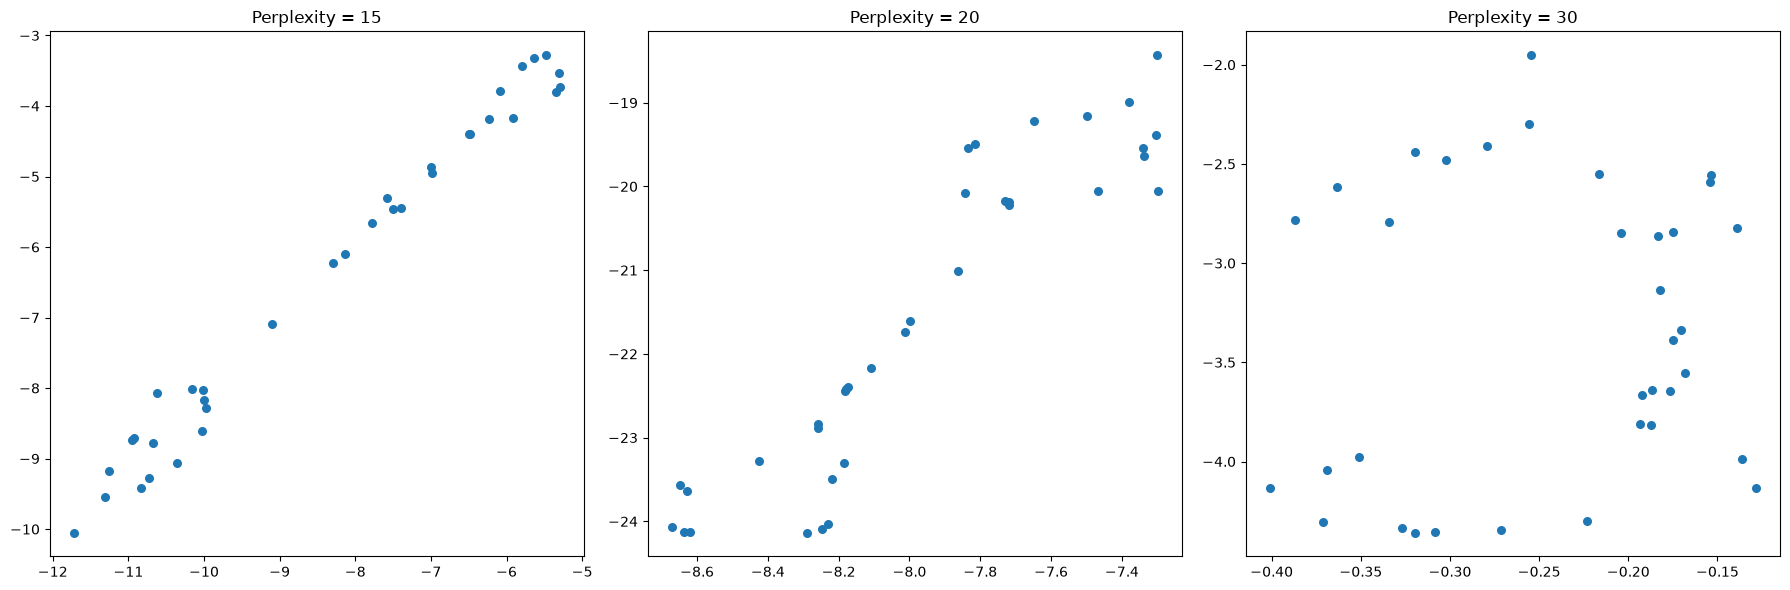

In [992]:

import matplotlib.pyplot as plt

perplexities_to_test = [15,20, 30]
fig, axes = plt.subplots(1, len(perplexities_to_test), figsize=(18, 6))
for ax, p in zip(axes, perplexities_to_test):
    model = TSNE(n_components=2, init="pca", perplexity=p, random_state=42) #hyperpara : init, generalement "random" mais ici c'est plus  en faisant pca
    reduced = model.fit_transform(X)
    ax.scatter(reduced[:, 0], reduced[:, 1], s=30)
    ax.set_title(f"Perplexity = {p}")

plt.tight_layout()
plt.show()




In [993]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="pca", perplexity=20, random_state=42)
X_tsne = tsne.fit_transform(X)

tsne.kl_divergence_

0.023177821189165115

In [994]:
participant_ids = df_PD.index  
fig = px.scatter(x=X_tsne[:, 0], y=X_tsne[:, 1])

fig.update_layout(
    title="t-SNE visualization - Participants avec diag",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show(renderer="browser")

In [995]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)  
clusters = kmeans.fit_predict(X)
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 
fig = px.scatter(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1],
    hover_name=participant_ids,
    color=clusters.astype(str),  
    color_discrete_sequence=custom_colors
)
fig.update_layout(
    title="t-SNE coloré par clusters KMeans",
    xaxis_title="First t-SNE",
    yaxis_title="Second t-SNE",
)
fig.show(renderer="browser")
# donne un graph interactif en cliquant sur les points : on sait qui est le aprticipant

In [996]:

df_clust_PD = df_PD.copy()
df_clust_PD['cluster'] = clusters


print(df_clust_PD['cluster'].value_counts().sort_index())
df_PD0 = df_clust_PD[df_clust_PD['cluster'] == 0]
df_PD1 = df_clust_PD[df_clust_PD['cluster'] == 1]
df_PD2 = df_clust_PD[df_clust_PD['cluster'] == 2]
df_PD3 = df_clust_PD[df_clust_PD['cluster'] == 3]
df_PD4 = df_clust_PD[df_clust_PD['cluster'] == 4]

for i, d in enumerate([df_PD0, df_PD1, df_PD2, df_PD3, df_PD4]):
    print(f"Cluster {i}: {len(d)} participants")

cluster
0     8
1    11
2     7
3     8
4     1
Name: count, dtype: int64
Cluster 0: 8 participants
Cluster 1: 11 participants
Cluster 2: 7 participants
Cluster 3: 8 participants
Cluster 4: 1 participants


In [997]:

variables = {
    "BAI_score_total": df_BAI_PD["score_total"],
    "TSQ_score_total": df_TSQ_PD["score_total"],
    "EP_score_total": df_EP_PD['score_total'],
    "16PF_score_total": df_16_PD["score_total"],
    "16PF_nb_vrai": df_16_PD["nb_vrai"],
    "ZTPI_score_total": df_ZTPI_PD["score_total"],
}

clusters_list = [df_PD0, df_PD1, df_PD2, df_PD3, df_PD4]

resultats_par_cluster = {}

for c, d in enumerate(clusters_list):
    participants = d.index
    tableau = pd.DataFrame({name: series.reindex(participants) for name, series in variables.items()})
    tableau.index.name = "participant"
    resultats_par_cluster[c] = tableau
    print(f"\n--- Cluster {c} ({len(participants)} participants) ---")
    print(tableau)
resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)


--- Cluster 0 (8 participants) ---
             BAI_score_total  TSQ_score_total  EP_score_total  \
participant                                                     
20                      11.0            118.0            26.0   
79                      12.0            127.0            26.0   
113                      8.0            145.0            20.0   
195                     11.0            119.0            32.0   
242                     25.0            119.0            23.0   
266                     15.0            141.0            16.0   
310                      9.0            104.0            17.0   
360                     32.0            102.0            20.0   

             16PF_score_total  16PF_nb_vrai  ZTPI_score_total  
participant                                                    
20                        6.0             8             156.0  
79                       24.0            10             212.0  
113                       4.0             3             1

In [998]:
import pandas as pd
from TSQ_scoring import calculer_scores_tsq

for i, d in enumerate(clusters_list, start=1):
    print(f"Cluster {i}: {len(d)} participants")


df_TSQ_scores_PD = calculer_scores_tsq(df_TSQ_PD)

items_tsq = [f"TSQ{i}" for i in range(1, 41)]
score_cols = [c for c in df_TSQ_scores_PD.columns if c not in items_tsq]
print("Colonnes de scores disponibles :", score_cols)

assert df_TSQ_scores_PD.index.equals(df_clust_PD.index), "Index df_TSQ_scores_PD / df_clust non alignés !"


resultats_scores_par_cluster = {}

for i, d in enumerate(clusters_list, start=1):
    sous_scores = df_TSQ_scores_PD.reindex(d.index)[score_cols]
    resultats_scores_par_cluster[i] = sous_scores

    print(f"\n{'='*60}")
    print(f"Cluster {i} — {len(d)} participants")
    print(f"{'='*60}")
    print("\n--- Scores TSQ par participant diag ---")
    print(sous_scores)
    print("\n--- Describe (moyenne, écart-type, min, max...) ---")
    print(sous_scores.describe())


resume_moyennes = pd.DataFrame({
    f"Cluster {i}": sous.mean()
    for i, sous in resultats_scores_par_cluster.items()
})
print("\n--- Résumé des moyennes par cluster ---")
print(resume_moyennes)

Cluster 1: 8 participants
Cluster 2: 11 participants
Cluster 3: 7 participants
Cluster 4: 8 participants
Cluster 5: 1 participants
Colonnes de scores disponibles : ['score_total', 'grand_score', 'core_sz', 'core_md', 'core_ma', 'core_an', 'core_pt', 'per_sz', 'per_md', 'per_ma', 'per_an', 'per_pt', 'tot_sz', 'tot_md', 'tot_ma', 'tot_an', 'tot_pt']

Cluster 1 — 8 participants

--- Scores TSQ par participant diag ---
             score_total  grand_score  core_sz   core_md  core_ma   core_an  \
participant                                                                   
20                 118.0       0.2950  0.28750  0.271429    0.350  0.385714   
79                 127.0       0.3175  0.18750  0.400000    0.650  0.378571   
113                145.0       0.3625  0.21875  0.514286    0.500  0.407143   
195                119.0       0.2975  0.20625  0.328571    0.275  0.442857   
242                119.0       0.2975  0.08750  0.414286    0.025  0.442857   
266                141.0    

cluster 1-5 ou 0-4 selon ou on regarde en gros cluster jaune et bleu se confondent sur la cotation core PTSD et core Manie sinon dans l'ordre c'est du plus symptomatique au moins : 4>5>1>3>2 soit vert>bleu>jaune>rouge>violet 


# UMAP sur PD

In [999]:
from umap import UMAP
from sklearn.cluster import KMeans
import plotly.express as px

X = df_PD.values
# Clustering pour avoir une couleur (comme pour le TSNE)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10) # ou init 10 jsp ce qui est le mieux
clusters = kmeans.fit_predict(X)

# UMAP en 2D et 3D
umap_2d = UMAP(n_components=2, init='random', random_state=42)
umap_3d = UMAP(n_components=3, init='random', random_state=42)

proj_2d = umap_2d.fit_transform(X)
proj_3d = umap_3d.fit_transform(X)

hover_labels = [f"Participant {i}" for i in df_PD.index]
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 
fig_2d = px.scatter(
    proj_2d, x=0, y=1,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_2d.update_layout(title="UMAP 2D - Participants avec diagnostic (TSQ)")

fig_3d = px.scatter_3d(
    proj_3d, x=0, y=1, z=2,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_3d.update_traces(marker_size=5)
fig_3d.update_layout(title="UMAP 3D - Participants avec diagnostic (TSQ)")

fig_2d.show(renderer="browser")
fig_3d.show(renderer="browser")

c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [1000]:

df_clust_PD = df_clust_PD.copy()
df_clust_PD['cluster'] = clusters

# vérifier la répartition
print(df_clust_PD['cluster'].value_counts().sort_index())

df_cluster1 = df_clust_PD[df_clust_PD['cluster'] == 0]
df_cluster2 = df_clust_PD[df_clust_PD['cluster'] == 1]
df_cluster3 = df_clust_PD[df_clust_PD['cluster'] == 2]
df_cluster4 = df_clust_PD[df_clust_PD['cluster'] == 3]
df_cluster5 = df_clust_PD[df_clust_PD['cluster'] == 4]

for i, d in enumerate([df_cluster1, df_cluster2, df_cluster3, df_cluster4, df_cluster5]):
    print(f"Cluster {i}: {len(d)} participants")
clusters_list = [df_cluster1, df_cluster2, df_cluster3, df_cluster4, df_cluster5]

variables = {
    "BAI_score_total": df_BAI_PD["score_total"],
    "TSQ_score_total": df_TSQ_PD["score_total"],
    "EP_score_total": df_EP_PD["score_total"],
    "16PF_score_total": df_16_PD["score_total"],
    "16PF_nb_vrai": df_16_PD["nb_vrai"],
    "ZTPI_score_total": df_ZTPI_PD["score_total"],
}

resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)

cluster
0     8
1    11
2     7
3     8
4     1
Name: count, dtype: int64
Cluster 0: 8 participants
Cluster 1: 11 participants
Cluster 2: 7 participants
Cluster 3: 8 participants
Cluster 4: 1 participants
                  Cluster 0   Cluster 1   Cluster 2  Cluster 3  Cluster 4
BAI_score_total      15.375    6.181818   19.857143     25.375       28.0
TSQ_score_total     121.875   60.272727  187.428571    225.375      322.0
EP_score_total       22.500   24.909091   20.714286     20.875       28.0
16PF_score_total     11.750    4.090909   13.571429     15.250       20.0
16PF_nb_vrai          5.625    3.545455    7.142857      7.750        8.0
ZTPI_score_total    168.000  158.545455  168.714286    166.000      164.0


suit pas toujours le meme ordre meme si le cluster 3 = vert semble + symptomatique, suivit par le 4 = bleu, rouge =2, jaube =0 semble erte assez spécifique de l'échelle de positivité avec des scores les plus bas. le cluster 1 = violet semble etre le - symptomatique. 

En tout cas, les 2 techniques nous ressortent un cluster bleu avec un seul profil c'est le meme participant qui se déclare : TSA, TDAH, TDI, bipolarité type 1. DOnc le cluster bleu represente plutot la manie?

# on reteste sur la TSQ reduite

In [1001]:
colonnes_a_exclure = ['TSQ1', 'TSQ5', 'TSQ9', 'TSQ22', 'TSQ25','TSQ36', 'TSQ39', 'score_total']  
df_red = df.drop(columns=colonnes_a_exclure)
len(df_red.columns)  
print(df_red.columns)

Index(['TSQ2', 'TSQ3', 'TSQ4', 'TSQ6', 'TSQ7', 'TSQ8', 'TSQ10', 'TSQ11',
       'TSQ12', 'TSQ13', 'TSQ14', 'TSQ15', 'TSQ16', 'TSQ17', 'TSQ18', 'TSQ19',
       'TSQ20', 'TSQ21', 'TSQ23', 'TSQ24', 'TSQ26', 'TSQ27', 'TSQ28', 'TSQ29',
       'TSQ30', 'TSQ31', 'TSQ32', 'TSQ33', 'TSQ34', 'TSQ35', 'TSQ37', 'TSQ38',
       'TSQ40'],
      dtype='str')


In [1002]:
from umap import UMAP
from sklearn.cluster import KMeans
import plotly.express as px

X = df_red.values

# Clustering pour avoir une couleur (comme pour le TSNE)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=40) # ou init 10 jsp ce qui est le mieux
clusters = kmeans.fit_predict(X)

# UMAP en 2D et 3D
umap_2d = UMAP(n_components=2, init='random', random_state=42)
umap_3d = UMAP(n_components=3, init='random', random_state=42)

proj_2d = umap_2d.fit_transform(X)
proj_3d = umap_3d.fit_transform(X)

hover_labels = [f"Participant {i}" for i in df_red.index]
custom_colors = ['#F6F926', '#A777F1'] 
fig_2d = px.scatter(
    proj_2d, x=0, y=1,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_2d.update_layout(title="UMAP 2D - Participants sains (TSQ)")

fig_3d = px.scatter_3d(
    proj_3d, x=0, y=1, z=2,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_3d.update_traces(marker_size=5)
fig_3d.update_layout(title="UMAP 3D - Participants sains (TSQ)")

fig_2d.show(renderer="browser")
fig_3d.show(renderer="browser")

c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [1003]:
df_clust = df_red.copy()
df_clust['cluster'] = clusters


print(df_clust['cluster'].value_counts().sort_index())

df_cluster1 = df_clust[df_clust['cluster'] == 0]
df_cluster2 = df_clust[df_clust['cluster'] == 1]
for i, d in enumerate([df_cluster1, df_cluster2]):
    print(f"Cluster {i}: {len(d)} participants")



cluster
0     60
1    106
Name: count, dtype: int64
Cluster 0: 60 participants
Cluster 1: 106 participants


In [1004]:

clusters_list = [df_cluster1, df_cluster2]

variables = {
    "BAI_score_total": df_BAI["score_total"],
    "TSQ_score_total": df_TSQ["score_total"],
    "EP_score_total": df_EP["score_total"],
    "16PF_score_total": df_16["score_total"],
    "16PF_nb_vrai": df_16["nb_vrai"],
    "ZTPI_score_total": df_ZTPI["score_total"],
}


resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)

                   Cluster 0   Cluster 1
BAI_score_total    16.600000    7.000000
TSQ_score_total   171.450000   49.849057
EP_score_total     20.533333   25.235849
16PF_score_total   10.200000    3.801887
16PF_nb_vrai        6.633333    3.226415
ZTPI_score_total  163.683333  155.141509


In [1005]:
from umap import UMAP
from sklearn.cluster import KMeans
import plotly.express as px

X = df_red_PD.values

# Clustering pour avoir une couleur (comme pour le TSNE)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=40) # ou init 10 jsp ce qui est le mieux
clusters = kmeans.fit_predict(X)

# UMAP en 2D et 3D
umap_2d = UMAP(n_components=2, init='random', random_state=42)
umap_3d = UMAP(n_components=3, init='random', random_state=42)

proj_2d = umap_2d.fit_transform(X)
proj_3d = umap_3d.fit_transform(X)

hover_labels = [f"Participant {i}" for i in df_red_PD.index]
custom_colors = ['#F6F926', '#A777F1', '#FC6955', '#00FE35', '#19D3F3'] 
fig_2d = px.scatter(
    proj_2d, x=0, y=1,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_2d.update_layout(title="UMAP 2D - Participants avec diagnostic (TSQ)")

fig_3d = px.scatter_3d(
    proj_3d, x=0, y=1, z=2,
    color=clusters.astype(str), labels={'color': 'Cluster'},
    hover_name=hover_labels,
    color_discrete_sequence=custom_colors
)
fig_3d.update_traces(marker_size=5)
fig_3d.update_layout(title="UMAP 3D - Participants avec diagnostic (TSQ)")

fig_2d.show(renderer="browser")
fig_3d.show(renderer="browser")

c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\TSQ\data\Projet_final_DESU\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [1006]:
df_clust = df_red_PD.copy()
df_clust['cluster'] = clusters


print(df_clust['cluster'].value_counts().sort_index())

df_cluster1 = df_clust[df_clust['cluster'] == 0]
df_cluster2 = df_clust[df_clust['cluster'] == 1]
df_cluster3 = df_clust[df_clust['cluster'] == 2]
df_cluster4 = df_clust[df_clust['cluster'] == 3]    
df_cluster5 = df_clust[df_clust['cluster'] == 4]
for i, d in enumerate([df_cluster1, df_cluster2, df_cluster3, df_cluster4, df_cluster5]):
    print(f"Cluster {i}: {len(d)} participants")

cluster
0     9
1    14
2     6
3     4
4     2
Name: count, dtype: int64
Cluster 0: 9 participants
Cluster 1: 14 participants
Cluster 2: 6 participants
Cluster 3: 4 participants
Cluster 4: 2 participants


In [1007]:

clusters_list = [df_cluster1, df_cluster2, df_cluster3, df_cluster4, df_cluster5]

variables = {
    "BAI_score_total": df_BAI_PD["score_total"],
    "TSQ_score_total": df_TSQ_PD["score_total"],
    "EP_score_total": df_EP_PD["score_total"],
    "16PF_score_total": df_16_PD["score_total"],
    "16PF_nb_vrai": df_16_PD["nb_vrai"],
    "ZTPI_score_total": df_ZTPI_PD["score_total"],
}


resume = pd.DataFrame({
    f"Cluster {c}": pd.Series({
        name: series.reindex(d.index).mean() for name, series in variables.items()
    })
    for c, d in enumerate(clusters_list)
})
print(resume)

                   Cluster 0   Cluster 1   Cluster 2  Cluster 3  Cluster 4
BAI_score_total    20.777778    9.571429   26.666667      12.25       15.5
TSQ_score_total   183.666667   70.571429  241.833333     143.50      204.5
EP_score_total     20.666667   23.857143   23.166667      23.25       21.0
16PF_score_total   15.000000    6.642857   13.666667       8.75       15.5
16PF_nb_vrai        7.000000    4.000000    7.500000       6.00        8.0
ZTPI_score_total  173.000000  157.857143  160.666667     174.25      166.5


bai : 3>0>1>4>2
TSQ : 3>0>4>1>2
EP : 3>0>2>4>1
16tot: 0>3>1>4>2
nb vrai: 0>3>1>4>2
ztpi: 4>0>1>2>3

cluster 0 serait plus spécifique de la fpq16 (violet)
cluster 3 de l'anxiete, depression (bai, tsq, ep) bleu
cluster 4 serait + spe de deficit spatio temporel  (rouge)